# Phyloseq analysis
- repeat 2.2Phyloseq.ipynb at genus level
- reran bracken at G level- see 2.0Taxa-Kraken script

In [5]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [5]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)
library(lubridate)


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




## View bracken classification results

In [1]:
####### look at classification rates for each level
# spp_path='/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/taxonomy/kraken'
# # slurm_combined.log in base_path is spp level classification I think

# rest_path='/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/taxonomy/kraken/bracken2'
# # in terminal: 
# cd $rest_path
# cat slurm*.out > slurm_combined_brackenall.log

In [7]:
setwd('/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/taxonomy/kraken/bracken2')

In [8]:
# help from gemini to read and get classifications in R (cuz my other script is in python)
log_lines <- readLines("slurm_combined_brackenall.log")

In [54]:
tail(log_lines,10)

[1] "    >>> Total reads in sample: 12377102"                                                                                                                               
 [2] "\t  >> Total reads kept at orders level (reads > threshold): 688695"                                                                                                   
 [3] "\t  >> Total reads discarded (orders reads < threshold): 241"                                                                                                          
 [4] "\t  >> Reads distributed: 45654"                                                                                                                                       
 [5] "\t  >> Reads not distributed (eg. no orders above threshold): 249"                                                                                                     
 [6] "\t  >> Unclassified reads: 11642263"                                                                                                                                   
 [7] "BRACKEN OUTPUT PRODUCED: /scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/O/062019_BEL_CBC_T3_15_MCAV.kreport2_O.bracken"
 [8] "PROGRAM END TIME: 07-13-2026 20:23:55"                                                                                                                                 
 [9] "  Bracken complete."                                                                                                                                                   
[10] "bracken @ level O completed successfully for sample: 062019_BEL_CBC_T3_15_MCAV"

In [49]:
# extract lines containing command flags (-l <level>), total reads, and reads kept
data_parsed <- tibble(line = log_lines) %>%
    # pull out taxonomic rank
    filter(str_detect(line, "-l [A-Z]") | 
         # and total reads in the sample
         str_detect(line, "Total reads in sample:") | 
         # and reads classified per level
         str_detect(line, "Total reads kept at"))%>%
    mutate(# Extract taxonomic rank level (e.g., G, S, O, F)
        level = str_match(line, "-l ([A-Z])")[,2],
    # Extract sample ID between kraken2_pluspf/ and .kreport2
        sampleid = str_match(line, "kraken2_pluspf/([^/]+)\\.kreport2")[,2],
    # Extract numerical counts
        total_reads = as.numeric(str_match(line, "Total reads in sample: (\\d+)")[,2]),
        reads_kept = as.numeric(str_match(line, "Total reads kept at .*?: (\\d+)")[,2])) %>%
    # carry down corresponding level and sampleid
        fill(level, sampleid, .direction = "down") %>%
        filter(!is.na(total_reads) | !is.na(reads_kept))

In [50]:
head(data_parsed)

line,level,sampleid,total_reads,reads_kept
<chr>,<chr>,<chr>,<dbl>,<dbl>
>>> Total reads in sample: 27922584,G,052022_BEL_CBC_T1_10_PSTR,27922584,NA
>> Total reads kept at genuses level (reads > threshold): 862011,G,052022_BEL_CBC_T1_10_PSTR,NA,862011
>>> Total reads in sample: 27922584,F,052022_BEL_CBC_T1_10_PSTR,27922584,NA
>> Total reads kept at families level (reads > threshold): 870434,F,052022_BEL_CBC_T1_10_PSTR,NA,870434
>>> Total reads in sample: 27922584,O,052022_BEL_CBC_T1_10_PSTR,27922584,NA
>> Total reads kept at orders level (reads > threshold): 876733,O,052022_BEL_CBC_T1_10_PSTR,NA,876733


In [55]:
bracken_summary <- data_parsed %>%
  group_by(sampleid, level) %>%
  summarize(total_reads = max(total_reads, na.rm = TRUE),
            reads_kept = max(reads_kept, na.rm = TRUE),
            classify_pct = (reads_kept / total_reads) * 100,
            .groups = "drop")
head(bracken_summary)

sampleid,level,total_reads,reads_kept,classify_pct
<chr>,<chr>,<dbl>,<dbl>,<dbl>
052022_BEL_CBC_T1_10_PSTR,F,27922584,870434,3.117312
052022_BEL_CBC_T1_10_PSTR,G,27922584,862011,3.087146
052022_BEL_CBC_T1_10_PSTR,O,27922584,876733,3.139871
052022_BEL_CBC_T1_11_PSTR,F,20064803,557344,2.777720
052022_BEL_CBC_T1_11_PSTR,G,20064803,552704,2.754595
052022_BEL_CBC_T1_11_PSTR,O,20064803,561603,2.798946


In [ ]:
## manually confirmed a few that this is correct

In [56]:
## repeat for S level 
log_lines_s <- readLines("/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/taxonomy/kraken/slurm_combined.log")

In [57]:
tail(log_lines_s)

[1] "\t  >> Reads not distributed (eg. no species above threshold): 1172"                                                                                                 
[2] "\t  >> Unclassified reads: 11642263"                                                                                                                                 
[3] "BRACKEN OUTPUT PRODUCED: /scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/062019_BEL_CBC_T3_15_MCAV.kreport2_S.bracken"
[4] "PROGRAM END TIME: 06-29-2026 21:00:22"                                                                                                                               
[5] "  Bracken complete."                                                                                                                                                 
[6] "bracken completed successfully for sample: 062019_BEL_CBC_T3_15_MCAV"

In [ ]:
# extract lines containing command flags (-l <level>), total reads, and reads kept
data_parsed_s <- tibble(line = log_lines_s) %>%
    filter(str_detect(line, "-l [A-Z]") | 
         str_detect(line, "Total reads in sample:") | 
         str_detect(line, "Total reads kept at"))%>%
    mutate(level = str_match(line, "-l ([A-Z])")[,2],
        sampleid = str_match(line, "kraken2_pluspf/([^/]+)\\.kreport2")[,2],
        total_reads = as.numeric(str_match(line, "Total reads in sample: (\\d+)")[,2]),
        reads_kept = as.numeric(str_match(line, "Total reads kept at .*?: (\\d+)")[,2])) %>%
        fill(level, sampleid, .direction = "down") %>%
        filter(!is.na(total_reads) | !is.na(reads_kept))
bracken_summary_s <- data_parsed_s %>%
  group_by(sampleid, level) %>%
  summarize(total_reads = max(total_reads, na.rm = TRUE),
            reads_kept = max(reads_kept, na.rm = TRUE),
            classify_pct = (reads_kept / total_reads) * 100,
            .groups = "drop")

In [63]:
### combine and view 
dim(bracken_summary_s) # hmm missing a sample
dim(bracken_summary)/3

bracken_summary<-rbind(bracken_summary, bracken_summary_s)

[1] 221   5

[1] 222.000000   1.666667

In [72]:
# remove negatives 
summary_df<-as.data.frame(bracken_summary)
summary_df<-summary_df %>%
    filter(!(str_detect(sampleid,regex("Neg", ignore_case = TRUE))))

In [74]:
summary(bracken_summary)

   sampleid            level            total_reads          reads_kept      
 Length:887         Length:887         Min.   :   253330   Min.   :   65867  
 Class :character   Class :character   1st Qu.:  7630335   1st Qu.:  321887  
 Mode  :character   Mode  :character   Median : 12395387   Median :  552704  
                                       Mean   : 18899147   Mean   : 1298959  
                                       3rd Qu.: 27120328   3rd Qu.: 1248645  
                                       Max.   :110023023   Max.   :20220808  
  classify_pct   
 Min.   : 1.914  
 1st Qu.: 2.726  
 Median : 3.921  
 Mean   : 7.406  
 3rd Qu.: 6.762  
 Max.   :82.282  

In [73]:
# without negatives...highest classification in 56%
summary(summary_df)

   sampleid            level            total_reads          reads_kept      
 Length:876         Length:876         Min.   :   253330   Min.   :   65867  
 Class :character   Class :character   1st Qu.:  7630335   1st Qu.:  314760  
 Mode  :character   Mode  :character   Median : 12395387   Median :  544286  
                                       Mean   : 18978446   Mean   : 1191082  
                                       3rd Qu.: 27130428   3rd Qu.: 1209846  
                                       Max.   :110023023   Max.   :20220808  
  classify_pct   
 Min.   : 1.914  
 1st Qu.: 2.716  
 Median : 3.889  
 Mean   : 6.512  
 3rd Qu.: 6.595  
 Max.   :56.341  

In [80]:
summary_df$level <- factor(summary_df$level, levels = c("S","G","F","O"))

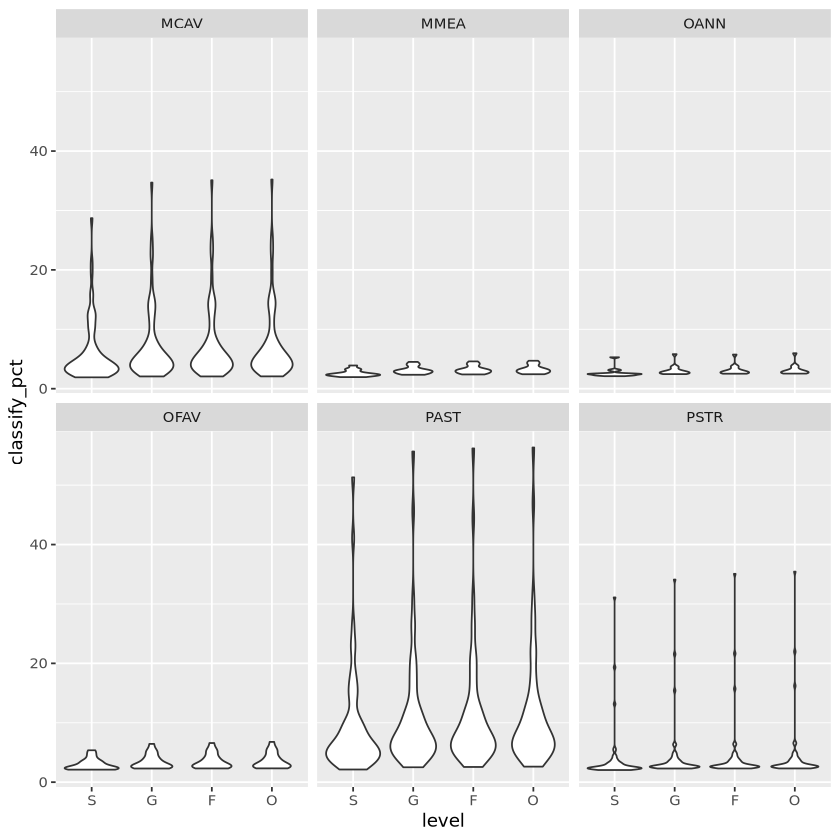

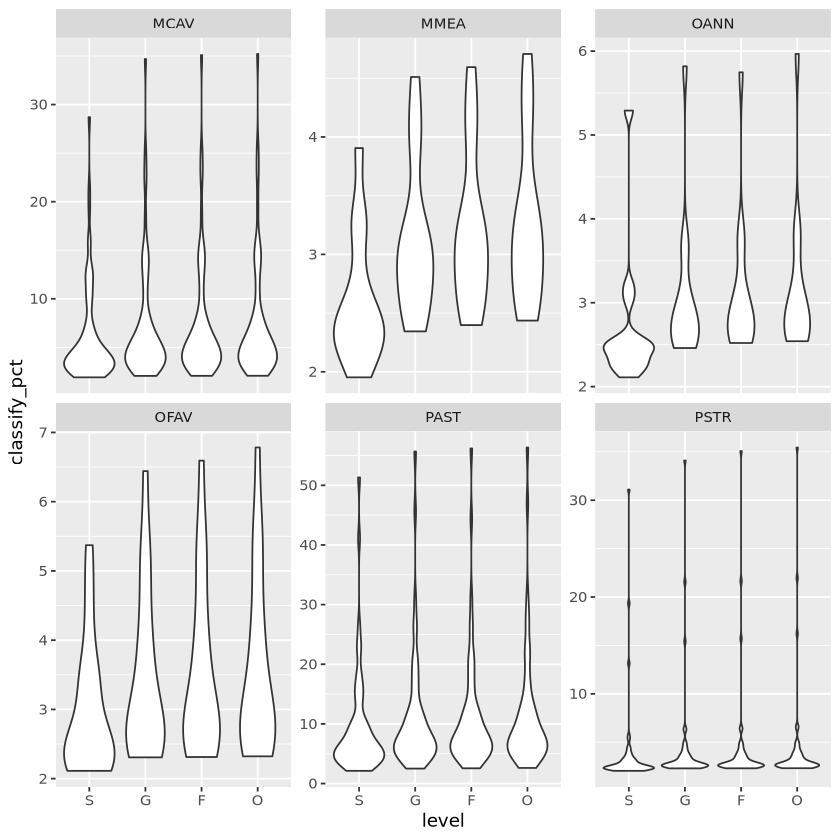

In [84]:
# add spp
summary_df<-summary_df %>%
    mutate(coral_specie = str_extract(sampleid, "[A-Z]+$"))

# and plot
ggplot(summary_df, aes(x = level, y = classify_pct))+
    geom_violin()+
    facet_wrap(~coral_specie)
ggplot(summary_df, aes(x = level, y = classify_pct))+
    geom_violin()+
    facet_wrap(~coral_specie, scales = "free_y")
# a little bit higher classification as you go to higher taxonomic rank
# past and mcav highest classification, then pstr 

In [92]:
colnames(summary_df)

[1] "sampleid"     "level"        "total_reads"  "reads_kept"   "classify_pct"
[6] "coral_specie"

In [101]:
summary_long<-summary_df %>%
    dplyr::rename(reads_classified = reads_kept)%>%
    mutate(total_read_count = total_reads) %>% # keep a copy to reorder 
    pivot_longer(cols = c('total_reads','reads_classified'),
                 names_to = "reads",
                 values_to = "read_count")

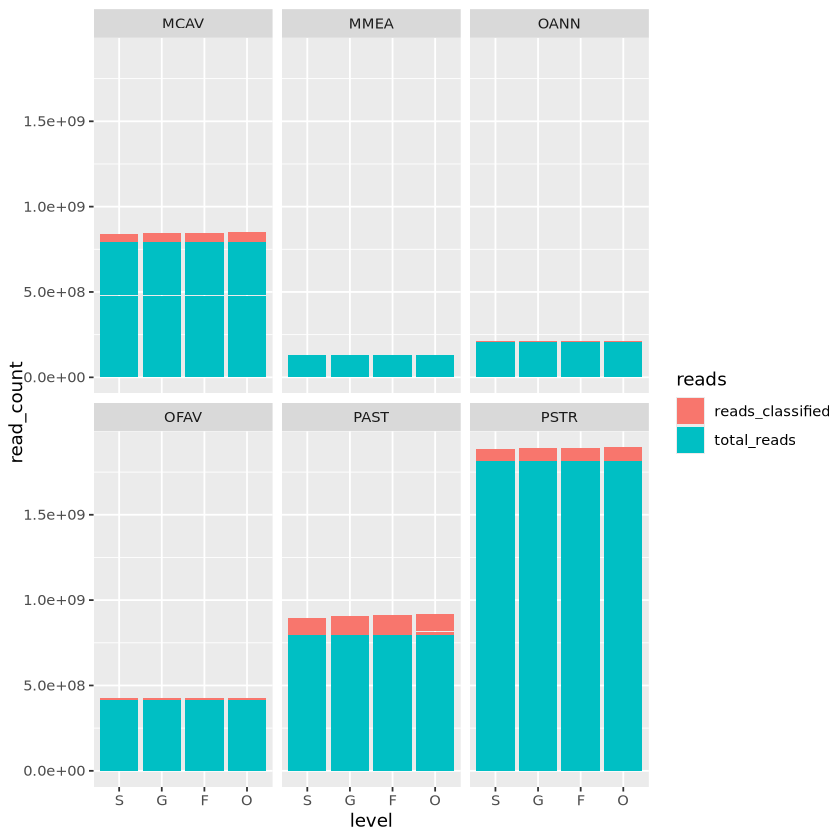

In [103]:
ggplot(summary_long)+
    geom_bar(aes(x = level, y = read_count, fill = reads), stat = "identity", position = "stack")+
    facet_wrap(~coral_specie)

## Upload Data

In [110]:
LEVEL="G"
setwd(paste0("/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/",LEVEL))

### Taxonomy 

In [114]:
LEVEL="G"
taxa = read.csv(paste0('otu_id_',LEVEL,'.csv'),header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,662,Vibrio,G
2,657,Photobacterium,G
3,246861,Grimontia,G
4,511678,Aliivibrio,G
5,188143,Enterovibrio,G
6,51366,Salinivibrio,G


In [117]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","genus")

In [118]:
head(taxa)

,otuid,genus
,<int>,<chr>
1,662,Vibrio
2,657,Photobacterium
3,246861,Grimontia
4,511678,Aliivibrio
5,188143,Enterovibrio
6,51366,Salinivibrio


In [119]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,genus
,<chr>
662,Vibrio
657,Photobacterium
246861,Grimontia
511678,Aliivibrio
188143,Enterovibrio
51366,Salinivibrio


In [120]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy)    

 chr [1:3656, 1] "Vibrio" "Photobacterium" "Grimontia" "Aliivibrio" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:3656] "662" "657" "246861" "511678" ...
  ..$ : chr "genus"


#### OTU Raw

In [123]:
#read in raw otu table
otu_raw = read.csv("otu_table_G.csv",header=TRUE)
# remove prefix and suffixes from sampleIDs
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), ".kreport2_G.bracken_num", "")
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), "X", "")

In [124]:
head(otu_raw)

,taxonomy_id,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,662,38814,22097,10719,1354,1540,3382,2976,6353,4305,⋯,4554,2871,4464,3632,10982,4322,14905,5914,4263,13166
2,657,1092,687,604,146,244,678,583,388,168,⋯,697,366,648,509,2061,577,2270,164,67,139
3,246861,212,114,66,28,49,65,46,36,16,⋯,67,31,107,40,238,78,404,162,14,10
4,511678,197,113,114,64,55,77,54,55,36,⋯,146,68,119,129,423,121,528,0,0,10
5,188143,99,85,25,15,11,40,155,11,0,⋯,70,90,53,88,148,74,154,162,48,82
6,51366,72,40,82,0,48,58,519,78,23,⋯,40,662,28,292,67,17,73,0,0,26


In [125]:
# rename first col as otu
names(otu_raw)[1] <- "otu"

# make the index the otus
row.names(otu_raw) <- otu_raw$otu
otu_raw$otu <- NULL

# sort by most abundant OTUs
otu_raw_sorted <- otu_raw[order(rowSums(otu_raw), decreasing = TRUE), ]

# Convert to matrix
otus_raw=as.matrix(otu_raw_sorted)
head(otus_raw)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
374,2324,1814,279080,40269,39132,25000,3211,89739,63122,801,⋯,11427,33196,591534,21474,17369,597847,3402,11137721,3196295,555538
1912216,158,303,12075,934,6929,1602,159,632,1463,107,⋯,168,2685,122016,567,264,10865,1388,26743,29328,6708276
1883,10173,7168,11972,4373,1838,34081,7497,4346,2453,3664,⋯,7075,5651,11651,7637,15757,11015,18168,138620,31442,27012
445219,85,60,103,28,12,883,43,9306,0,0,⋯,1871,86,53130,5863,7650,69685,77,2310994,503217,230
286,6620,4525,8315,2810,3334,15597,3949,3096,2892,1857,⋯,4758,3725,18592,4916,11971,8194,14529,122426,29302,193606
3056650,60,74,59,0,0,350,67,12,0,11,⋯,26,44,348,40,44,46,61,444,102,11


In [128]:
# look what most abundant is 
indices<-c("374", "1912216", "1883","445219","286")
taxa[indices,]
# cutibacterium is human skin microbe but the rest seem ok

[1] "Bradyrhizobium" "Cutibacterium"  "Streptomyces"   "Reyranella"    
[5] "Pseudomonas"

### Metadata

In [129]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/G"

In [130]:
#read in metadata
# in pstr version i directly uploaded cbc samples and cbc colony data
# going to try my already merged meta+sampleid table that I made in read_counts..

metadata=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/reads_meta.csv', header=TRUE)

# index the SampleIDs and remove raw read counts
metadata$raw <- NULL
metadata$trimmed <- NULL
metadata$pct_yield <- NULL

# row.names(metadata) <- metadata$sampleid
# metadata$sampleid <- NULL
head(metadata)

,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,052022_BEL_CBC_T1_10_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,10,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
2,052022_BEL_CBC_T1_11_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,11,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
3,052022_BEL_CBC_T1_12_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,12,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
4,052022_BEL_CBC_T1_13_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,13,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
5,052022_BEL_CBC_T1_1_PAST,52022,5/21/22,CBC30N,1,2,PAST,1,Healthy,T1_2_PAST,52022_PAST_Healthy
6,052022_BEL_CBC_T1_34_PAST,52022,5/21/22,CBC30N,1,21,PAST,34,Healthy,T1_21_PAST,52022_PAST_Healthy


In [131]:
# create list of colony IDs in sample set 
colony_list<-unique(metadata$colony_id)
# NAs are all negative controls

In [132]:
unique(metadata$Month_year)
# what months do we need conditions from colonydata

[1]  52022  62019 102019 122022     NA

In [133]:
# upload colony data to add Resistant vs Susceptible category

colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [134]:
# add colony id and filter for target colonies
colony$colony_id<-paste0("T", colony$TransectNum, "_", colony$NewTagNum,"_",colony$Species)

# remove cols
colony_filtered<-colony %>%
    select(colony_id, Date_InitialTag, Date_DocumentedDisease, Date_DocumentedMortality, X062019_Condition,X102019_Condition, X052022_Condition,X122022_Condition,X092023_Condition)

# filter for target samples' colony IDs
colony_filtered<-colony_filtered %>%
    filter(colony_id %in% colony_list)

In [135]:
# merge sample and colony data 
sample_colony=merge(metadata, colony_filtered, by="colony_id")

In [141]:
# add labels to negative and remove accidental sample
sample_colony<-sample_colony %>%
    filter(NewTagNum != "AS") %>%
    mutate(colony_id = case_when(
        sampleid == "7_3_Neg" ~ "Neg1",
        sampleid == "7_11_Neg" ~ "Neg2",
        sampleid == "Negative_extract_11-2-24" ~ "Neg3",
        TRUE ~ colony_id
    ))

In [142]:
sample_colony<-sample_colony %>%
    mutate(RS = case_when(
        X052022_Condition=="Diseased" ~ "Susceptible",
        X052022_Condition=="Dead" ~ "Susceptible",
        X122022_Condition=="Healthy" ~ "Resistant",
        X122022_Condition=="Diseased" ~ "Susceptible",
        X122022_Condition=="Dead" ~ "Susceptible",
        Date_DocumentedDisease=="Healthy" ~ "Resistant",
        Date_DocumentedMortality=="Healthy" ~ "Resistant"))

In [143]:
unique(sample_colony$RS)

[1] "Resistant"   "Susceptible" NA

In [146]:
# remove past that we never found again 
    # (only colony that is NA in RS category)

sample_colony<-sample_colony %>%
    filter(!is.na(RS))

# reset all PASTs to resistant
sample_colony<-sample_colony %>%
    mutate(RS = if_else(Species == "PAST", "Resistant",RS))

In [147]:
table(sample_colony$RS)


  Resistant Susceptible 
        125          92 

In [148]:
# add year
sample_colony<-sample_colony %>%
    mutate(year = format(my(Month_year), "%Y")) %>%
    mutate(month_year = factor(format(my(Month_year), "%b %Y"), levels = c("Jun 2019","Oct 2019","May 2022","Dec 2022")))

In [149]:
# set sampleids as rownames
rownames(sample_colony)=sample_colony$sampleid
# sample_colony$sampleid<-NULL # keep sampleids as col for now

In [150]:
# remove bel cbc from sampleid
sample_colony<-sample_colony %>%
    mutate(sampleid = str_replace(sampleid, "_BEL_CBC",""))
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_55_PSTR,T1_12_PSTR,052022_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,May 2022
102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019,Oct 2019
122022_BEL_CBC_T1_122_PSTR,T1_12_PSTR,122022_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
122022_BEL_CBC_T1_152_PAST,T1_13_PAST,122022_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
052022_BEL_CBC_T1_53_PAST,T1_13_PAST,052022_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,May 2022
062019_BEL_CBC_T1_12_PAST,T1_13_PAST,062019_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2019,Jun 2019


## PhyloSeq

In [151]:
# classify phyloseq objects 
OTU=otu_table((otus_raw), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(sample_colony)

In [152]:
# Create raw phyloseq object
sctld_raw<-phyloseq(OTU, SAMP, TAX)
sctld_raw

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 3656 taxa and 217 samples ]
sample_data() Sample Data:       [ 217 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 3656 taxa by 1 taxonomic ranks ]

In [69]:
# sctld_raw.ord <- ordinate(sctld_raw, "NMDS", "bray", trymax=1000)

In [71]:
sample_colony %>%
    filter(sampleid == "122022_T2_93_OFAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
122022_BEL_CBC_T2_93_OFAV,T2_76_OFAV,122022_T2_93_OFAV,122022,12/4/22,SR30N,2,76,ORBI,93,Healthy,⋯,Healthy,Healthy,NA,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022


In [153]:
# remove MCAV mistake 
mistake<- c("052022_BEL_CBC_T1_54_MCAV")
sctld_raw <- prune_samples(!(sample_names(sctld_raw) %in% mistake), sctld_raw)
# remove outliers for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
sctld_raw2 <- prune_samples(!(sample_names(sctld_raw) %in% outlier), sctld_raw)

In [154]:
# and remove human skin microbes - cutibacterium acnes
keep <- as.vector(tax_table(sctld_raw2)[, "genus"] != "Cutibacterium")
sctld_raw2 <- prune_taxa(keep, sctld_raw2)
sctld_raw <- prune_taxa(keep, sctld_raw)

### Diversity

In [155]:
sctld_raw2.ord <- ordinate(sctld_raw2, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1126723 
Run 1 stress 0.1126717 
... New best solution
... Procrustes: rmse 0.0004560941  max resid 0.00635612 
... Similar to previous best
Run 2 stress 0.1126717 
... Procrustes: rmse 2.048898e-05  max resid 0.0002113106 
... Similar to previous best
Run 3 stress 0.1126723 
... Procrustes: rmse 0.0004505221  max resid 0.006301232 
... Similar to previous best
Run 4 stress 0.1126723 
... Procrustes: rmse 0.0004466834  max resid 0.006243873 
... Similar to previous best
Run 5 stress 0.1126717 
... Procrustes: rmse 2.432237e-05  max resid 0.0003284988 
... Similar to previous best
Run 6 stress 0.1126723 
... Procrustes: rmse 0.0004473646  max resid 0.006254621 
... Similar to previous best
Run 7 stress 0.1126723 
... Procrustes: rmse 0.0004471078  max resid 0.006253389 
... Similar to previous best
Run 8 stress 0.1126723 
... Procrustes: rmse 0.0004515855  max resid 0.006306622 
... Similar to previous best
Run 9

In [156]:
library(paletteer)

In [157]:
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [159]:
custom_list<-c("#7290ba",
"#d77a51",
"#8748c6",
"#759b50",
"#cc5893",
"#b05e3f")

In [160]:
# names(coral_colors) <- unique(metadata$Species)
names(custom_list) <- unique(metadata$Species)

In [162]:
# coral_colors
custom_list

PSTR      MCAV      PAST      ORBI      MMEA       NEG 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

In [166]:
options(repr.plot.width=15, repr.plot.height=10)

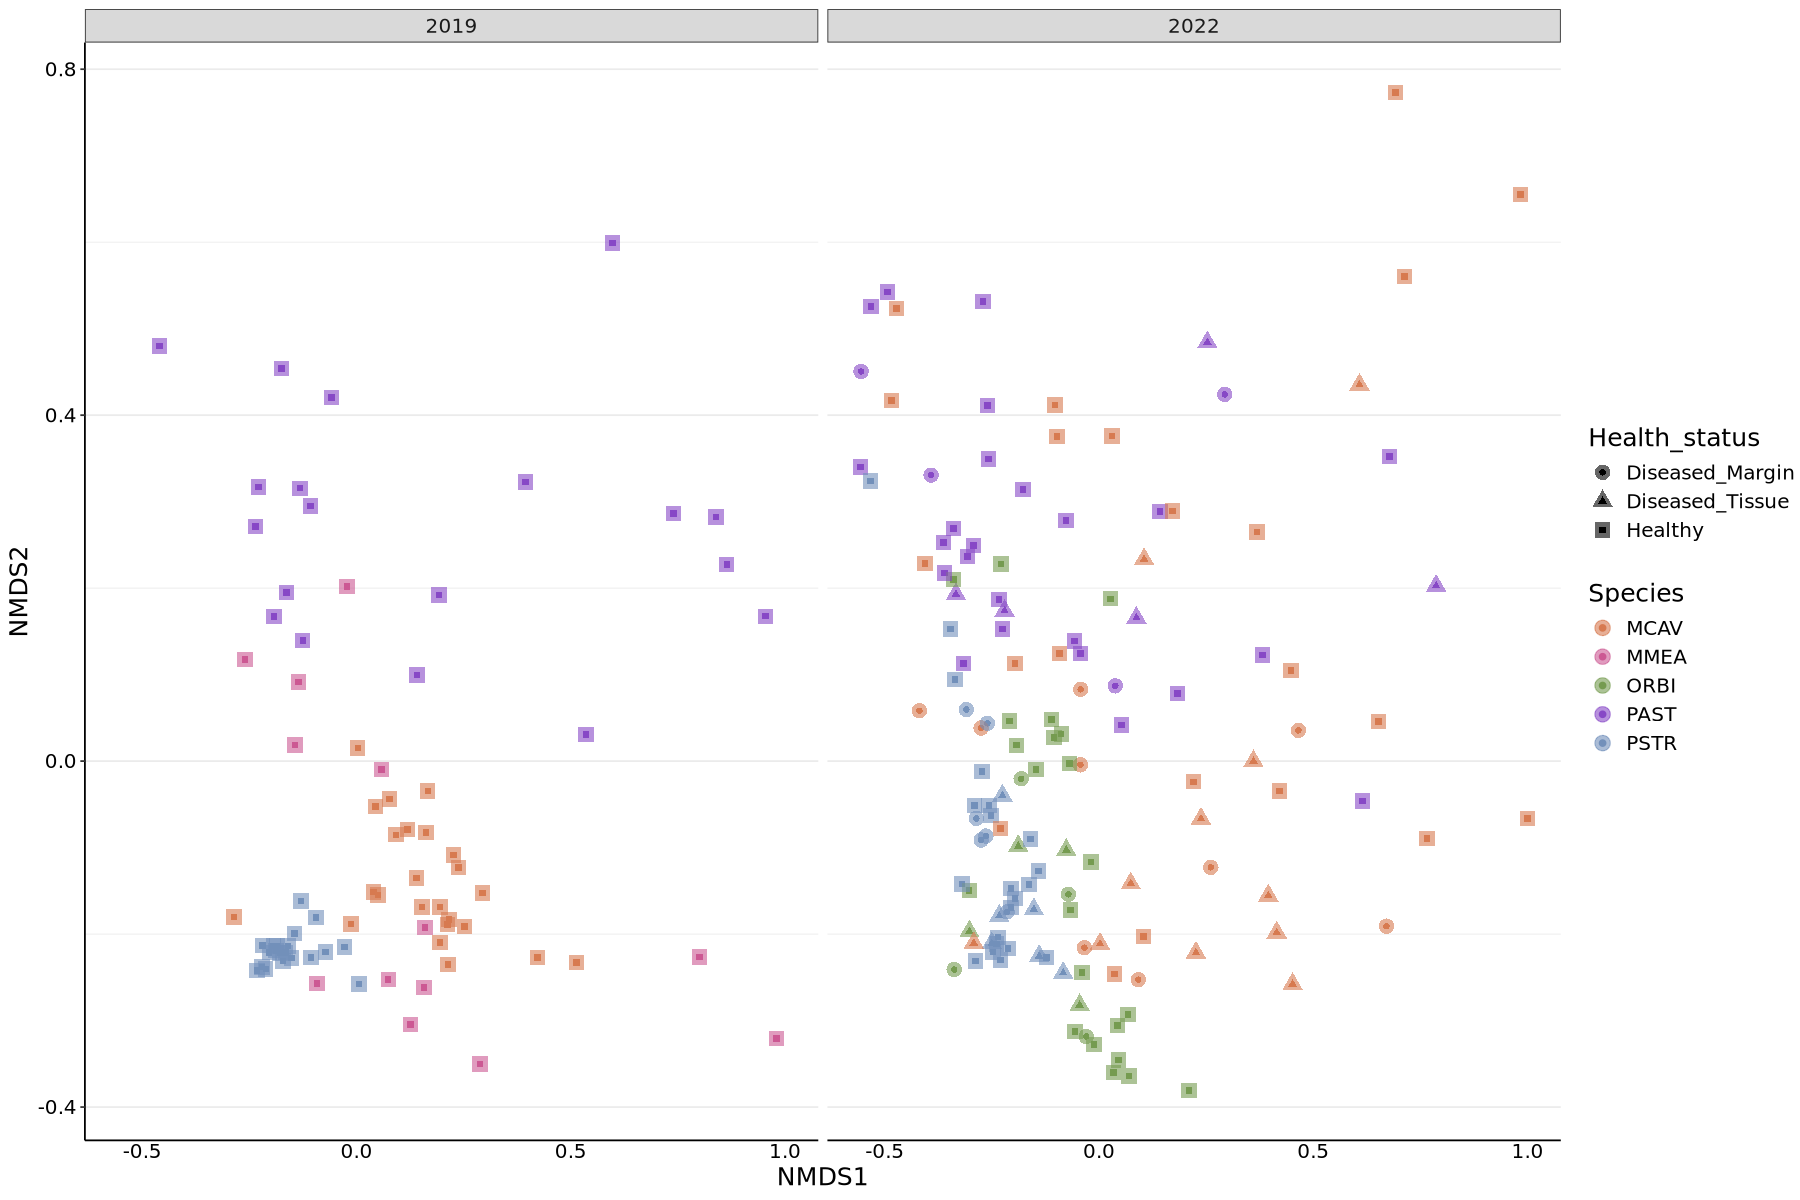

In [167]:
# facet by year
sctld_raw_plot <- plot_ordination(sctld_raw2, sctld_raw2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_raw_plot

# all samples - separated by 2019 and 2022

In [217]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_raw2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1083978 
Run 1 stress 0.1083978 
... New best solution
... Procrustes: rmse 8.158545e-06  max resid 4.491827e-05 
... Similar to previous best
Run 2 stress 0.1084384 
... Procrustes: rmse 0.003170831  max resid 0.02110292 
Run 3 stress 0.1084384 
... Procrustes: rmse 0.003156803  max resid 0.02098594 
Run 4 stress 0.1084384 
... Procrustes: rmse 0.00318036  max resid 0.02117255 
Run 5 stress 0.1243225 
Run 6 stress 0.1084384 
... Procrustes: rmse 0.003134021  max resid 0.02079975 
Run 7 stress 0.1243225 
Run 8 stress 0.1083978 
... Procrustes: rmse 1.213765e-05  max resid 8.706843e-05 
... Similar to previous best
Run 9 stress 0.1084384 
... Procrustes: rmse 0.003140984  max resid 0.0208619 
Run 10 stress 0.1083978 
... New best solution
... Procrustes: rmse 3.552684e-06  max resid 1.970707e-05 
... Similar to previous best
Run 11 stress 0.1083978 
... Procrustes: rmse 1.037471e-05  max resid 5.965168e-05 
... S

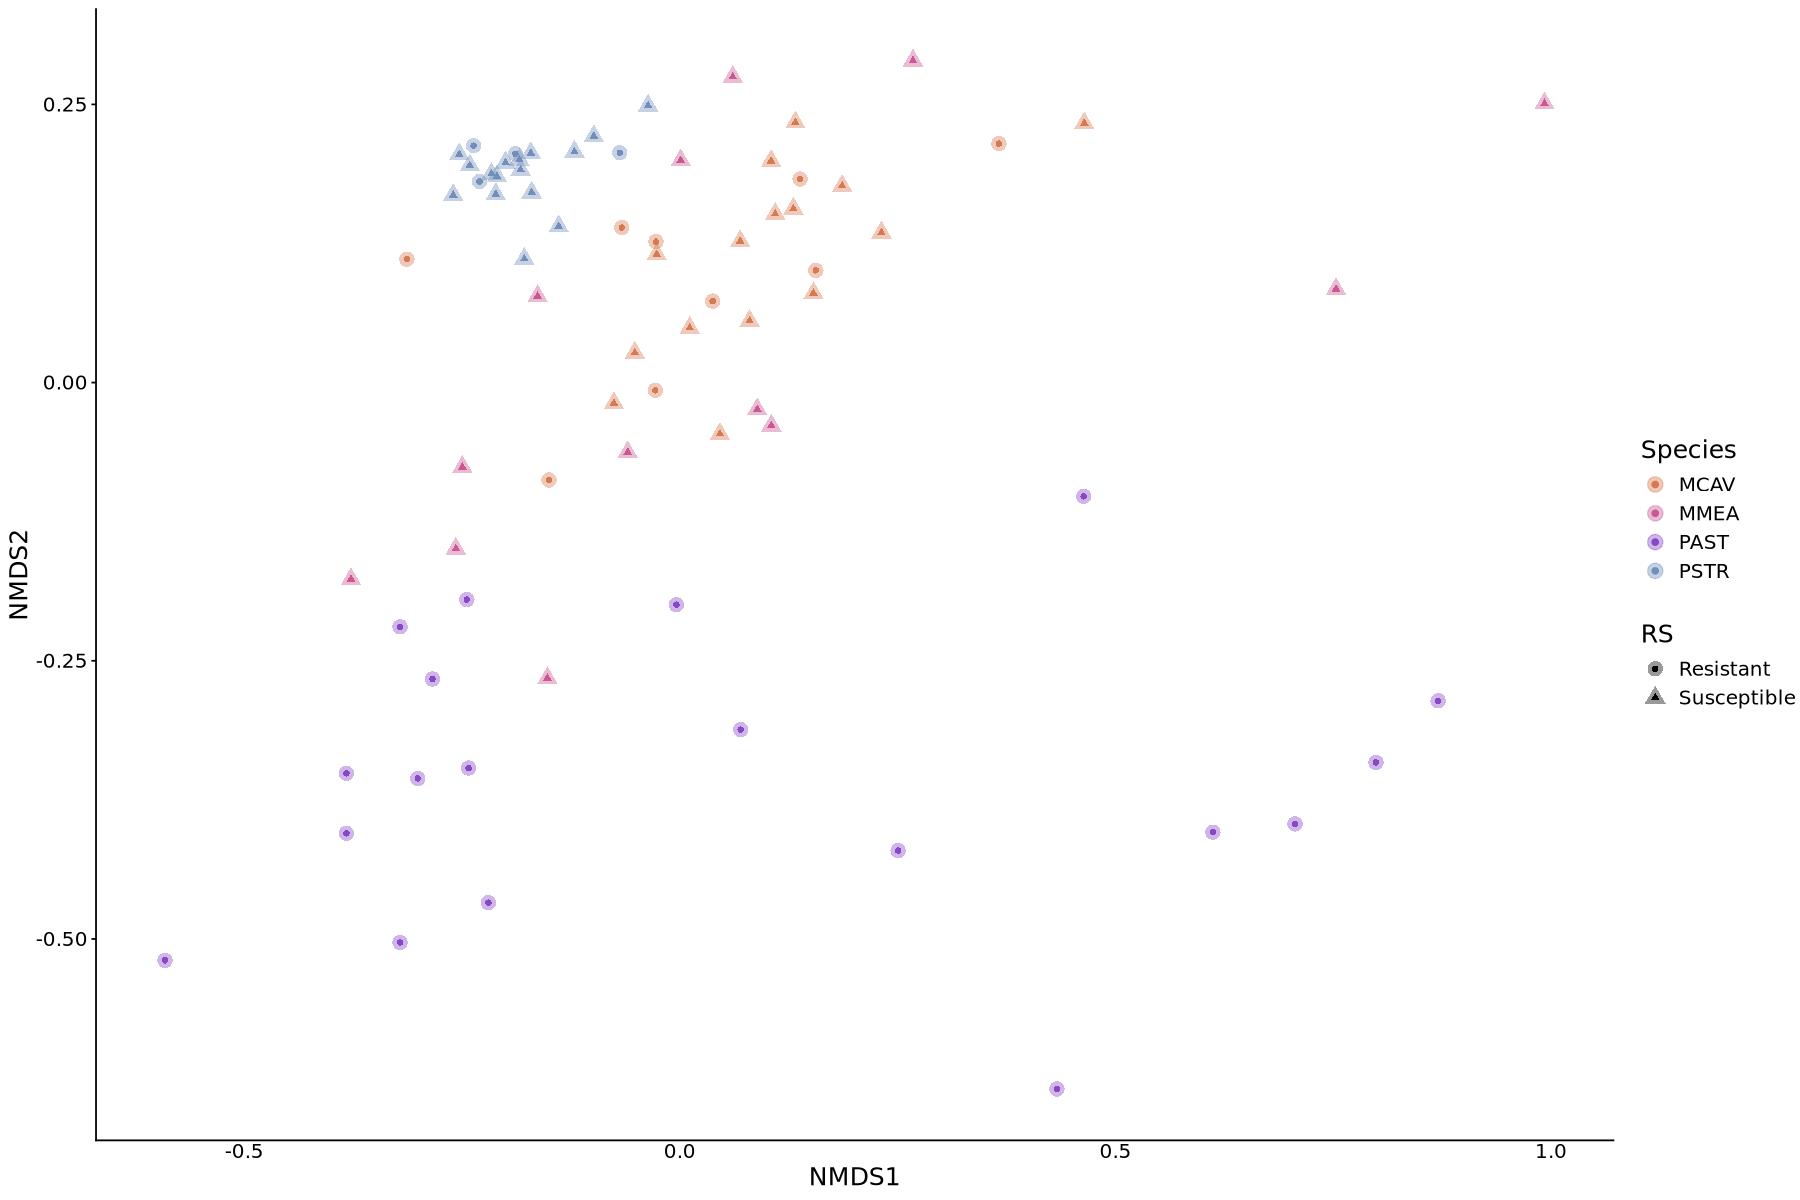

In [169]:
nmds_2019<-plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.4) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
# facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_classic()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
nmds_2019


# 2019 only 

In [213]:
# ggsave(filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/plots/RS_2019_nmds.png", plot = nmds_2019, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

In [170]:
RS.ord
# Stress: 0.108


Call:
metaMDS(comm = veganifyOTU(physeq), distance = distance, trymax = 1000) 

global Multidimensional Scaling using monoMDS

Data:     wisconsin(sqrt(veganifyOTU(physeq))) 
Distance: bray 

Dimensions: 2 
Stress:     0.1083978 
Stress type 1, weak ties
Best solution was repeated 7 times in 20 tries
The best solution was from try 1 (random start)
Scaling: centring, PC rotation, halfchange scaling 
Species: expanded scores based on ‘wisconsin(sqrt(veganifyOTU(physeq)))’ 


Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


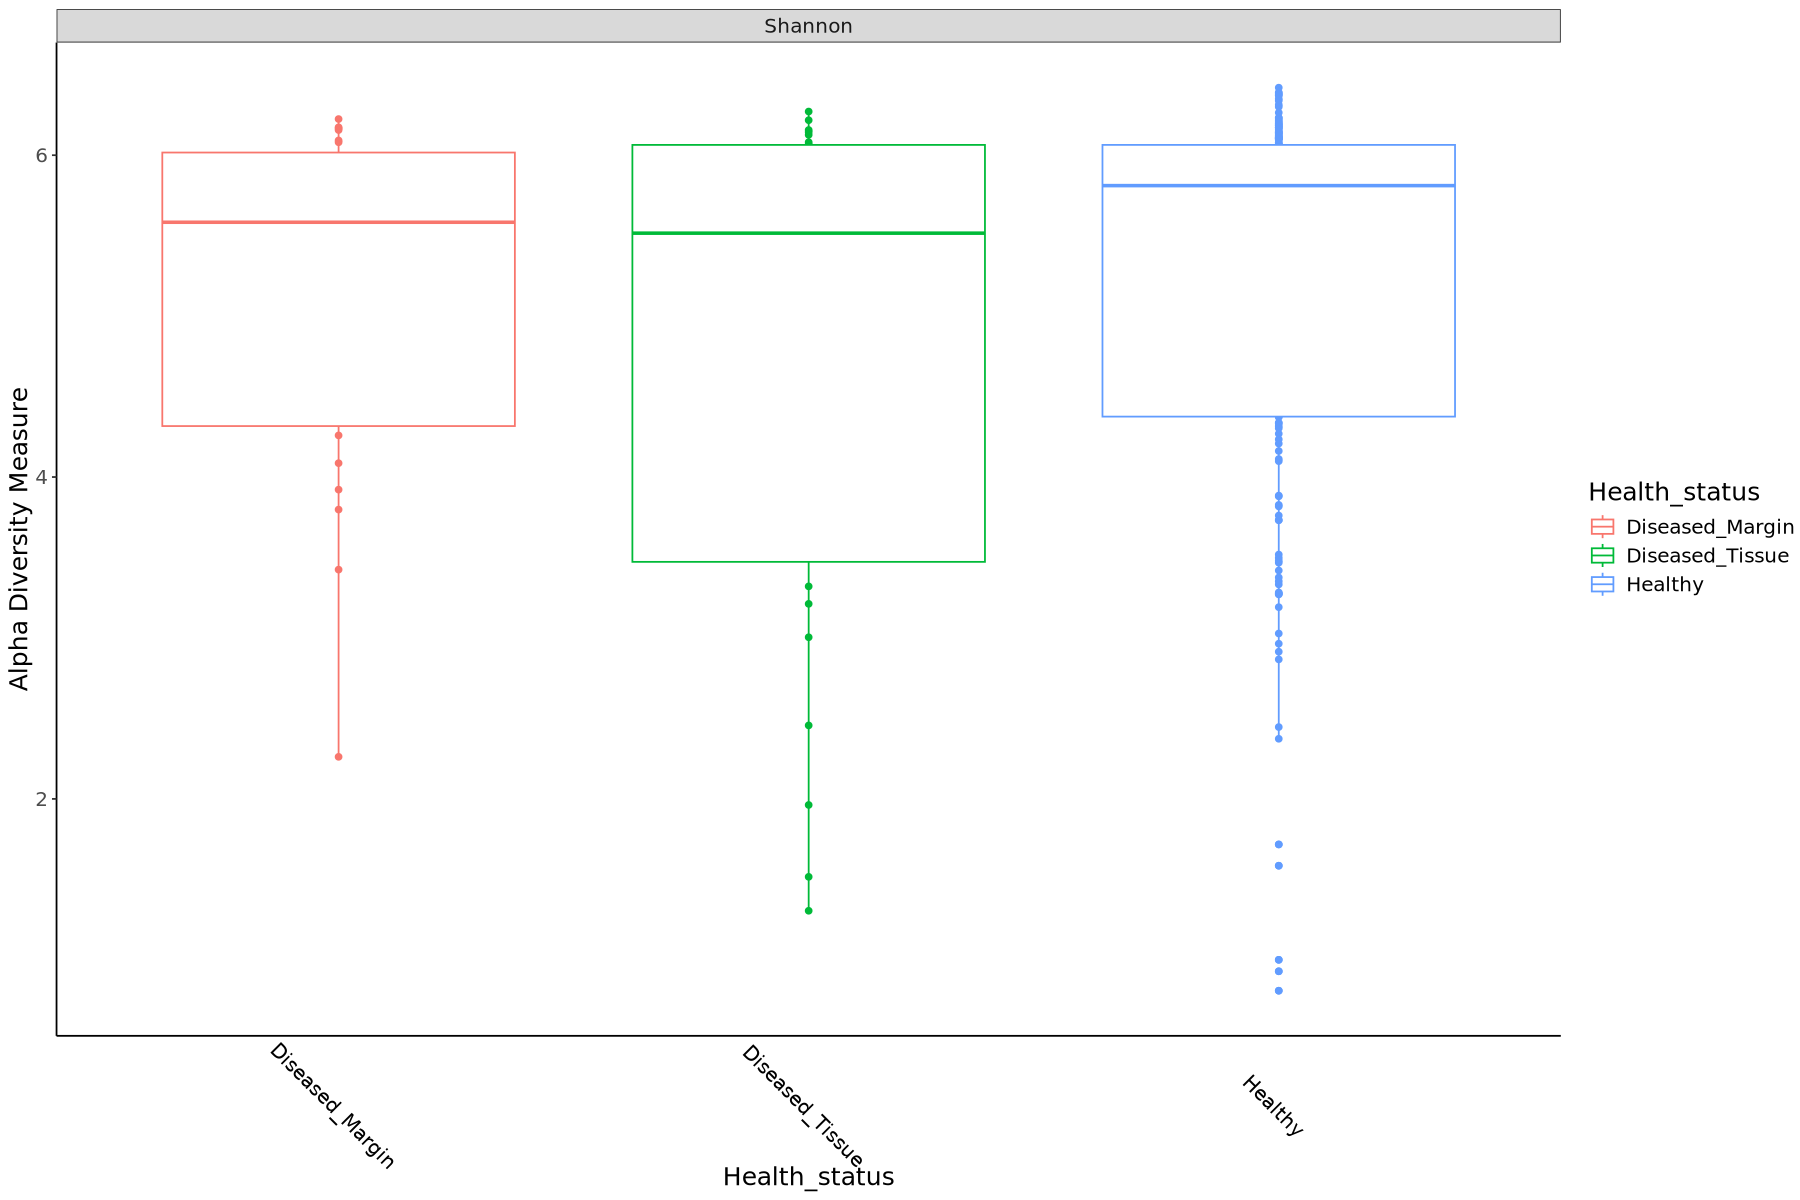

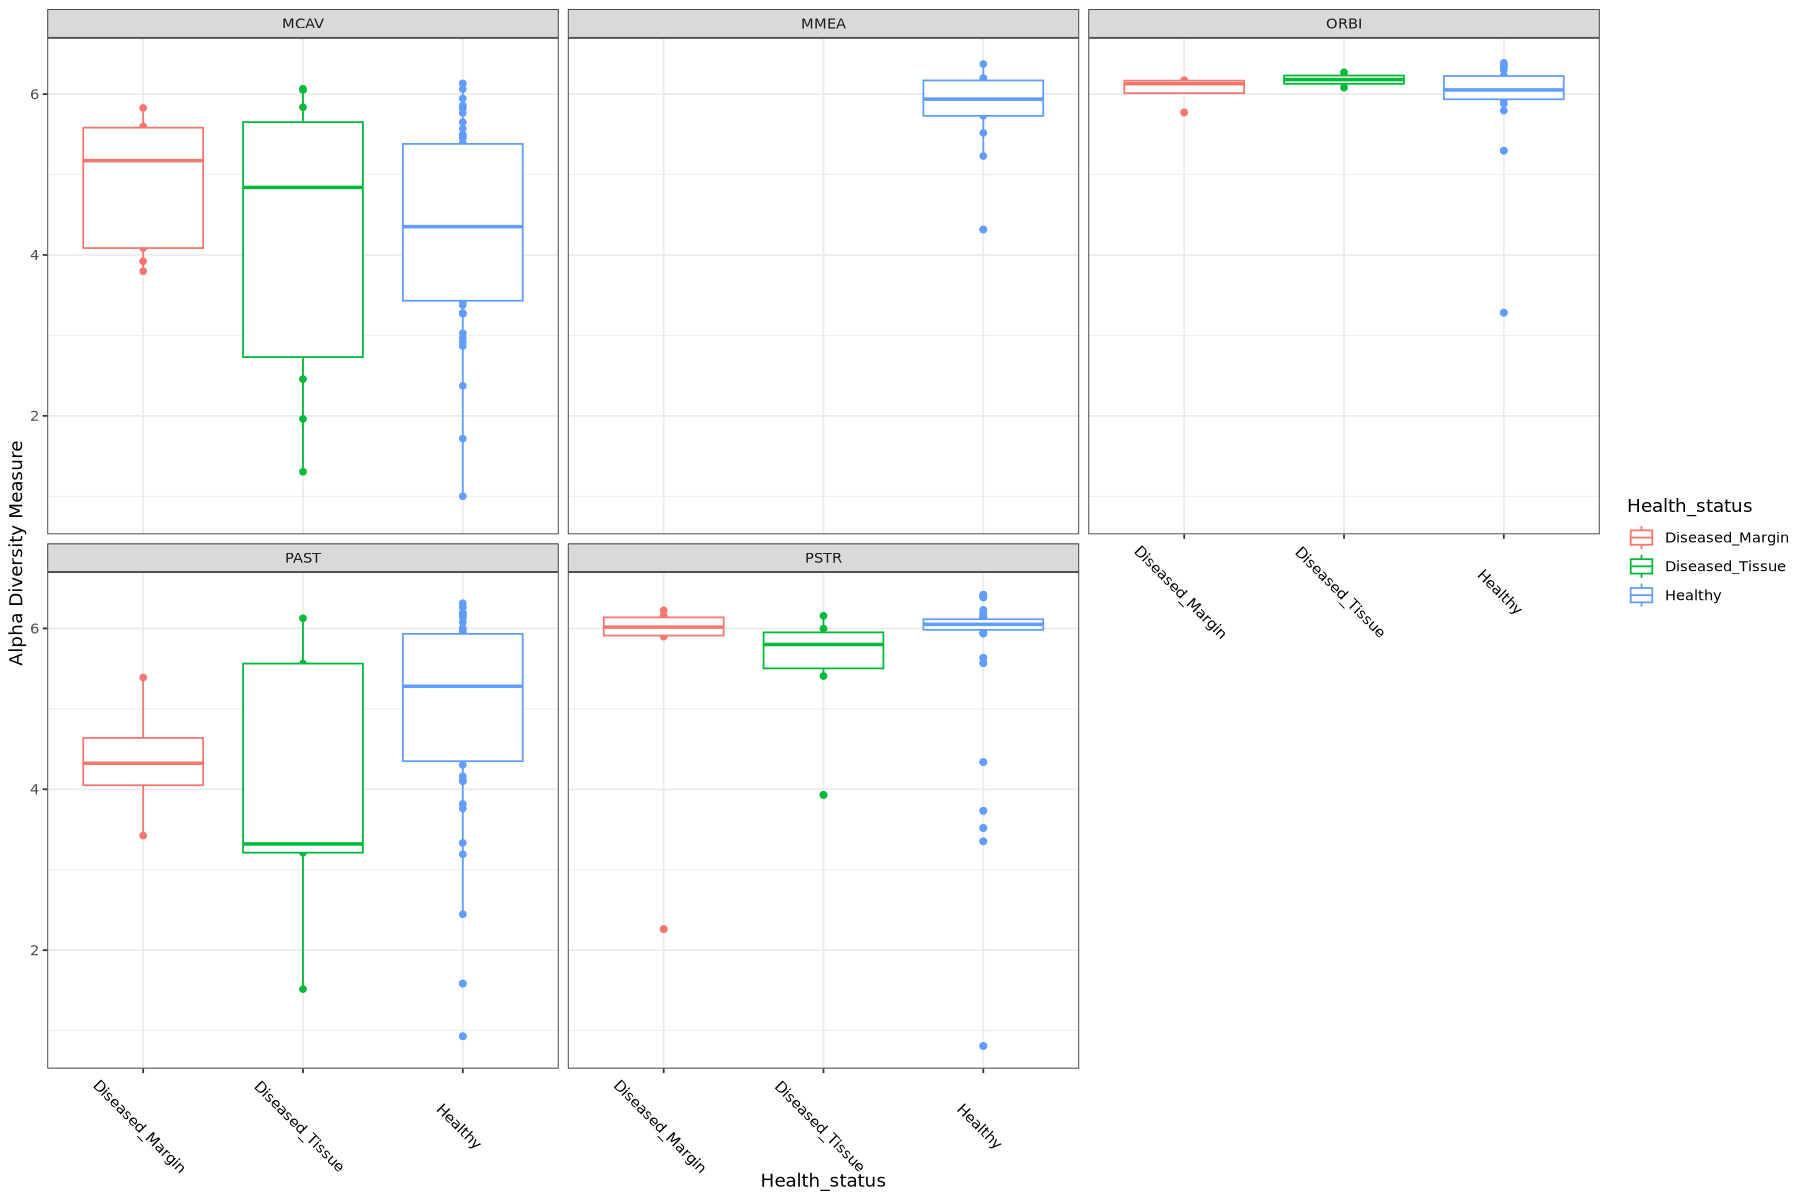

In [171]:
rich_status <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
    geom_boxplot() +
    # facet_wrap(~Species)+
    theme_bw()+
     theme(legend.position = "right",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_blank(),
        panel.grid.minor.y = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line = element_line(color = "black"),
        axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
        text = element_text(size = 15))
rich_status

plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

# all samples - spp x disease status

In [86]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


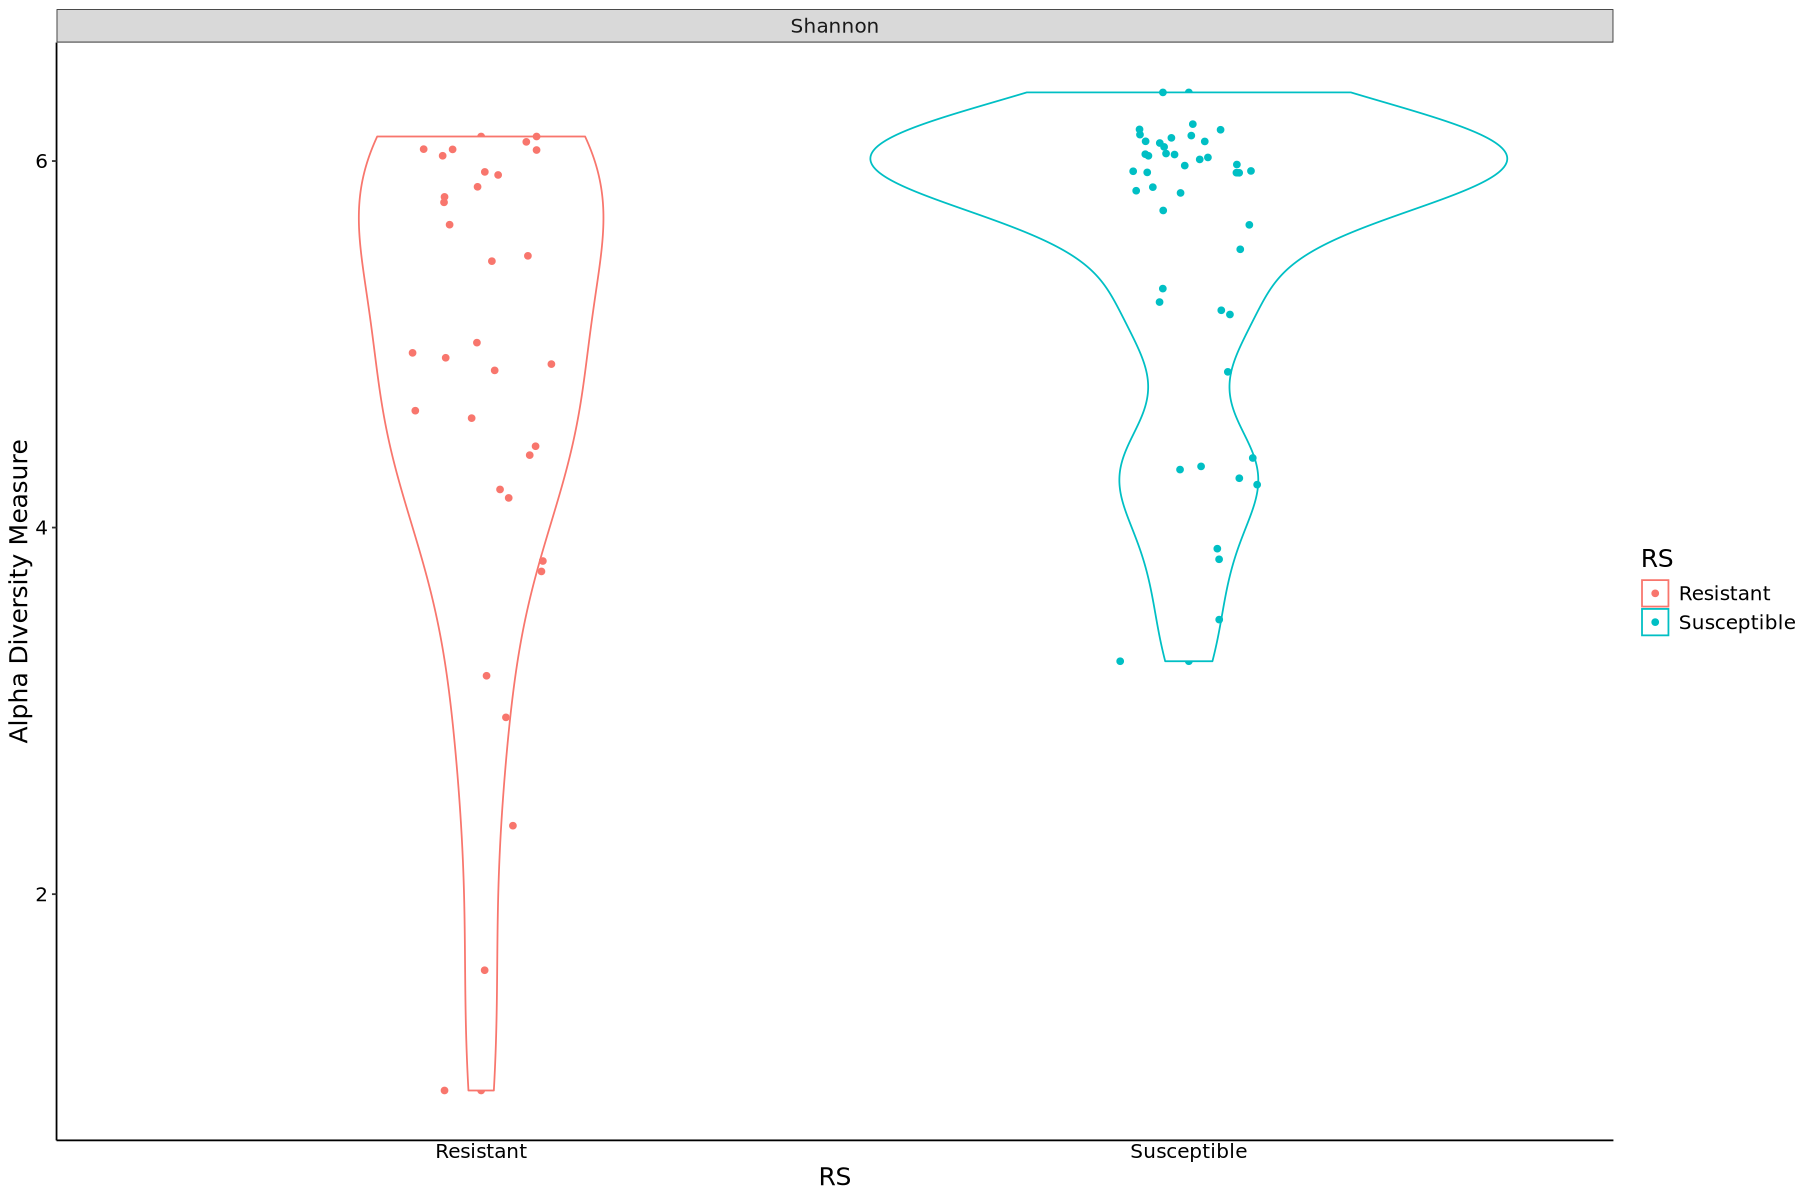

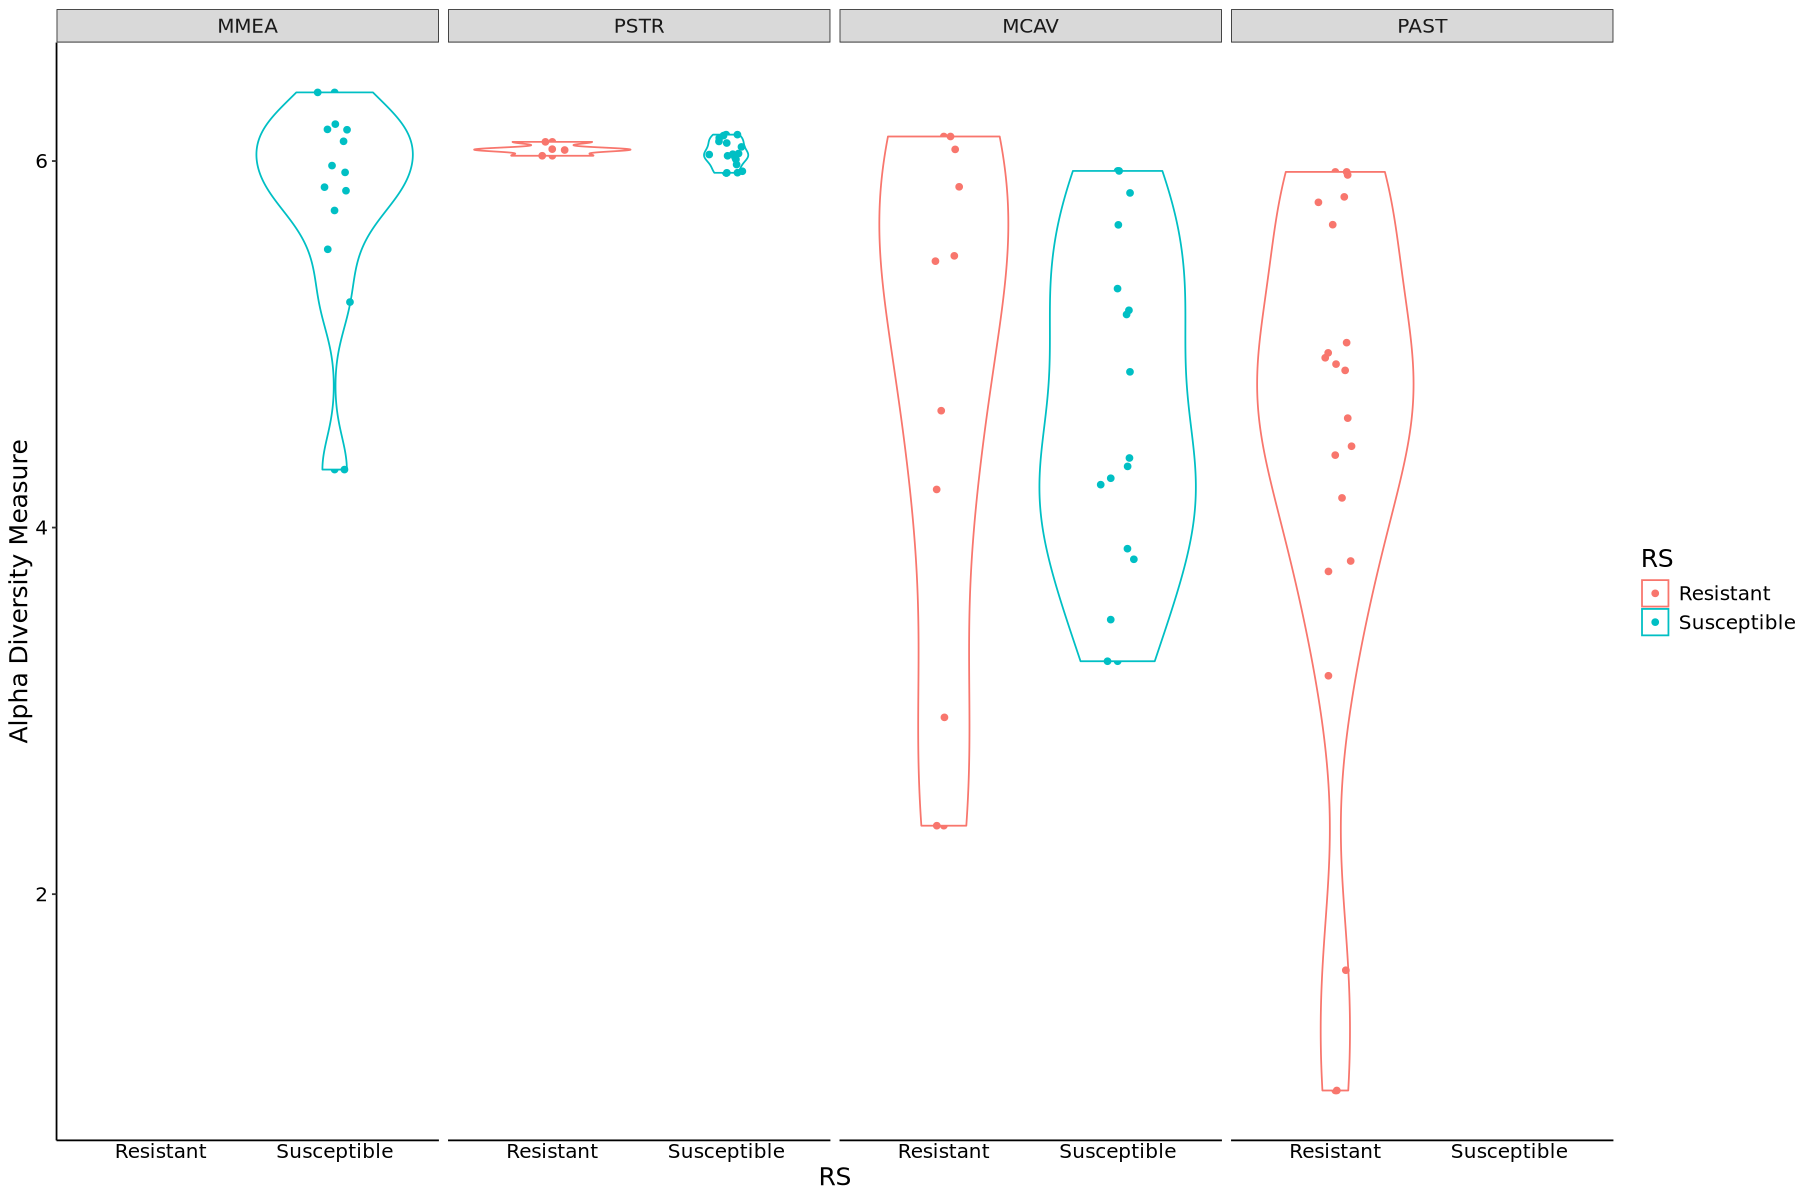

In [172]:
# order of species susceptibility 
# reorder colonies most -> least sus
spp_order<-c("MMEA",'PSTR','MCAV','PAST')
df_meta<-data.frame(sample_data(RS_ps))
sample_data(RS_ps)$Species <-
  factor(sample_data(RS_ps)$Species, levels = spp_order)

rich_status1 <- plot_richness(RS_ps, x="RS", color="RS", measures=c("Shannon")) + geom_violin() +
geom_jitter(height = 0, width = 0.1)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_grid(~Species)

# R vs S - 2019 only 

In [88]:
# most susceptible species are more diverse

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


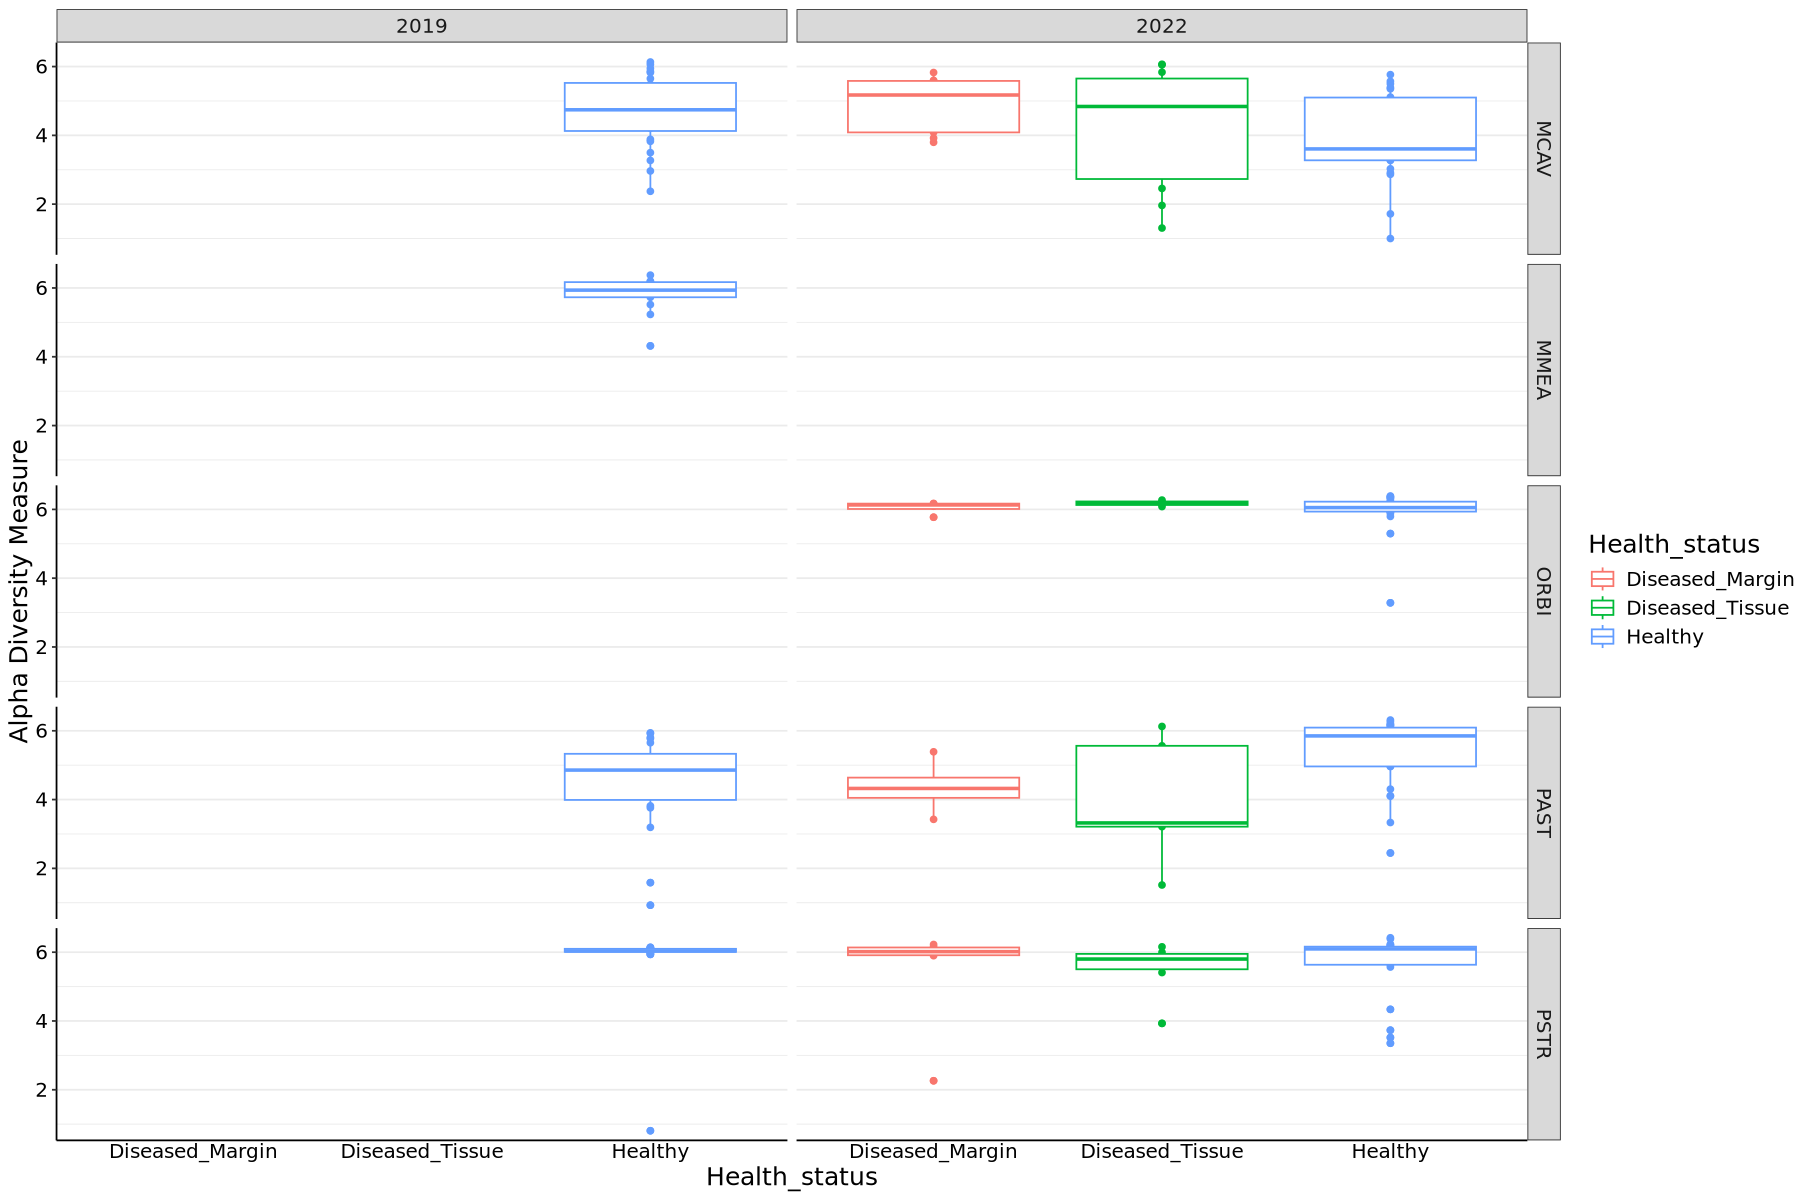

In [173]:
rich_species <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

rich_species+
    facet_grid(Species~year)

# all samples - year x spp x health status

In [174]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_raw2, method = "bray")
metadata2 <- as(phyloseq::sample_data(sctld_raw2), "data.frame")

In [175]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)
# all samples

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    1.492 0.03176  8.9240  0.001 ***
Species           4    9.162 0.19507 13.7043  0.001 ***
year              1    1.523 0.03244  9.1151  0.001 ***
RS:Species        2    0.236 0.00502  0.7058  0.755    
RS:year           1    0.120 0.00256  0.7208  0.618    
Species:year      2    0.711 0.01514  2.1267  0.020 *  
RS:Species:year   1    0.129 0.00274  0.7693  0.625    
Residual        201   33.594 0.71527                   
Total           213   46.967 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [176]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2       F Pr(>F)    
Health_status           2    0.699 0.01488  2.1227  0.013 *  
RS                      1    1.911 0.04069 11.6067  0.001 ***
Species                 4    9.007 0.19177 13.6762  0.001 ***
year                    1    1.144 0.02437  6.9507  0.001 ***
Health_status:RS        2    0.321 0.00683  0.9735  0.447    
Health_status:Species   4    0.570 0.01213  0.8650  0.652    
RS:Species              2    0.236 0.00503  0.7178  0.757    
RS:year                 1    0.173 0.00368  1.0504  0.355    
Species:year            2    0.728 0.01551  2.2118  0.014 *  
RS:Species:year         1    0.402 0.00855  2.4400  0.022 *  
Residual              193   31.776 0.67657                   
Total   

In [177]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.699 0.01488  2.1408  0.027 *  
RS                               1    1.911 0.04069 11.7060  0.001 ***
Species                          4    9.007 0.19177 13.7932  0.001 ***
year                             1    1.144 0.02437  7.0102  0.001 ***
Transect                         3    1.077 0.02293  2.1989  0.004 ** 
Health_status:RS                 2    0.330 0.00702  1.0102  0.404    
Health_status:Species            4    0.538 0.01146  0.8240  0.717    
RS:Species                       2    0.227 0.00483  0.6943  0.788    
RS:year                          1    0.121 0.00258  0.7409  0.639    
Species:year                   

In [97]:
# location is more important than health status?

In [178]:
# look at 2022 subset - how much does health status vary
dis_ps<- subset_samples(sctld_raw2, year == '2022')
bray_dist <- phyloseq::distance(dis_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(dis_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.662 0.02060  1.8223  0.043 *  
Species                          3    6.560 0.20405 12.0315  0.001 ***
Transect                         3    1.254 0.03900  2.2995  0.002 ** 
Health_status:Species            6    1.066 0.03315  0.9773  0.489    
Health_status:Transect           6    1.057 0.03289  0.9696  0.525    
Species:Transect                 8    2.036 0.06332  1.4001  0.047 *  
Health_status:Species:Transect  10    1.522 0.04735  0.8375  0.846    
Residual                        99   17.992 0.55966                   
Total                          137   32.148 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 

In [179]:
# species is more important than health status - same as from prelim results

In [180]:
#mcav only
# look at 2022 subset - how much does health status vary
mcav_ps<- subset_samples(sctld_raw2, Species == "MCAV" & year == '2022')
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.5898 0.06394 1.4372  0.168  
RS                      1   0.4438 0.04811 2.1627  0.051 .
Transect                3   0.8528 0.09245 1.3854  0.139  
Health_status:Transect  4   0.9773 0.10594 1.1906  0.279  
Residual               31   6.3611 0.68957                
Total                  41   9.2248 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [181]:
orbi_ps<- subset_samples(sctld_raw2, Species == "ORBI")
bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
print(orbi_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.2629 0.07697 1.1720  0.294  
RS                      1   0.0902 0.02640 0.8039  0.478  
Transect                3   0.6393 0.18713 1.8995  0.054 .
Health_status:Transect  4   0.2993 0.08761 0.6670  0.772  
RS:Transect             1   0.1052 0.03080 0.9380  0.400  
Residual               18   2.0192 0.59108                
Total                  29   3.4161 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [182]:
# maybe we do need to separate out orbi species...

In [183]:
# 2019 only 

In [184]:
bray_dist <- phyloseq::distance(RS_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(RS_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
                    Df SumOfSqs      R2      F Pr(>F)    
RS                   1   0.8049 0.06077 6.2805  0.001 ***
Species              3   3.6718 0.27720 9.5499  0.001 ***
Transect             2   0.1829 0.01381 0.7136  0.731    
RS:Species           1   0.0674 0.00509 0.5259  0.823    
RS:Transect          2   0.1715 0.01294 0.6689  0.785    
Species:Transect     6   0.6892 0.05203 0.8963  0.640    
RS:Species:Transect  1   0.0967 0.00730 0.7542  0.595    
Residual            59   7.5615 0.57086                  
Total               75  13.2459 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [185]:
# within species, how much does RS explain difference

In [186]:
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~  RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Transect, data = mcav_meta, permutations = 999)
            Df SumOfSqs      R2      F Pr(>F)
RS           1  0.14060 0.05389 1.2823  0.240
Transect     2  0.20343 0.07797 0.9277  0.445
RS:Transect  2  0.29133 0.11167 1.3285  0.228
Residual    18  1.97360 0.75647              
Total       23  2.60896 1.00000              


### Taxa Bar Plots

In [187]:
# subset taxa and normalzie out of 100 - genus level
sctld_raw_10 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:10]), sctld_raw)
sctld_raw_10_norm <- transform_sample_counts(sctld_raw_10, function(x) x / sum(x))
     
sctld_raw_30 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:30]), sctld_raw)
sctld_raw_30_norm <- transform_sample_counts(sctld_raw_30, function(x) x / sum(x))

sctld_raw_100 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:100]), sctld_raw)
sctld_raw_100_norm <- transform_sample_counts(sctld_raw_100, function(x) x / sum(x))

In [189]:
g_colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [191]:
# map list of 100 genera to same color
top100_names <- as.character(tax_table(sctld_raw_100)[, "genus"])
names(g_colors) <- top100_names
head(g_colors)

Bradyrhizobium               Streptomyces 
                 "#b73962"                  "#e994a6" 
                Reyranella                Pseudomonas 
                 "#be6b7c"                  "#944557" 
   Candidatus Palauibacter Candidatus Poriferisodalis 
                 "#ea2c68"                  "#e65e74"

In [149]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [194]:
sctld_raw
25486 # taxa at species level from pstr and mcav prelim...
15891 # taxa at species level 
3655 # taxa at genus level 

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 3655 taxa and 216 samples ]
sample_data() Sample Data:       [ 216 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 3655 taxa by 1 taxonomic ranks ]

#### All Spp

In [218]:
# try just each spp R vs S in 2019
sctld_100_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:100]), RS_ps)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))

sctld_50_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:50]), RS_ps)
sctld_50_2019_norm <- transform_sample_counts(sctld_50_2019, function(x) x / sum(x))

sctld_30_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:30]), RS_ps)
sctld_30_2019_norm <- transform_sample_counts(sctld_30_2019, function(x) x / sum(x))
                                              
sctld_10_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:10]), RS_ps)
sctld_10_2019_norm <- transform_sample_counts(sctld_10_2019, function(x) x / sum(x))

In [209]:
options(repr.plot.height = 15, repr.plot.width = 18)

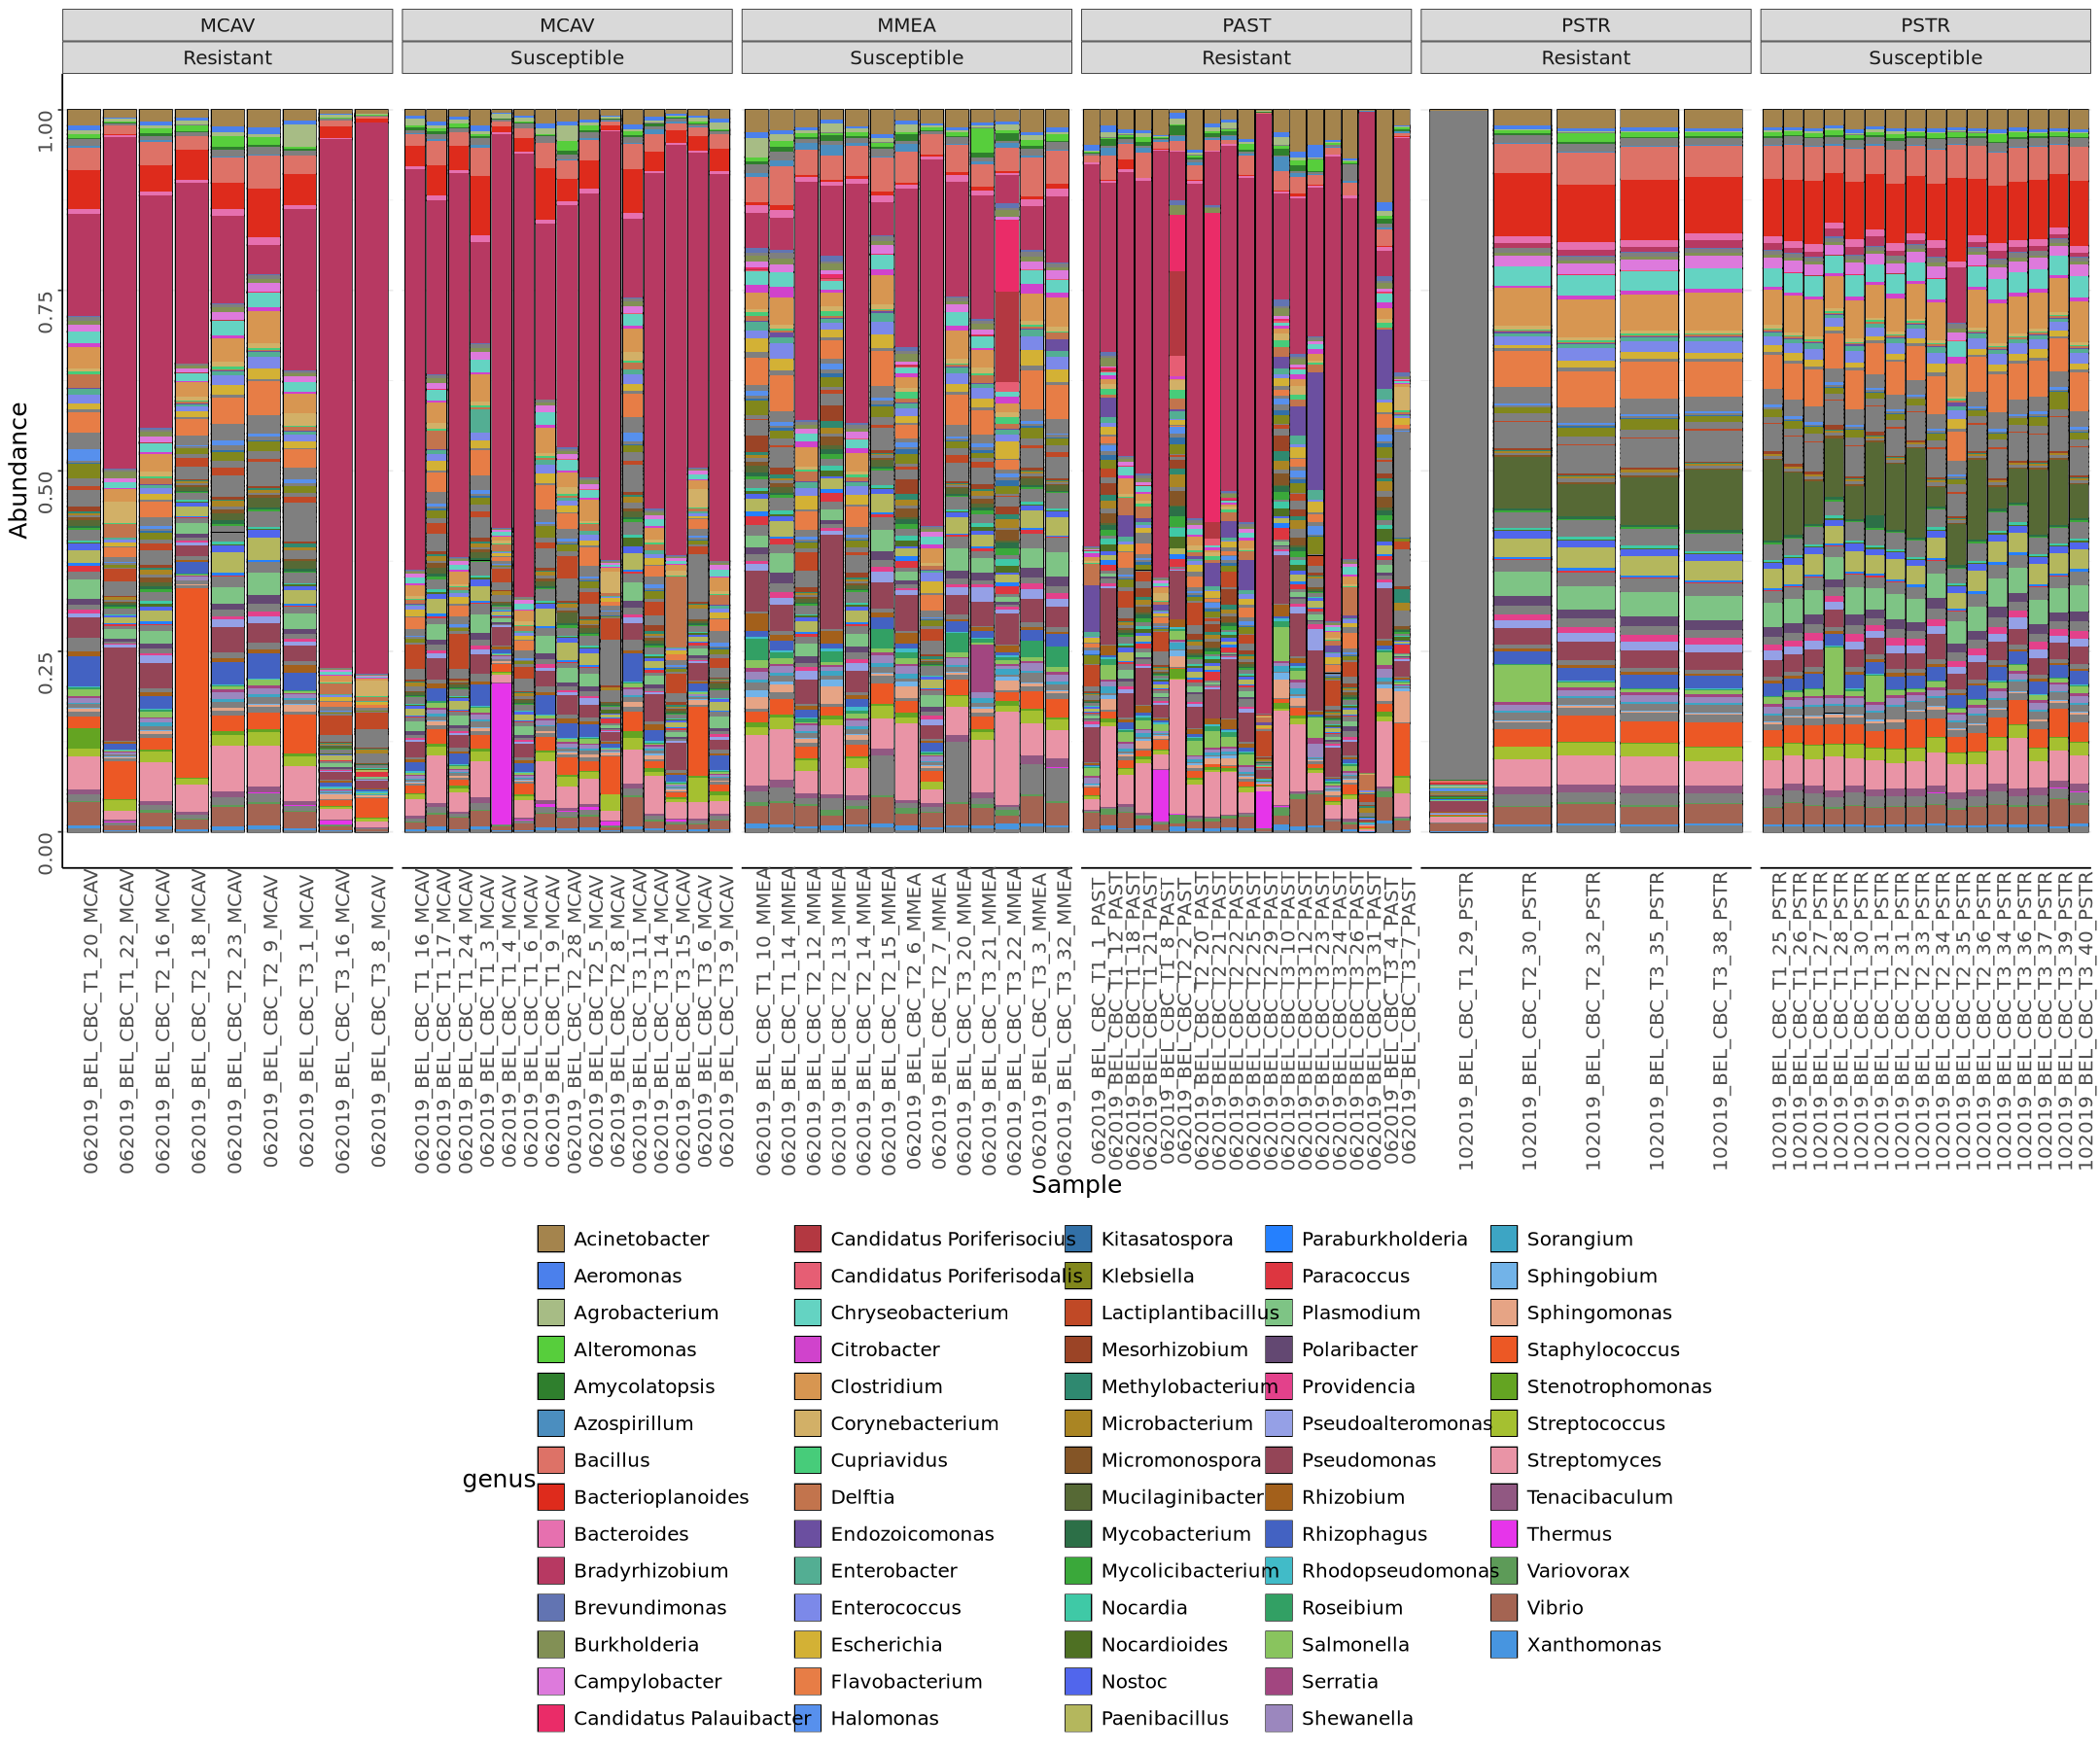

In [210]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='genus')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# 2019: Top 100 OTUs (genus)

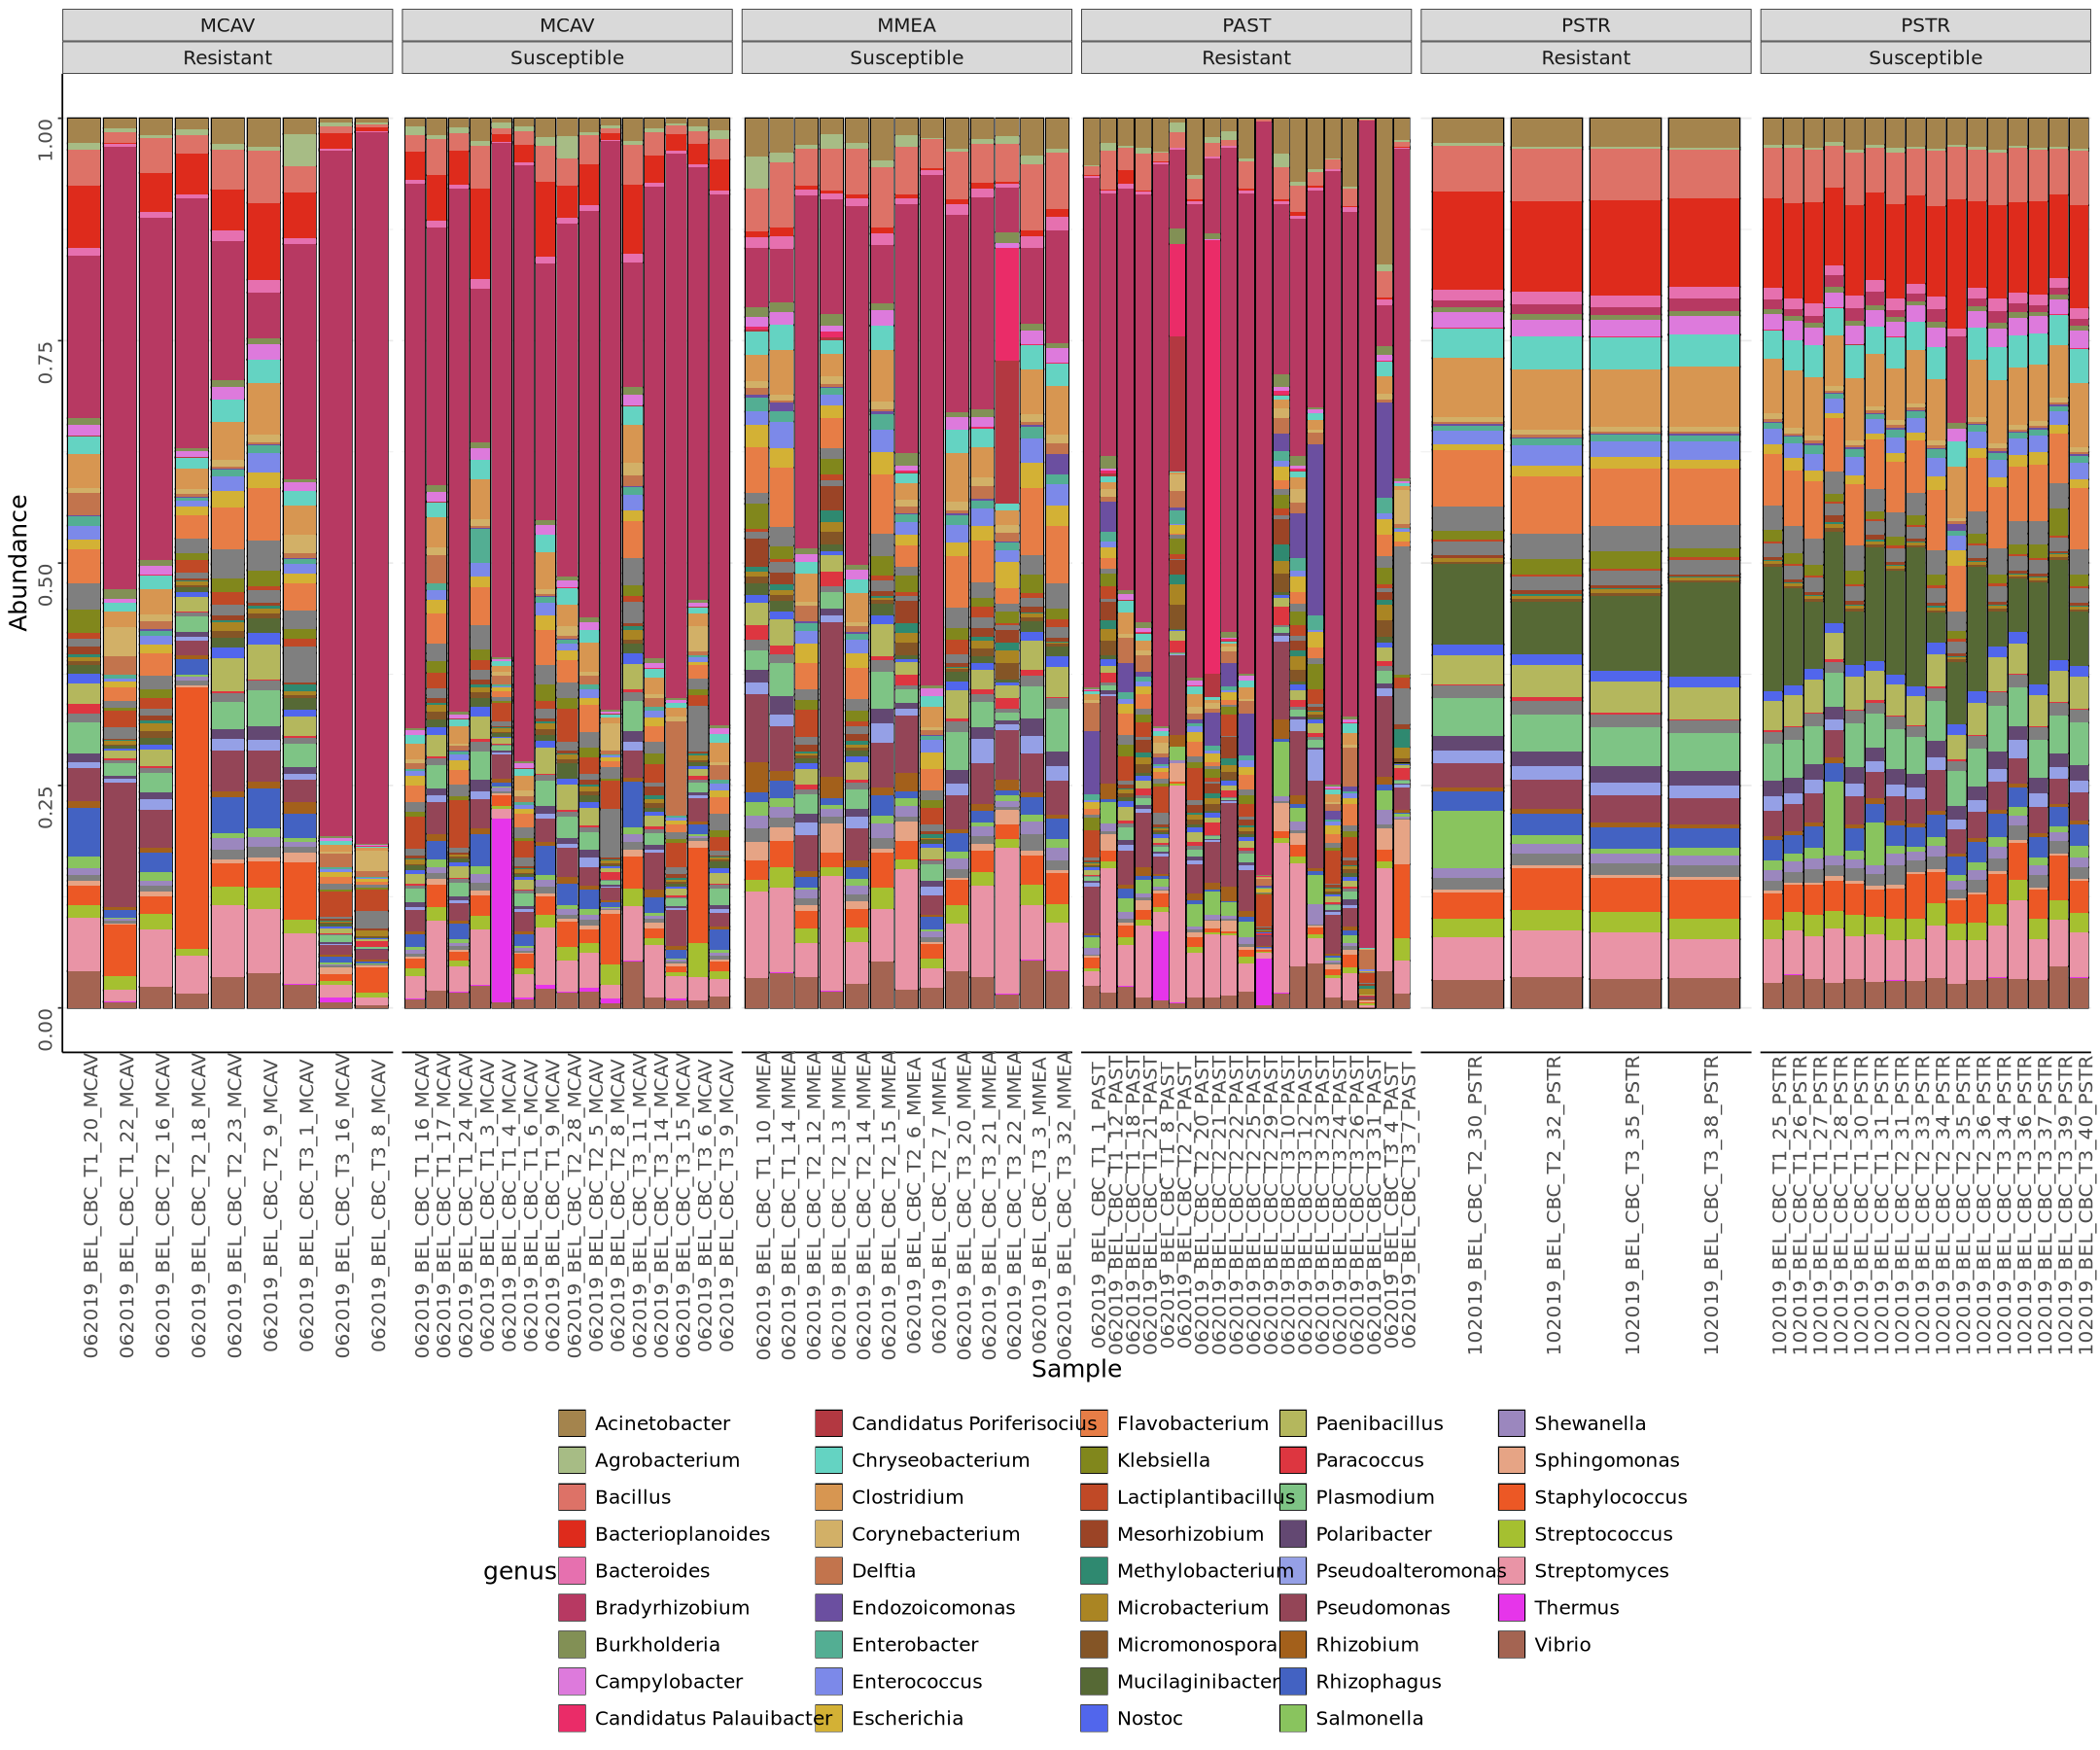

In [219]:
plot_bar(sctld_50_2019_norm,x = "Sample",fill='genus')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 50 genera 2019 only 

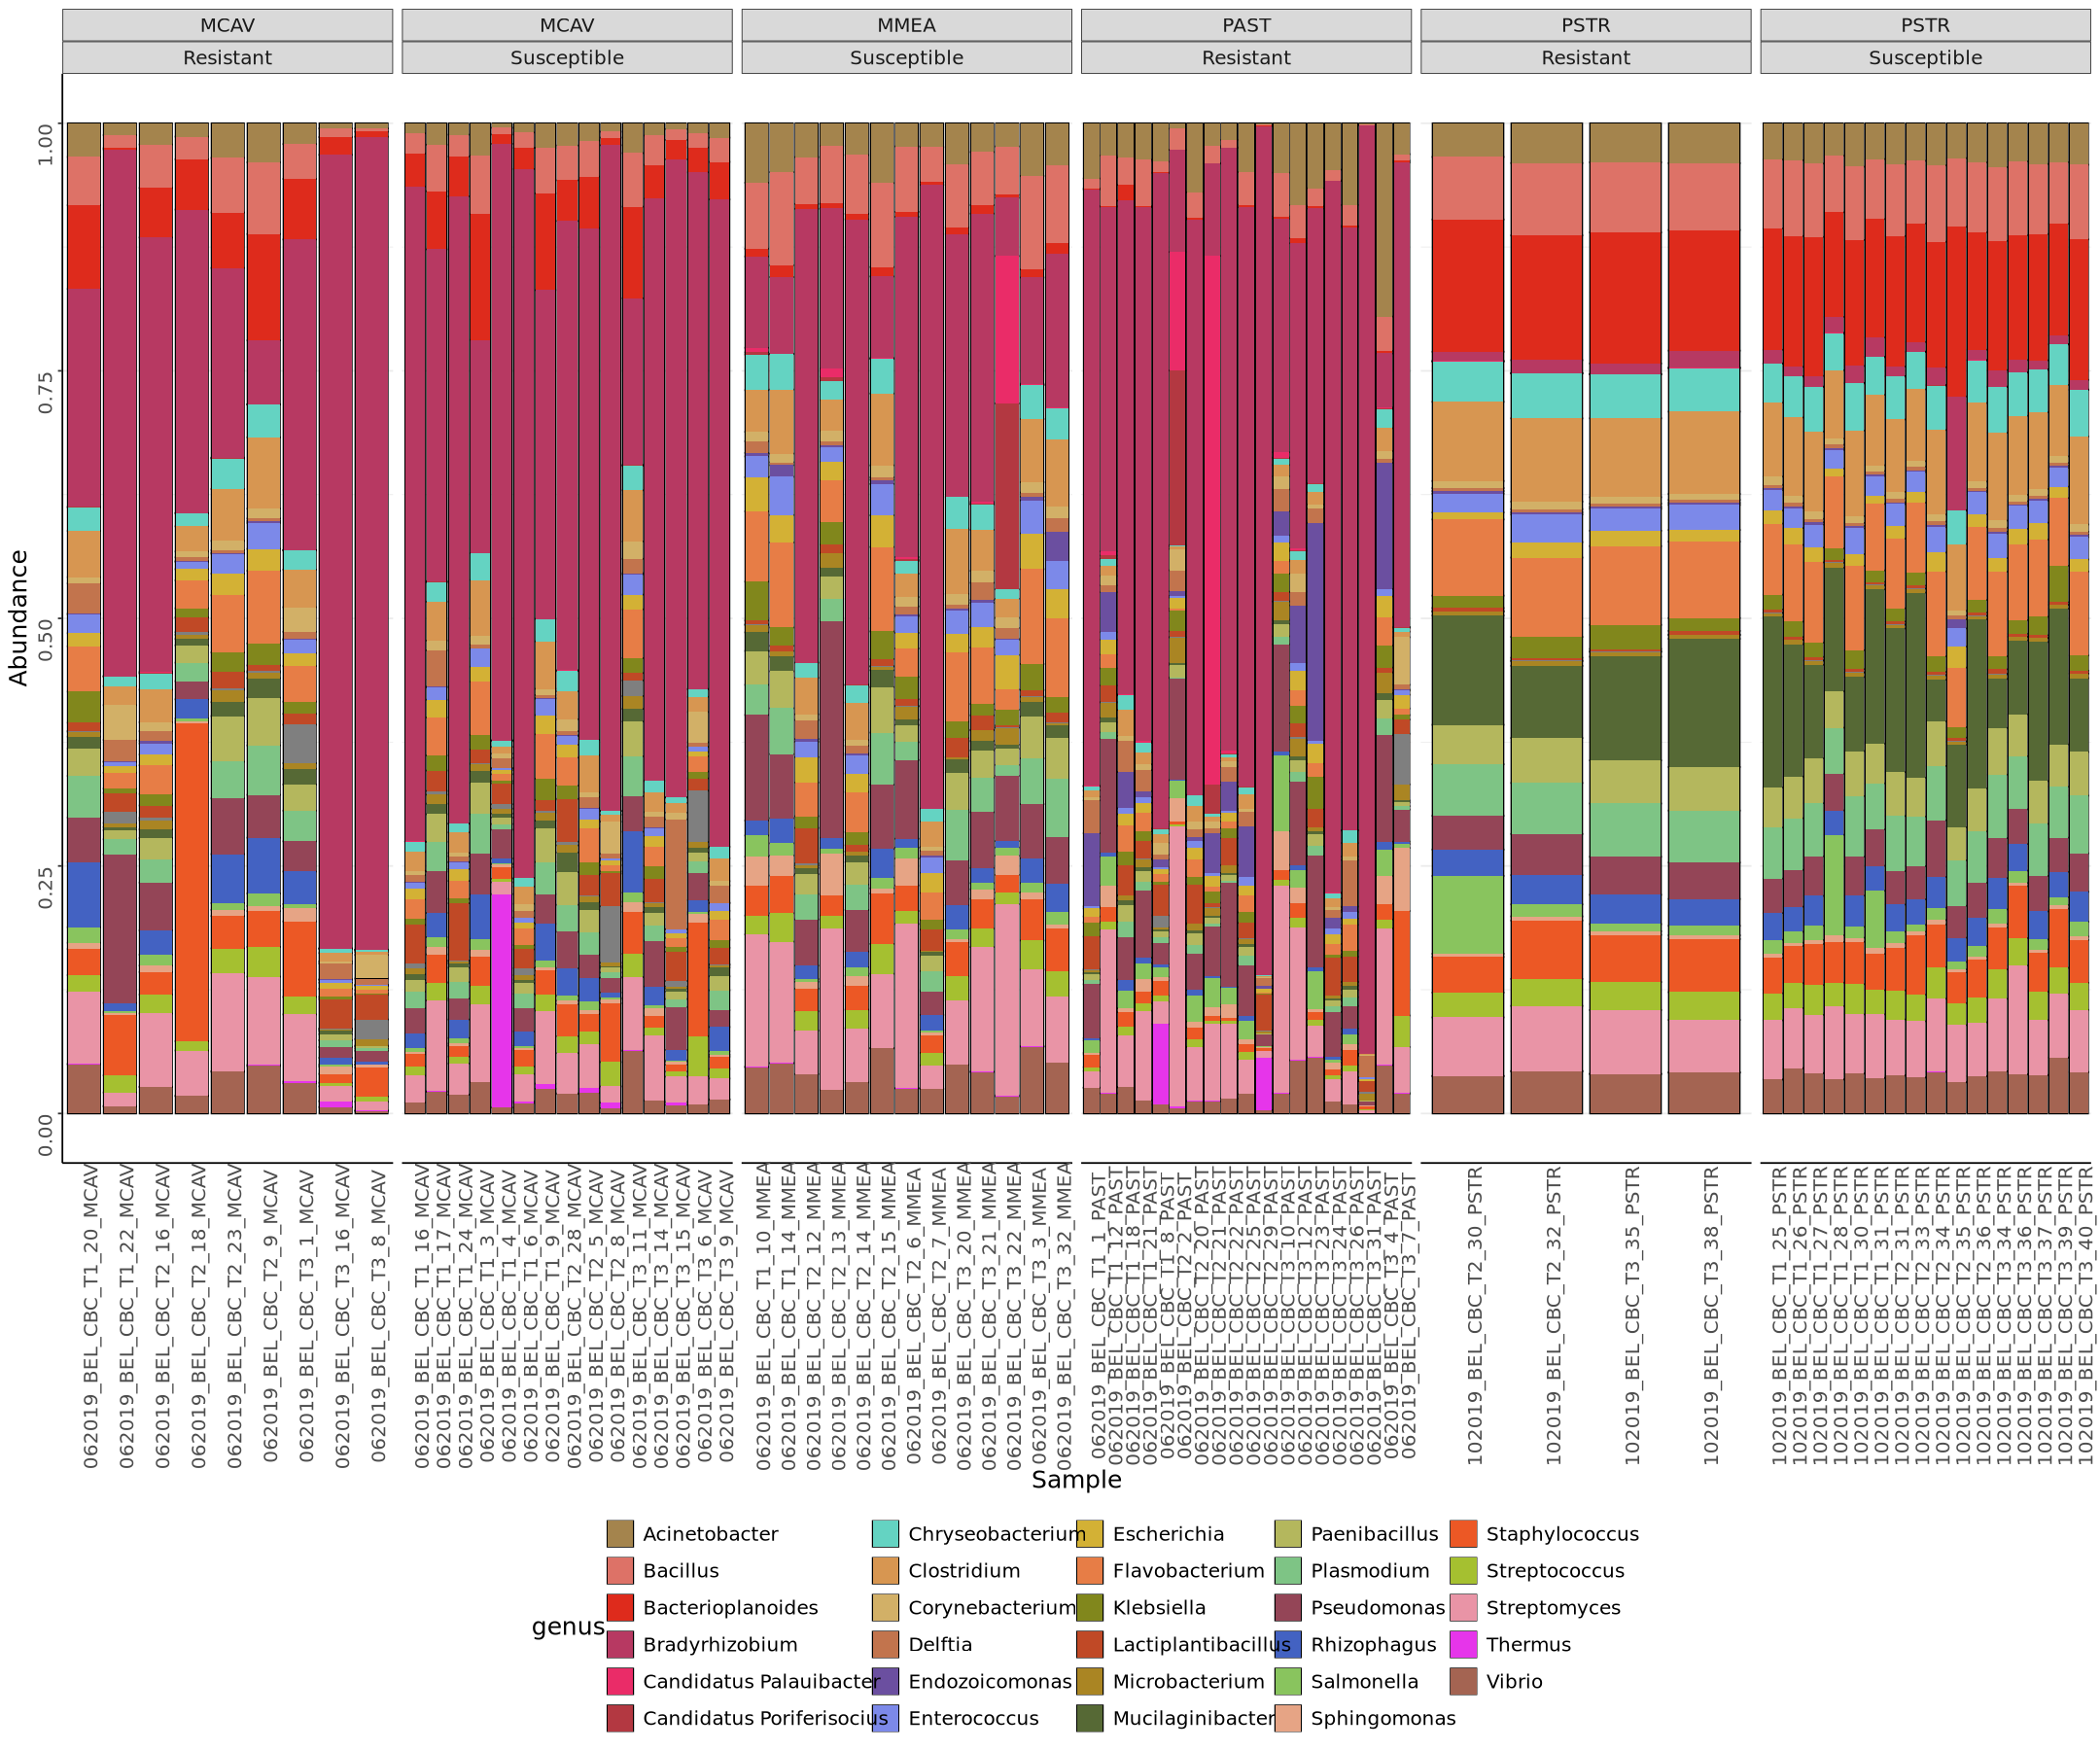

In [221]:
plot_bar(sctld_30_2019_norm,x = "Sample",fill='genus')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 30 genera 2019 only 

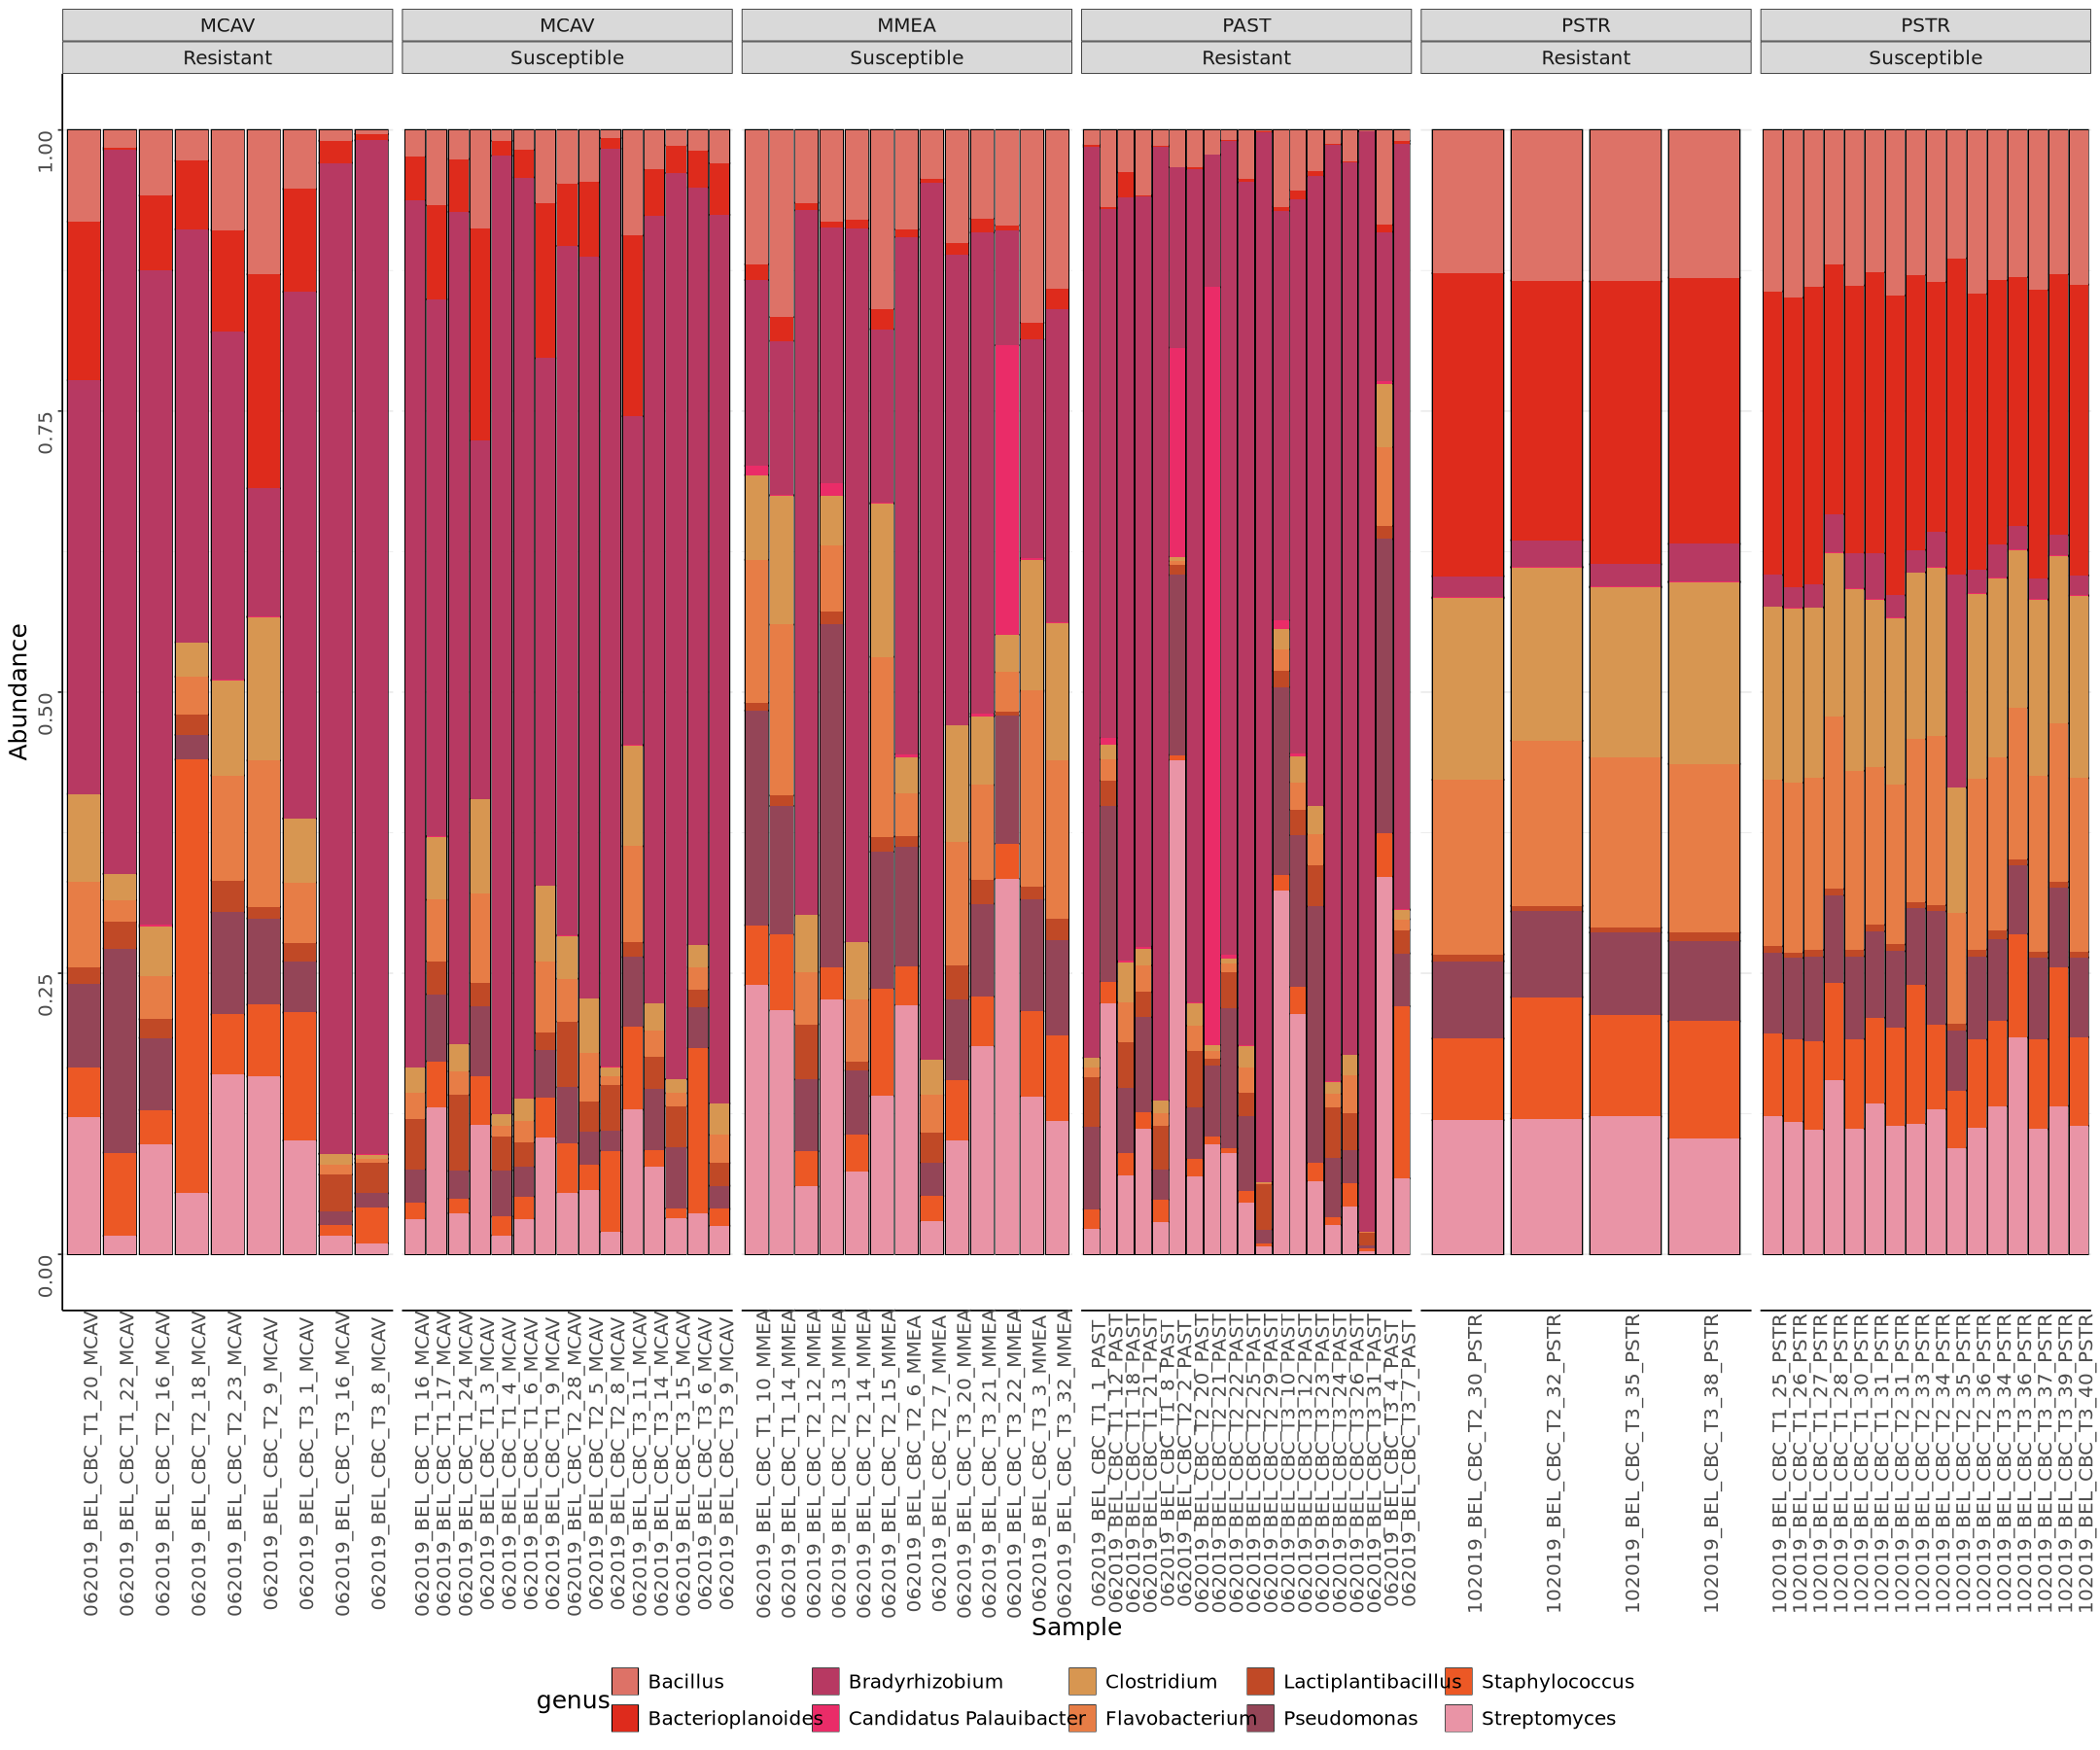

In [222]:
plot_bar(sctld_10_2019_norm,x = "Sample",fill='genus')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 10 genera 2019 only 

In [158]:
# plot each spp individually...

#### MCAV --------------------------------------------------------------------------------

In [223]:
library(ggh4x)


Attaching package: ‘ggh4x’


The following object is masked from ‘package:cowplot’:

    save_plot




In [224]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [226]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(sctld_raw, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

# top 100 genus
mcav_100 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:100]), subset_mcav)
mcav_100_norm <- transform_sample_counts(mcav_100, function(x) x / sum(x))

# top 50 genus
mcav_50 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:50]), subset_mcav)
mcav_50_norm <- transform_sample_counts(mcav_50, function(x) x / sum(x))

# top 30 genus
mcav_30 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:30]), subset_mcav)
mcav_30_norm <- transform_sample_counts(mcav_30, function(x) x / sum(x))

# top 10 genus
mcav_10 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:10]), subset_mcav)
mcav_10_norm <- transform_sample_counts(mcav_10, function(x) x / sum(x))

In [227]:
df_meta <- data.frame(sample_data(subset_mcav))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_mcav) <- sample_data(df_meta)

In [228]:
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




In [230]:
# reorder colonies
mcav_g_S<-subset_samples(subset_mcav, RS == "Susceptible")
df_meta<-data.frame(sample_data(mcav_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(mcav_g_S)$colony_id <-
  factor(sample_data(mcav_g_S)$colony_id, levels = col_order)

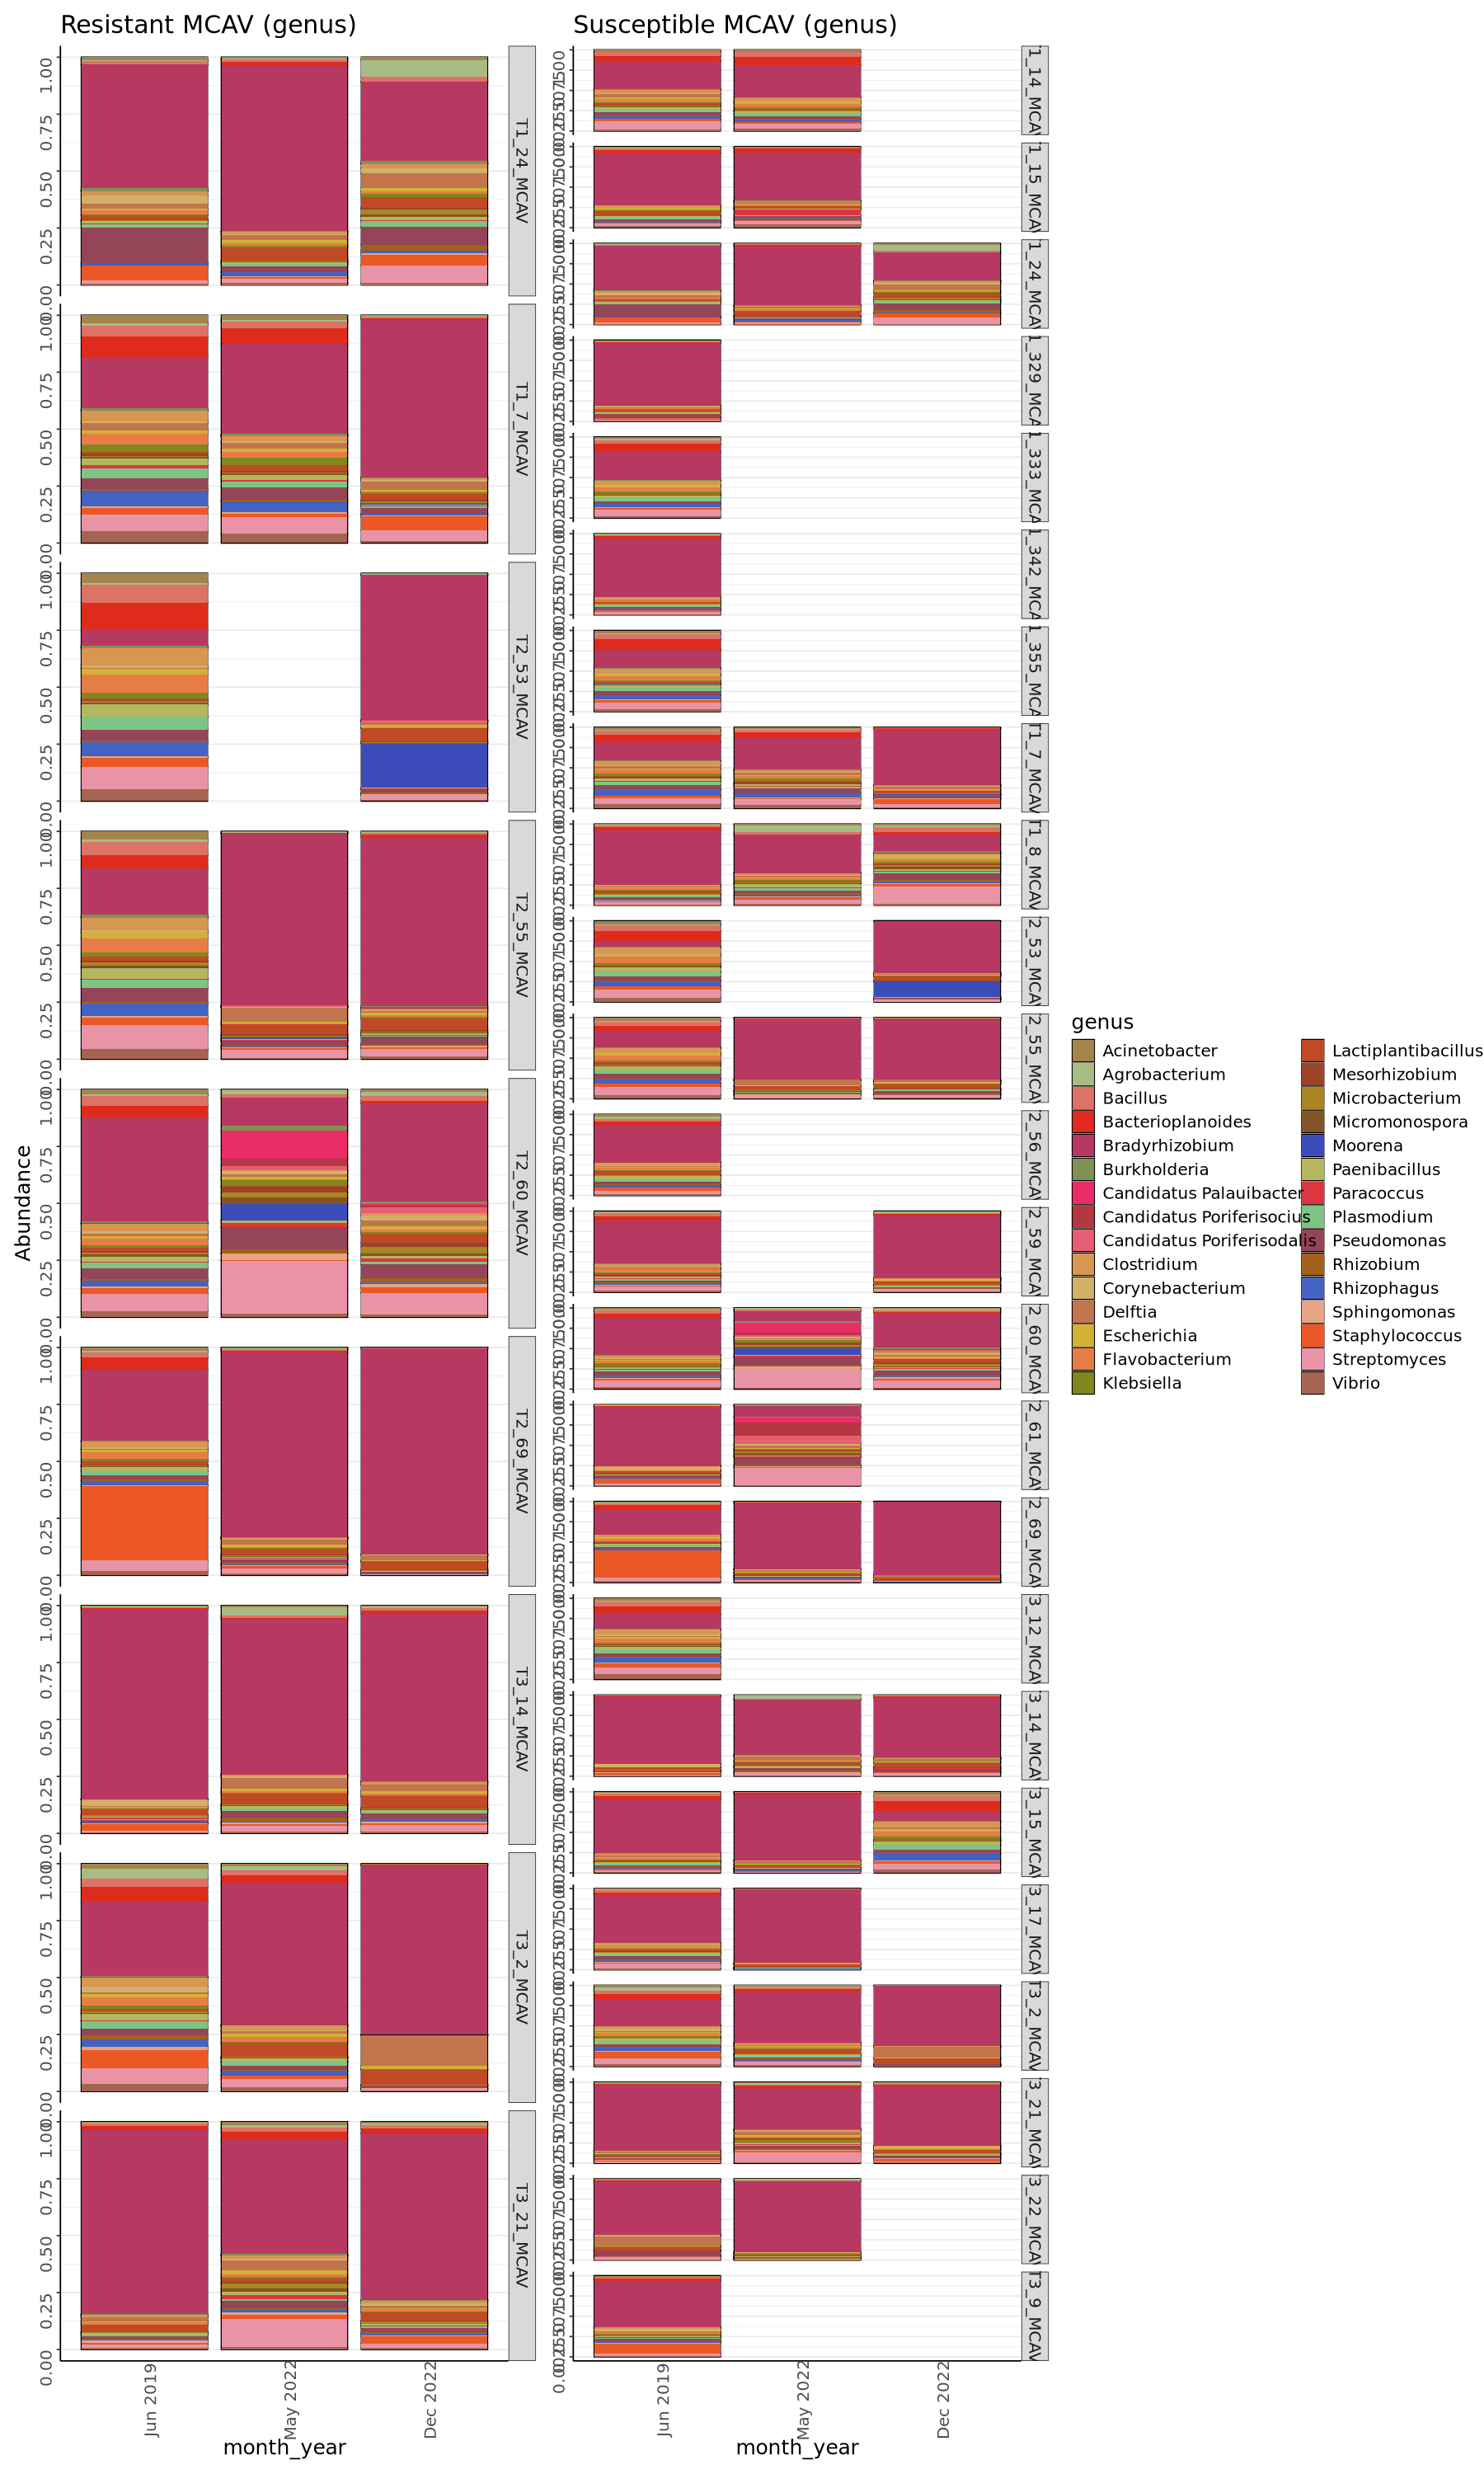

In [231]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(mcav_30_norm, RS == "Resistant"),x = "month_year", fill = "genus")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant MCAV (genus)")

p_S <- plot_bar(mcav_30_norm,x = "month_year", fill = "genus") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible MCAV (genus)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "MCAV colonies") &
  theme(legend.position = "right")

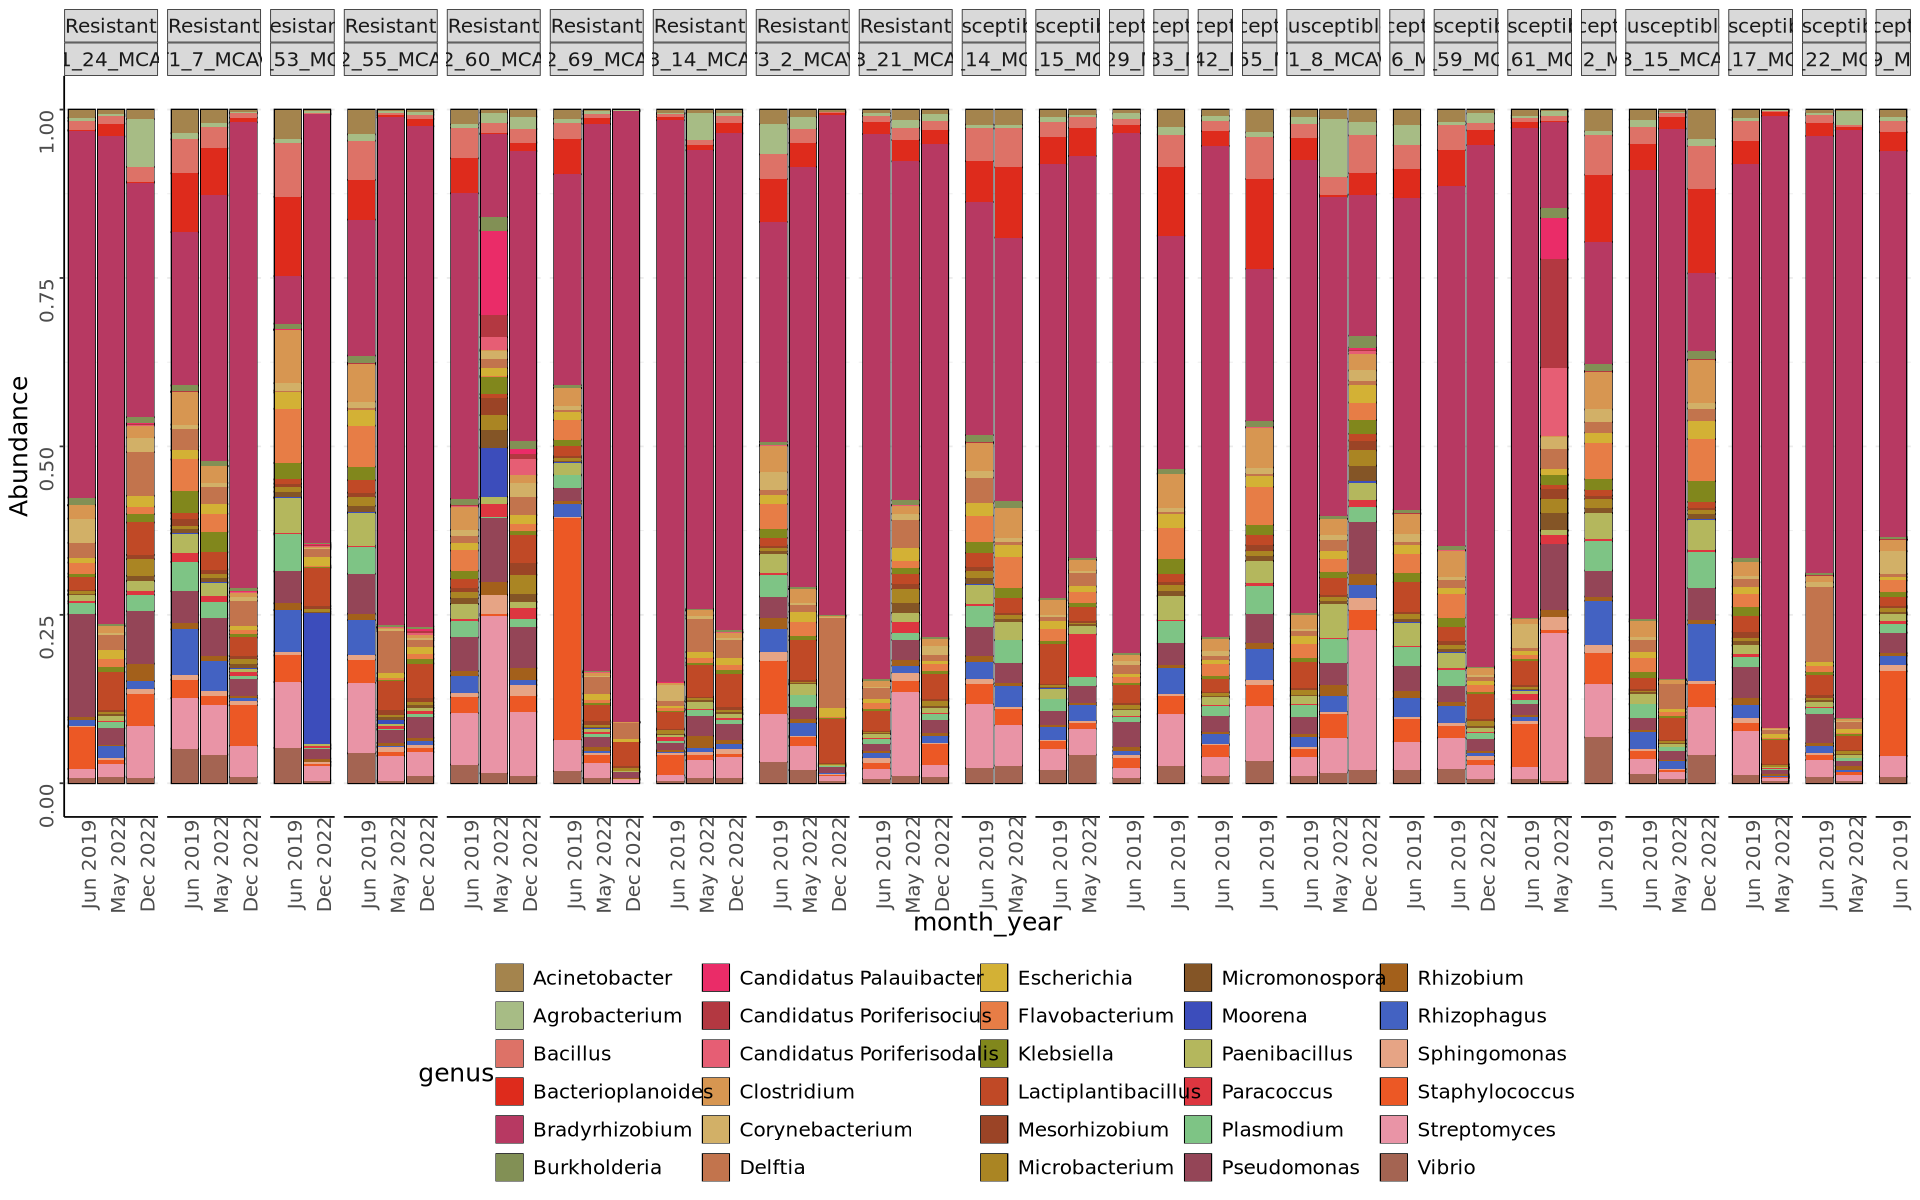

In [232]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_30_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

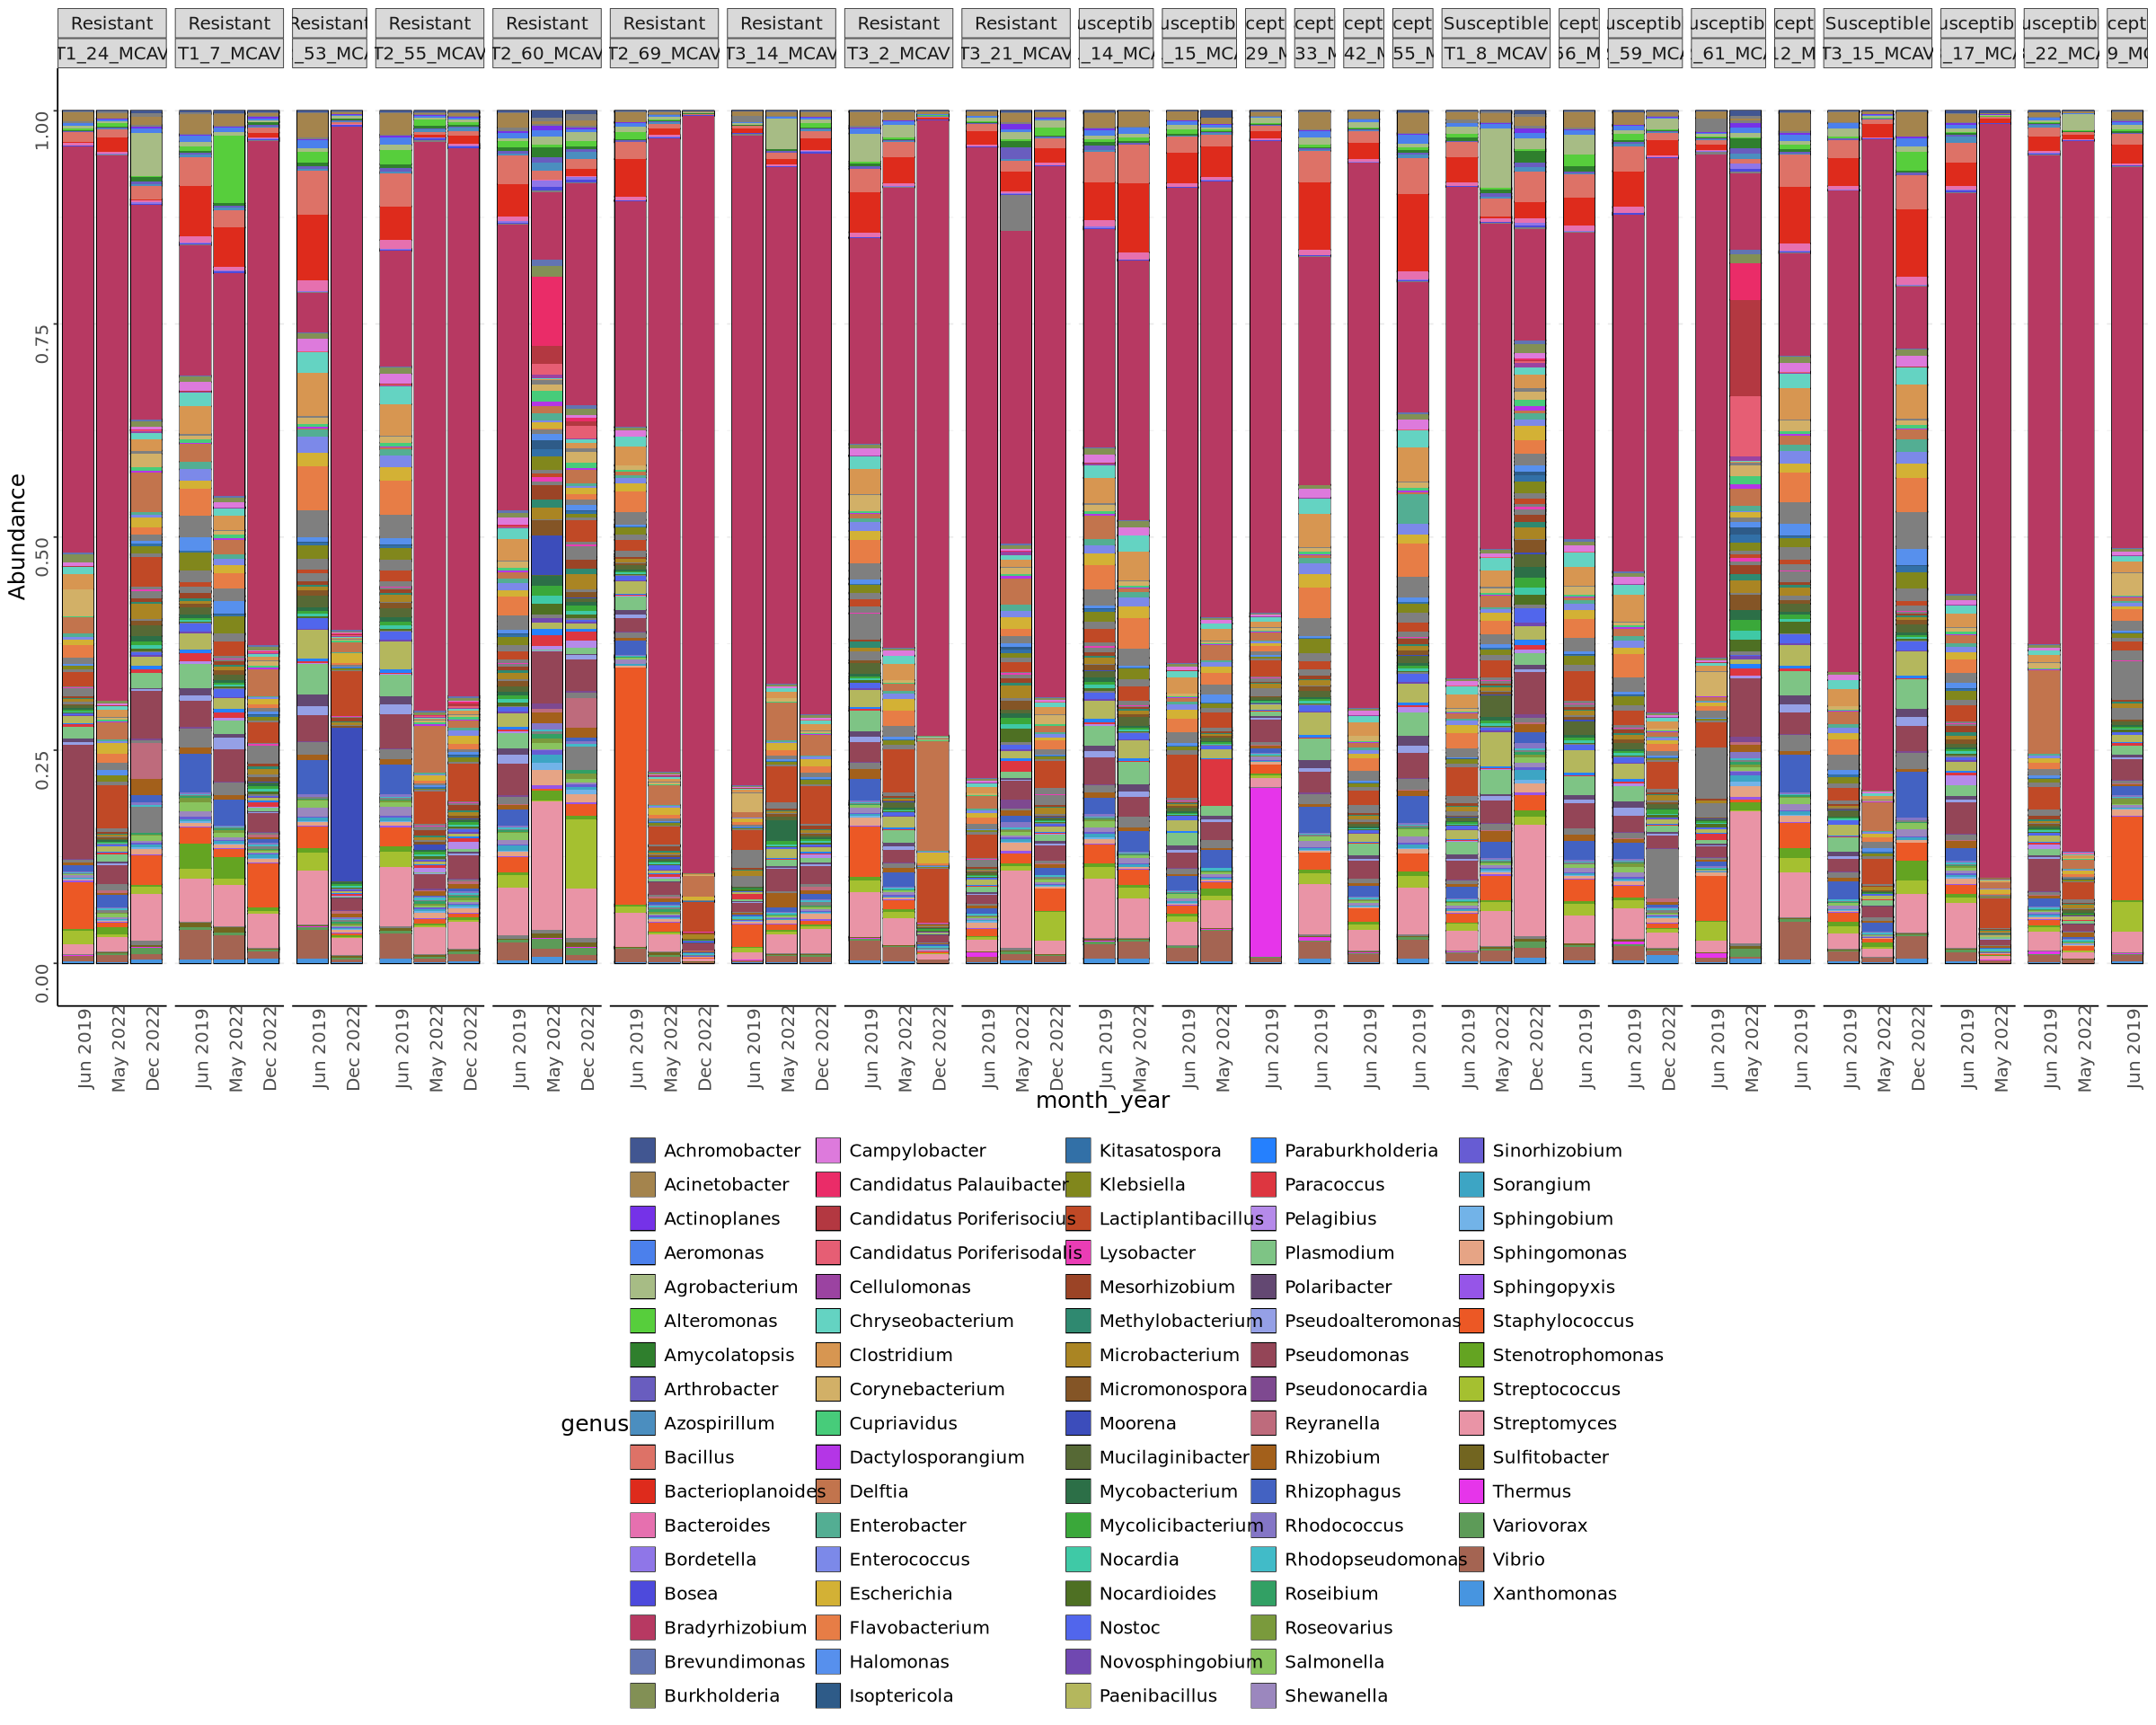

In [237]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (genus)

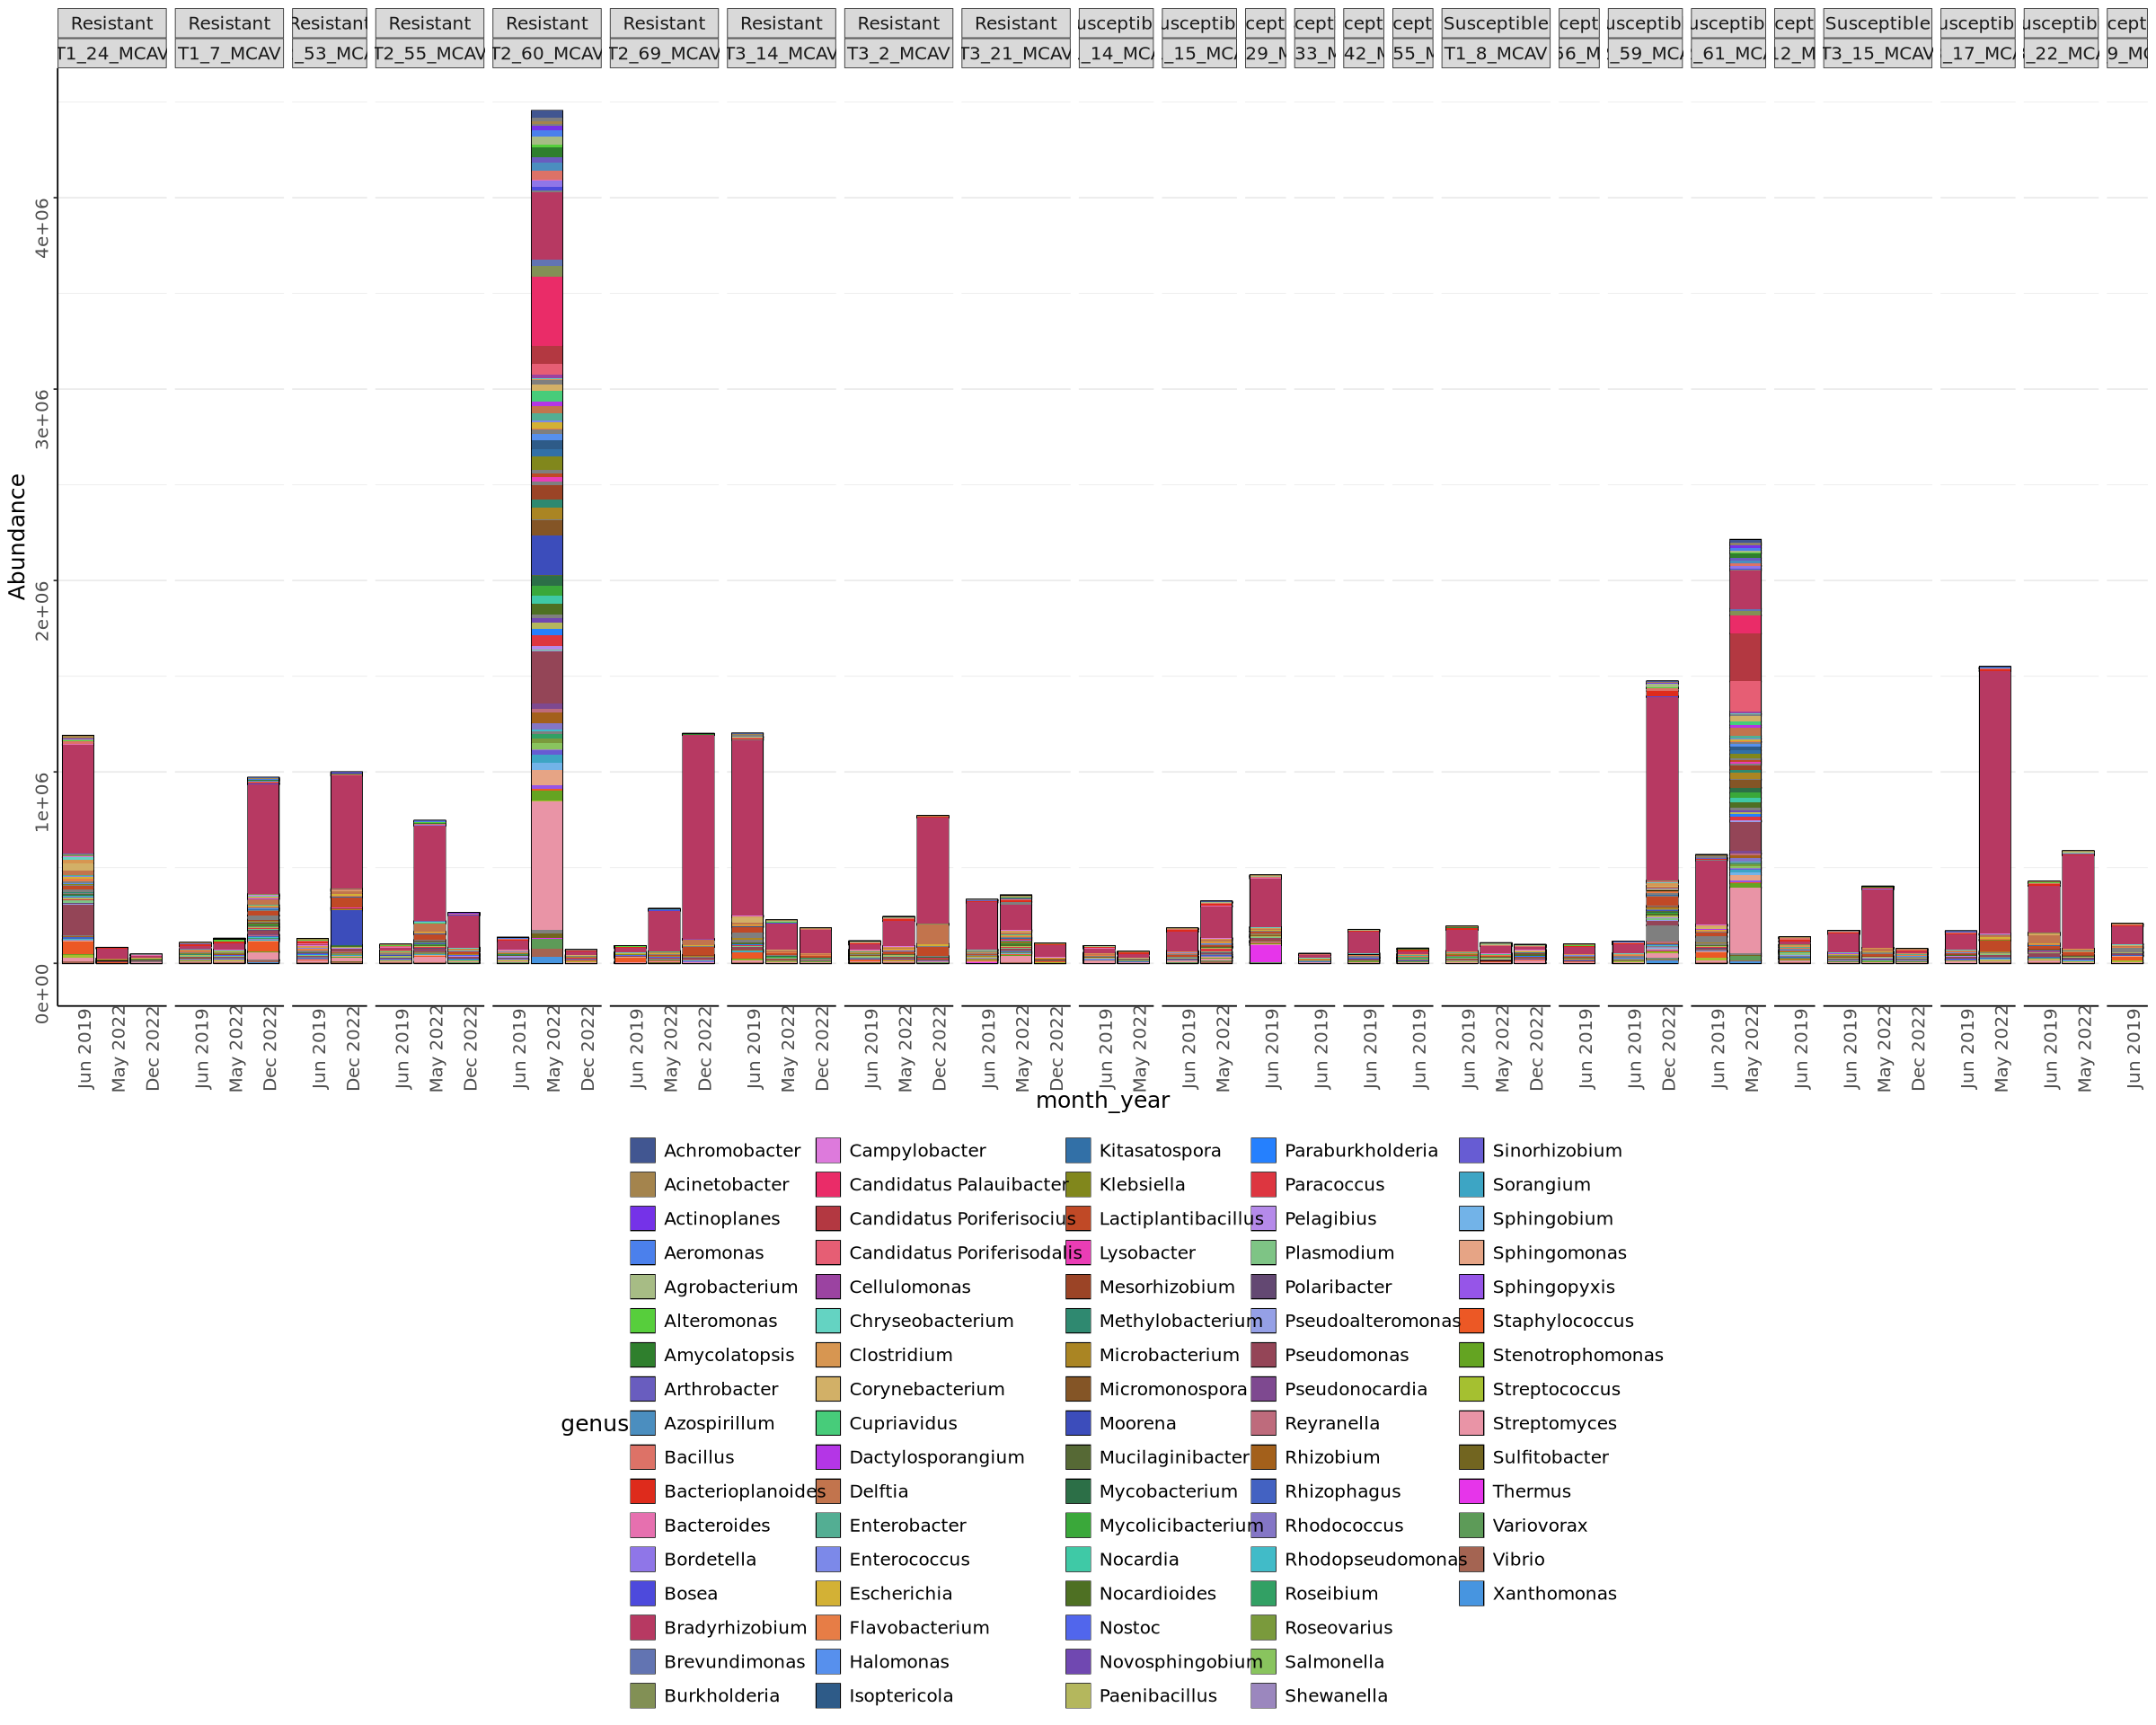

In [243]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 100 genus

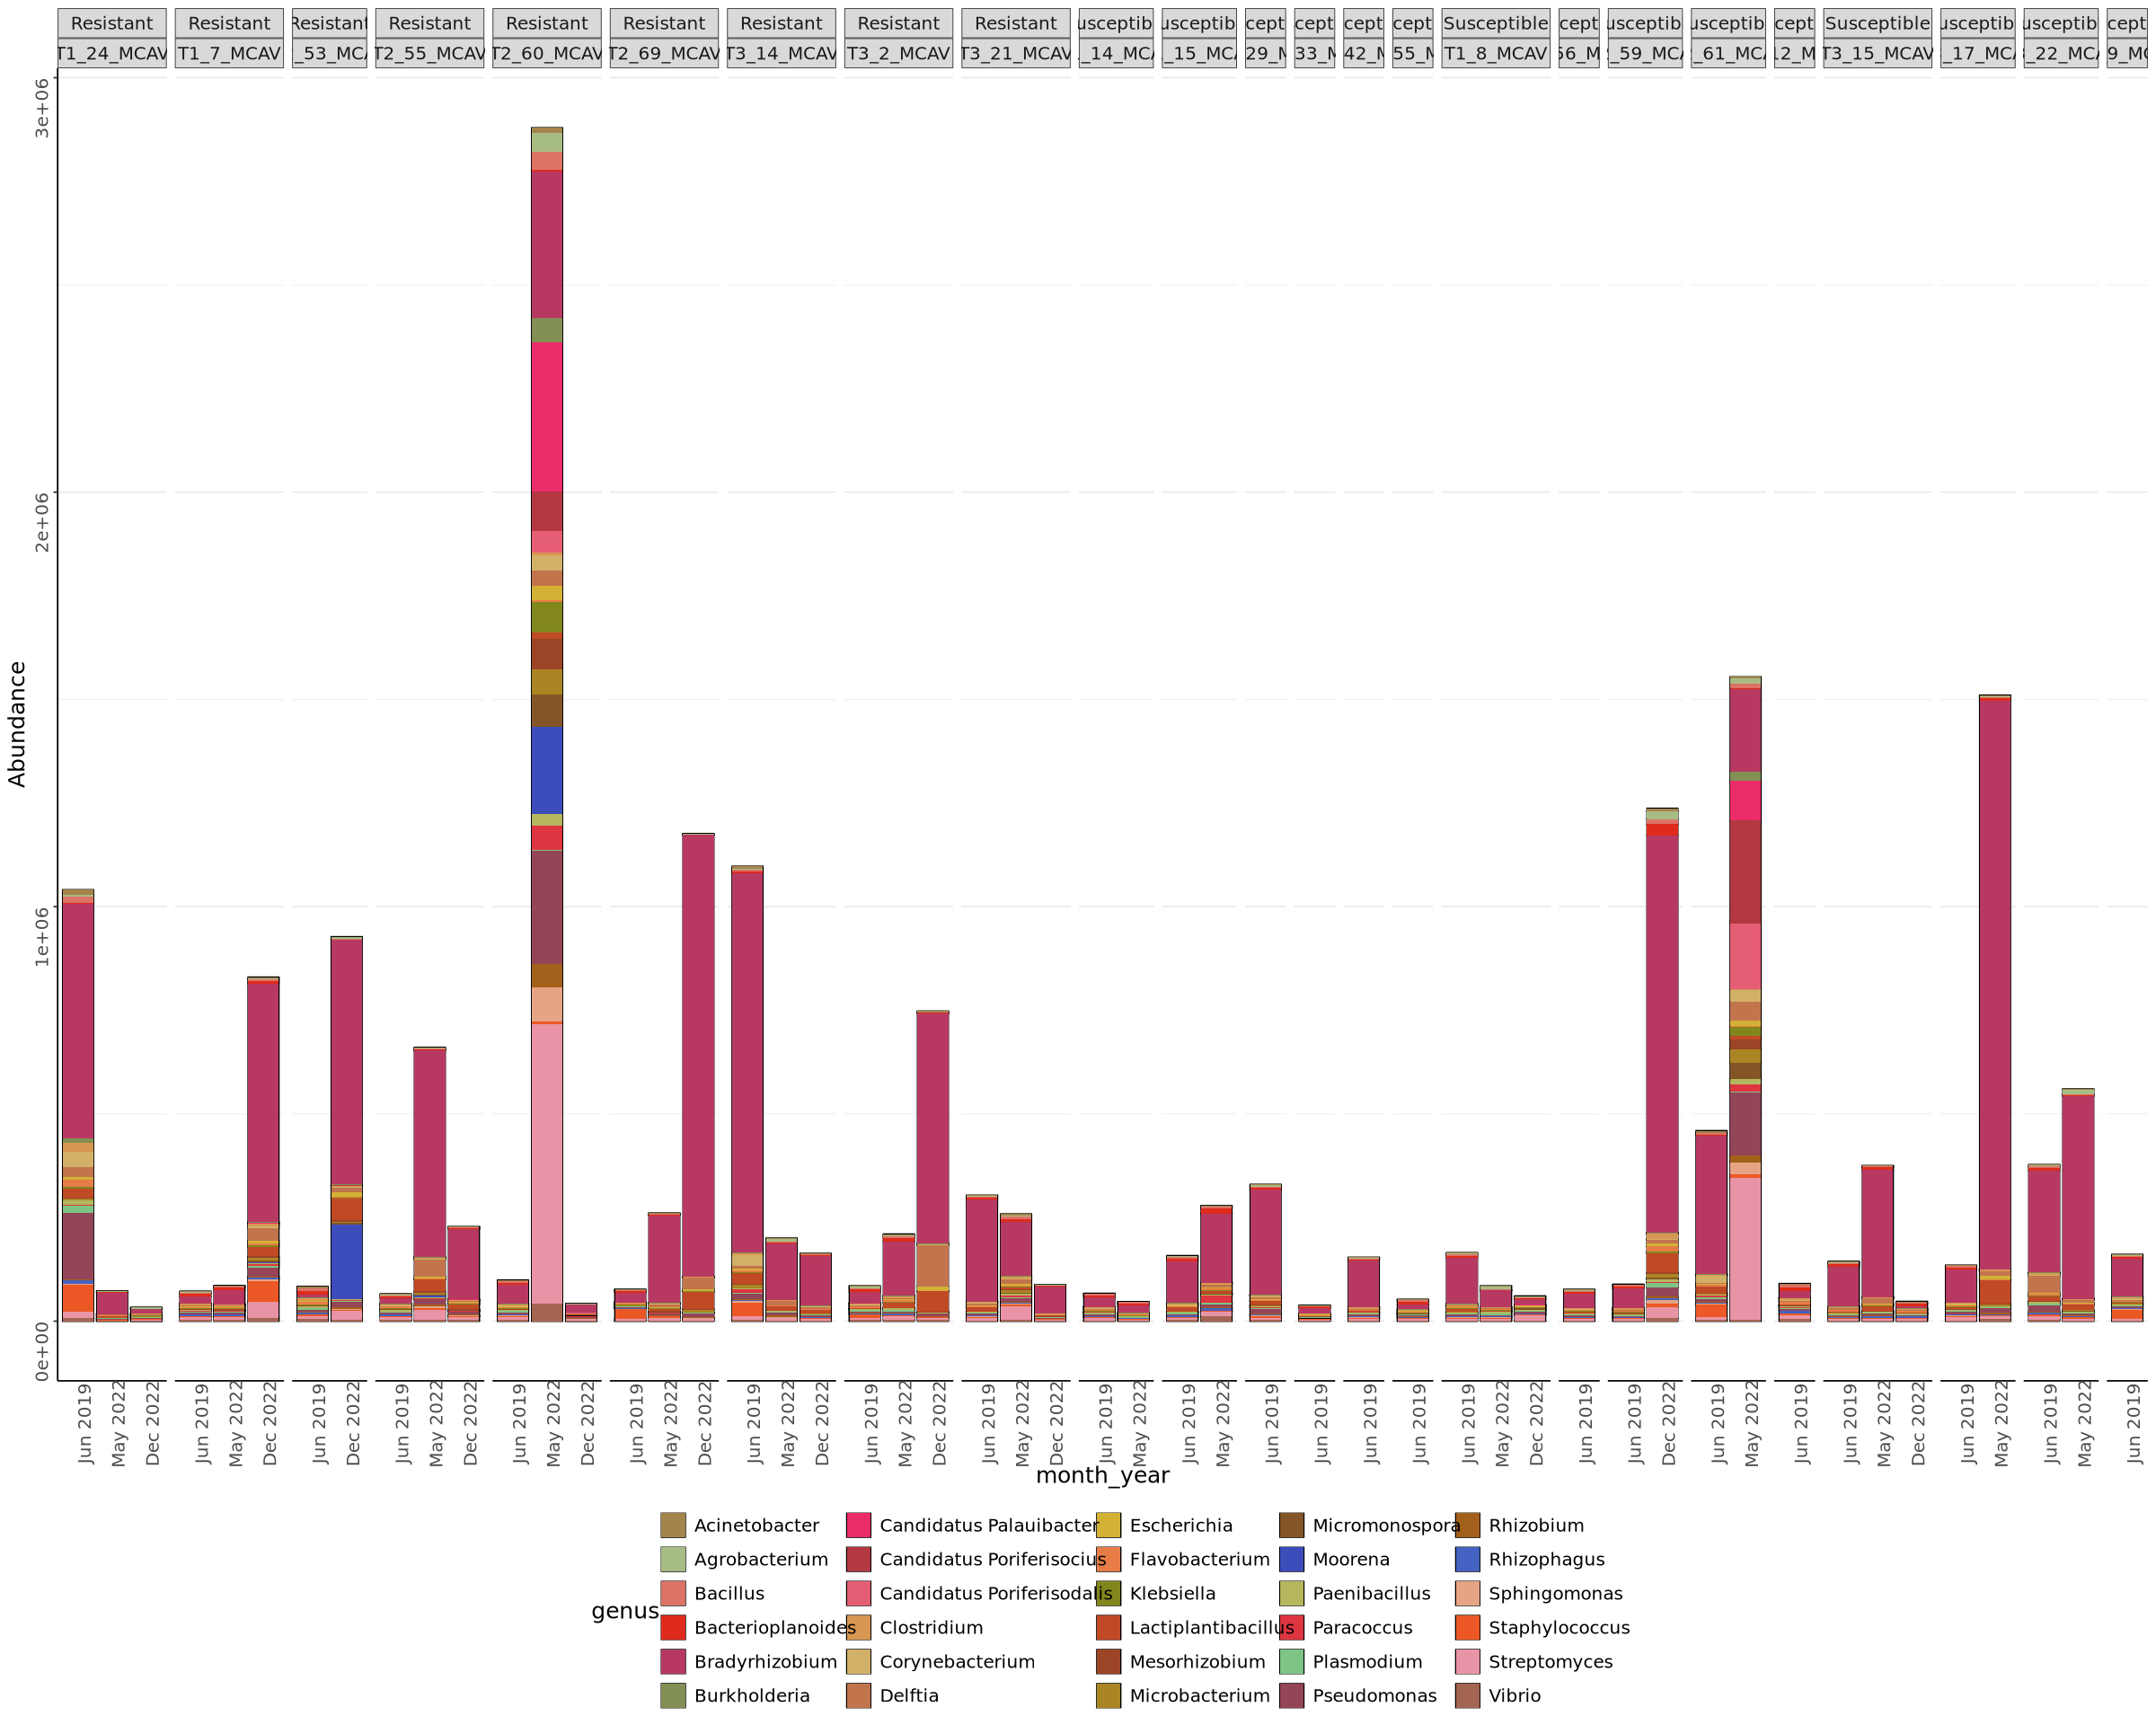

In [261]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_30,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 30 genus

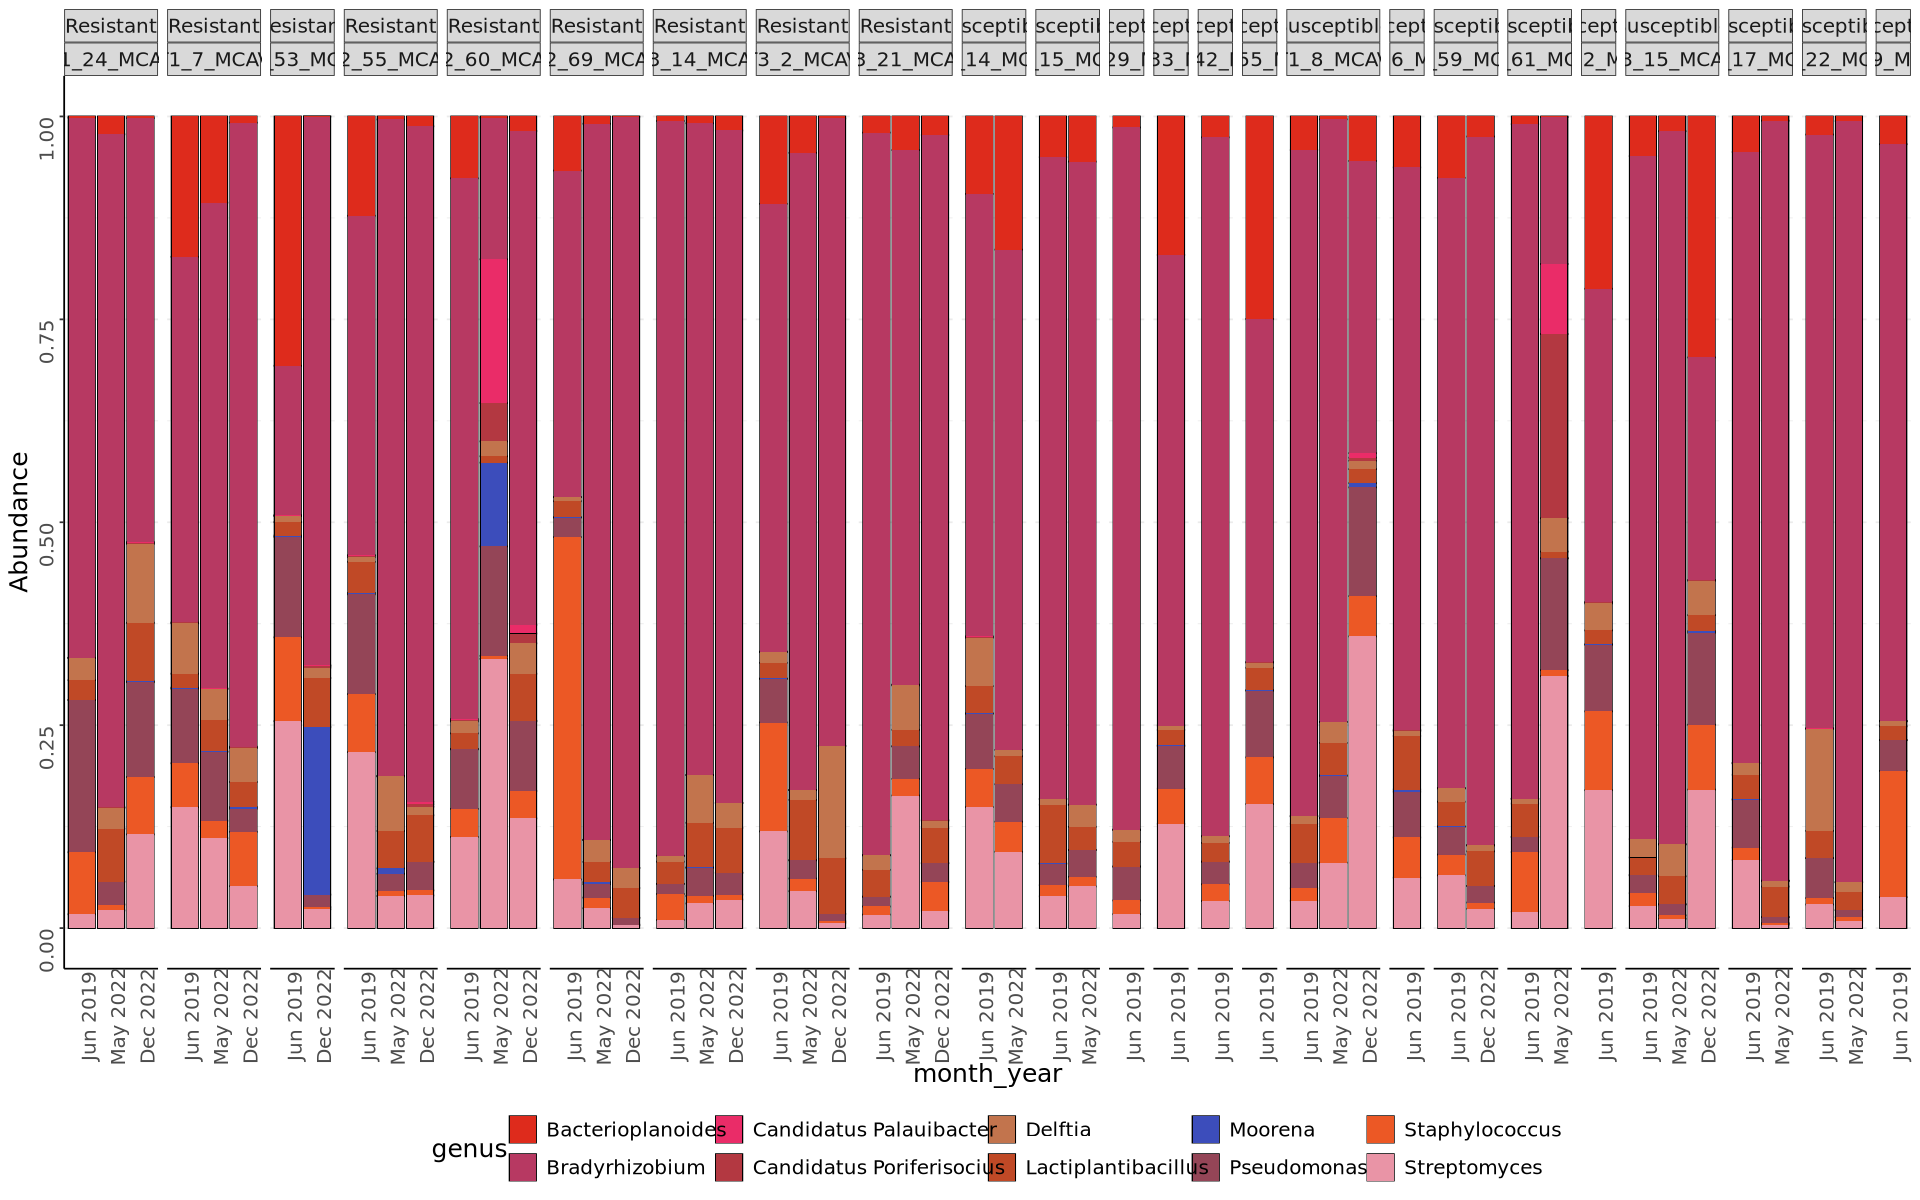

In [246]:
# top 10 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_10_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (genus)

In [170]:
# repeat other spp 

#### PSTR --------------------------------------------------------------------------------

In [171]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [248]:
# looking just at PSTR, remove disease margin

subset_PSTR<- subset_samples(sctld_raw, (Species == "PSTR" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PSTR<- subset_samples(subset_PSTR, (!(Date_InitialTag %in% dec_tags)))

# top 100 genus
PSTR_100 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:100]), subset_PSTR)
PSTR_100_norm <- transform_sample_counts(PSTR_100, function(x) x / sum(x))
# top 30 genus
PSTR_30 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:30]), subset_PSTR)
PSTR_30_norm <- transform_sample_counts(PSTR_30, function(x) x / sum(x))
# top 10 genus
PSTR_10 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:10]), subset_PSTR)
PSTR_10_norm <- transform_sample_counts(PSTR_10, function(x) x / sum(x))

In [249]:
df_meta <- data.frame(sample_data(subset_PSTR))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PSTR) <- sample_data(df_meta)

In [251]:
# reorder colonies
PSTR_g_S<-subset_samples(subset_PSTR, RS == "Susceptible")
df_meta<-data.frame(sample_data(PSTR_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(PSTR_g_S)$colony_id <-
  factor(sample_data(PSTR_g_S)$colony_id, levels = col_order)

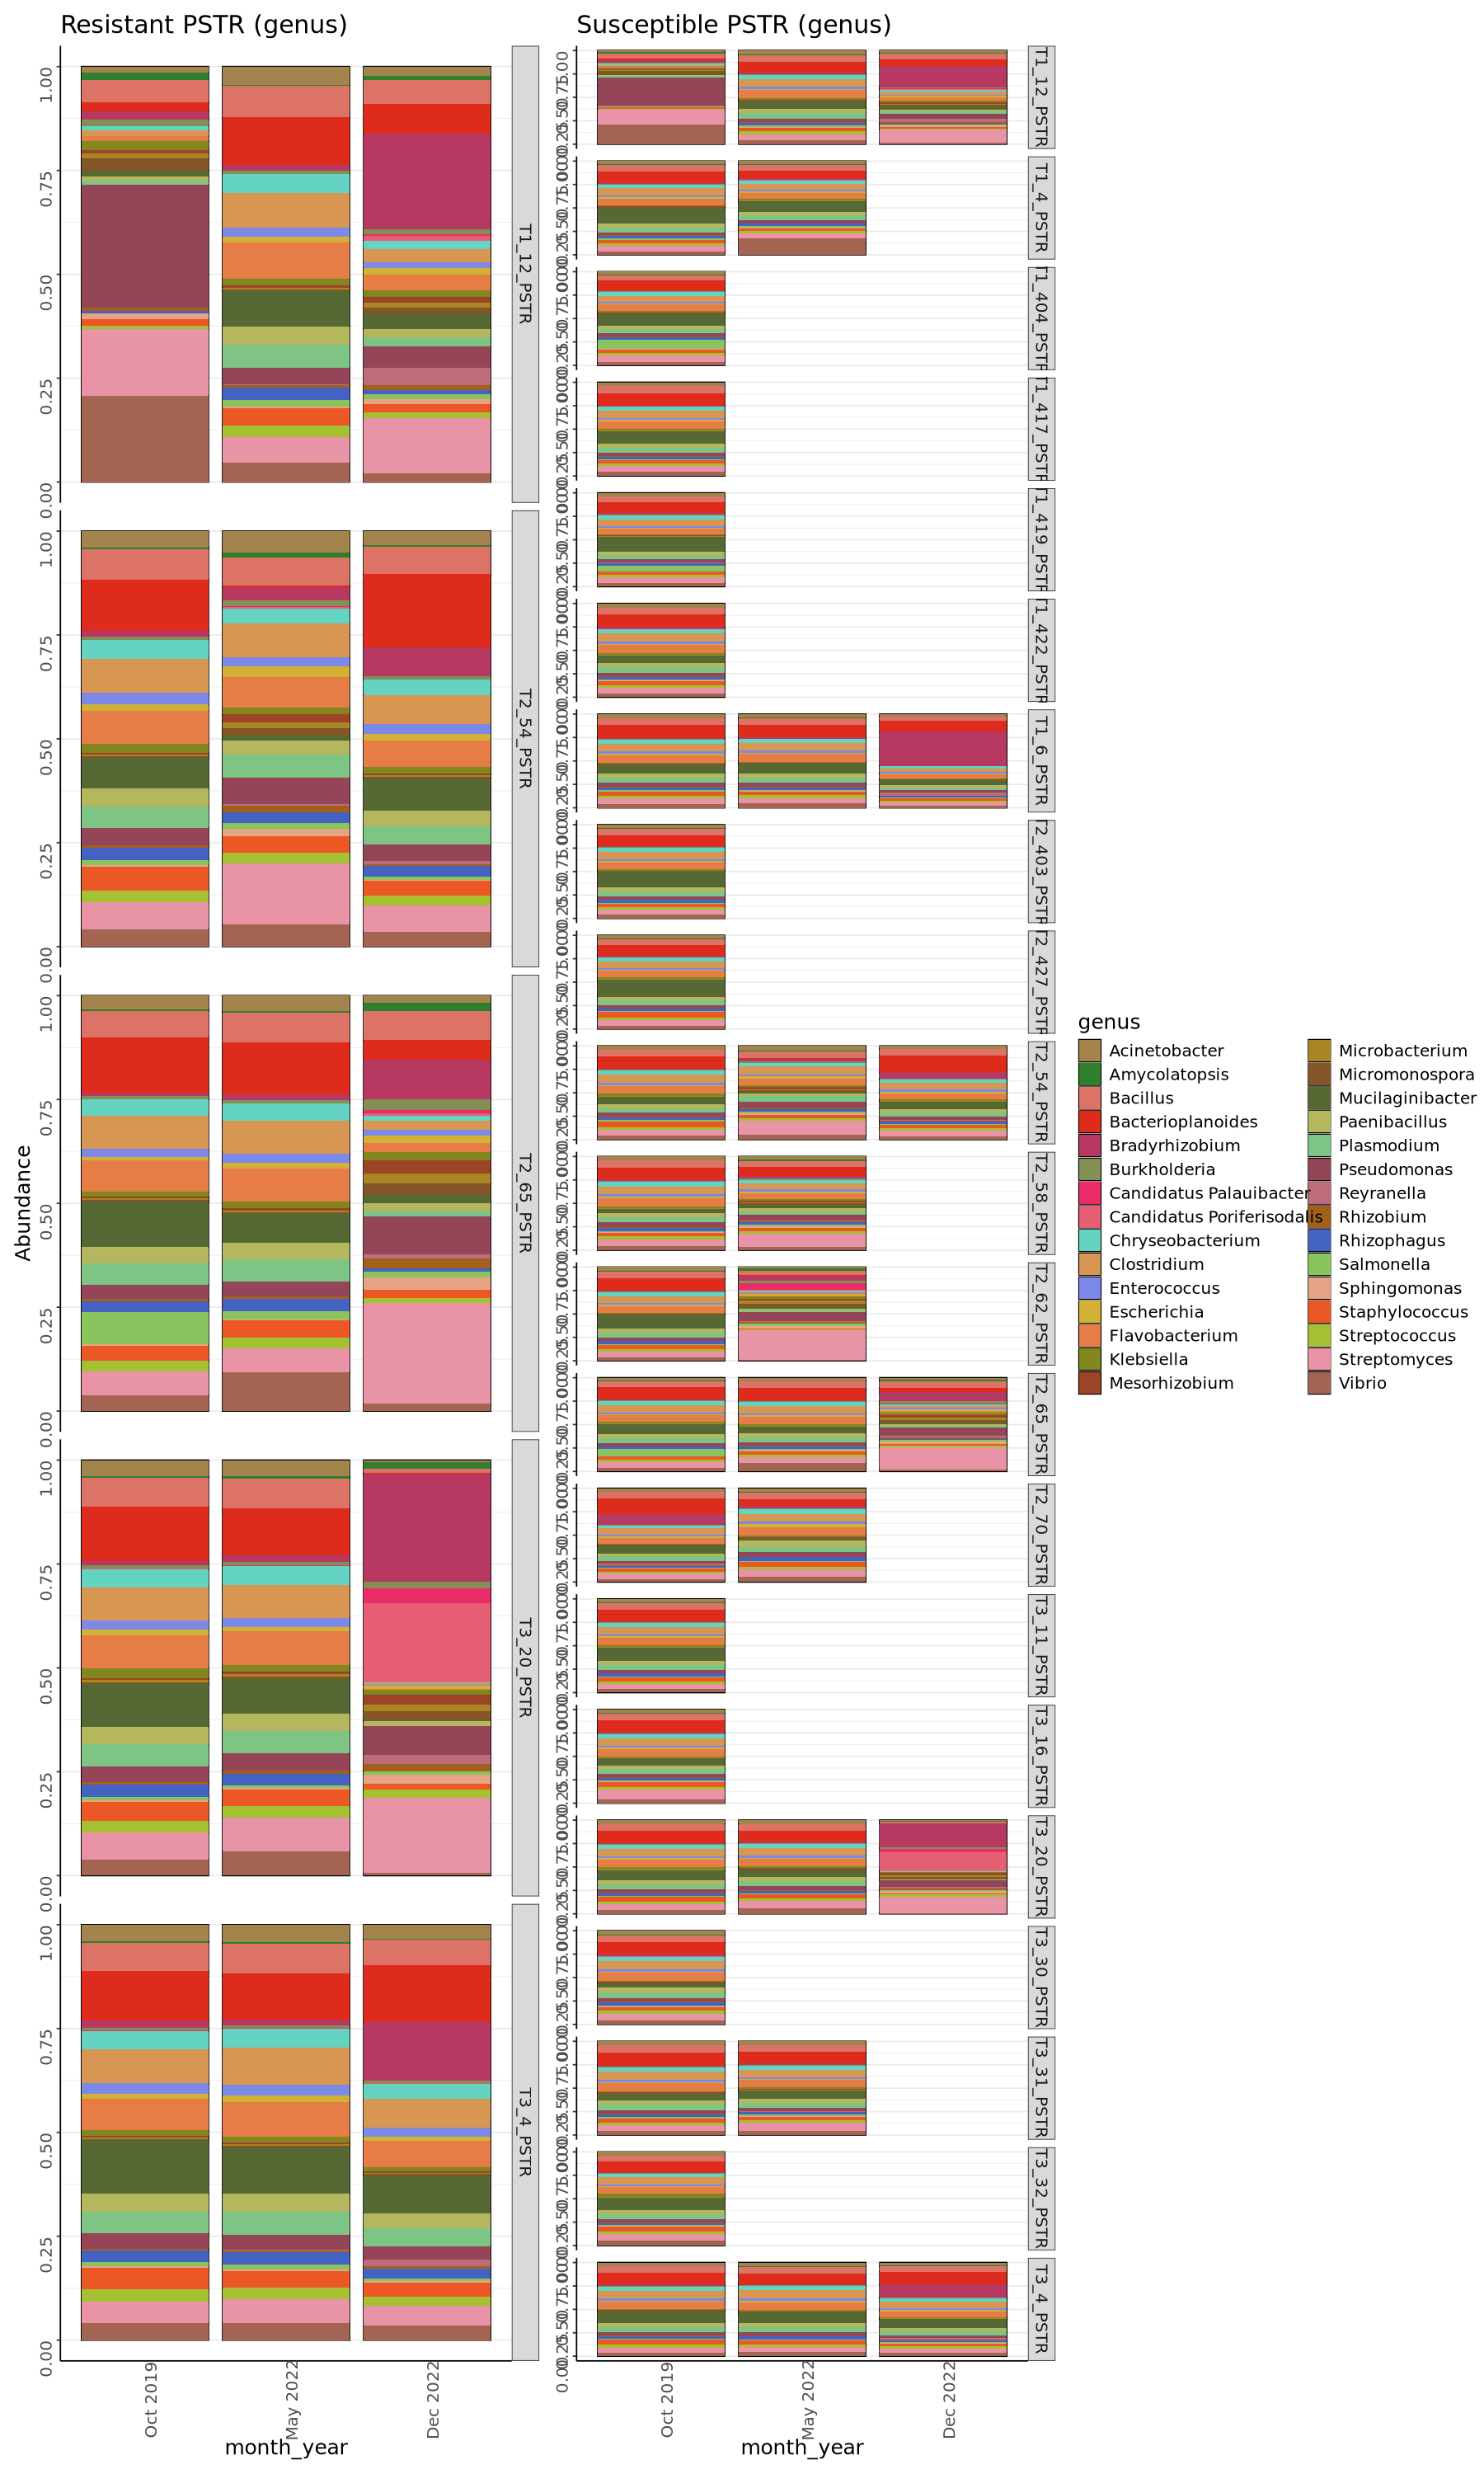

In [253]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(PSTR_30_norm, RS == "Resistant"),x = "month_year", fill = "genus")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant PSTR (genus)")
p_S <- plot_bar(PSTR_30_norm,x = "month_year", fill = "genus") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible PSTR (genus)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "PSTR colonies") &
  theme(legend.position = "right")
# top 30 genus

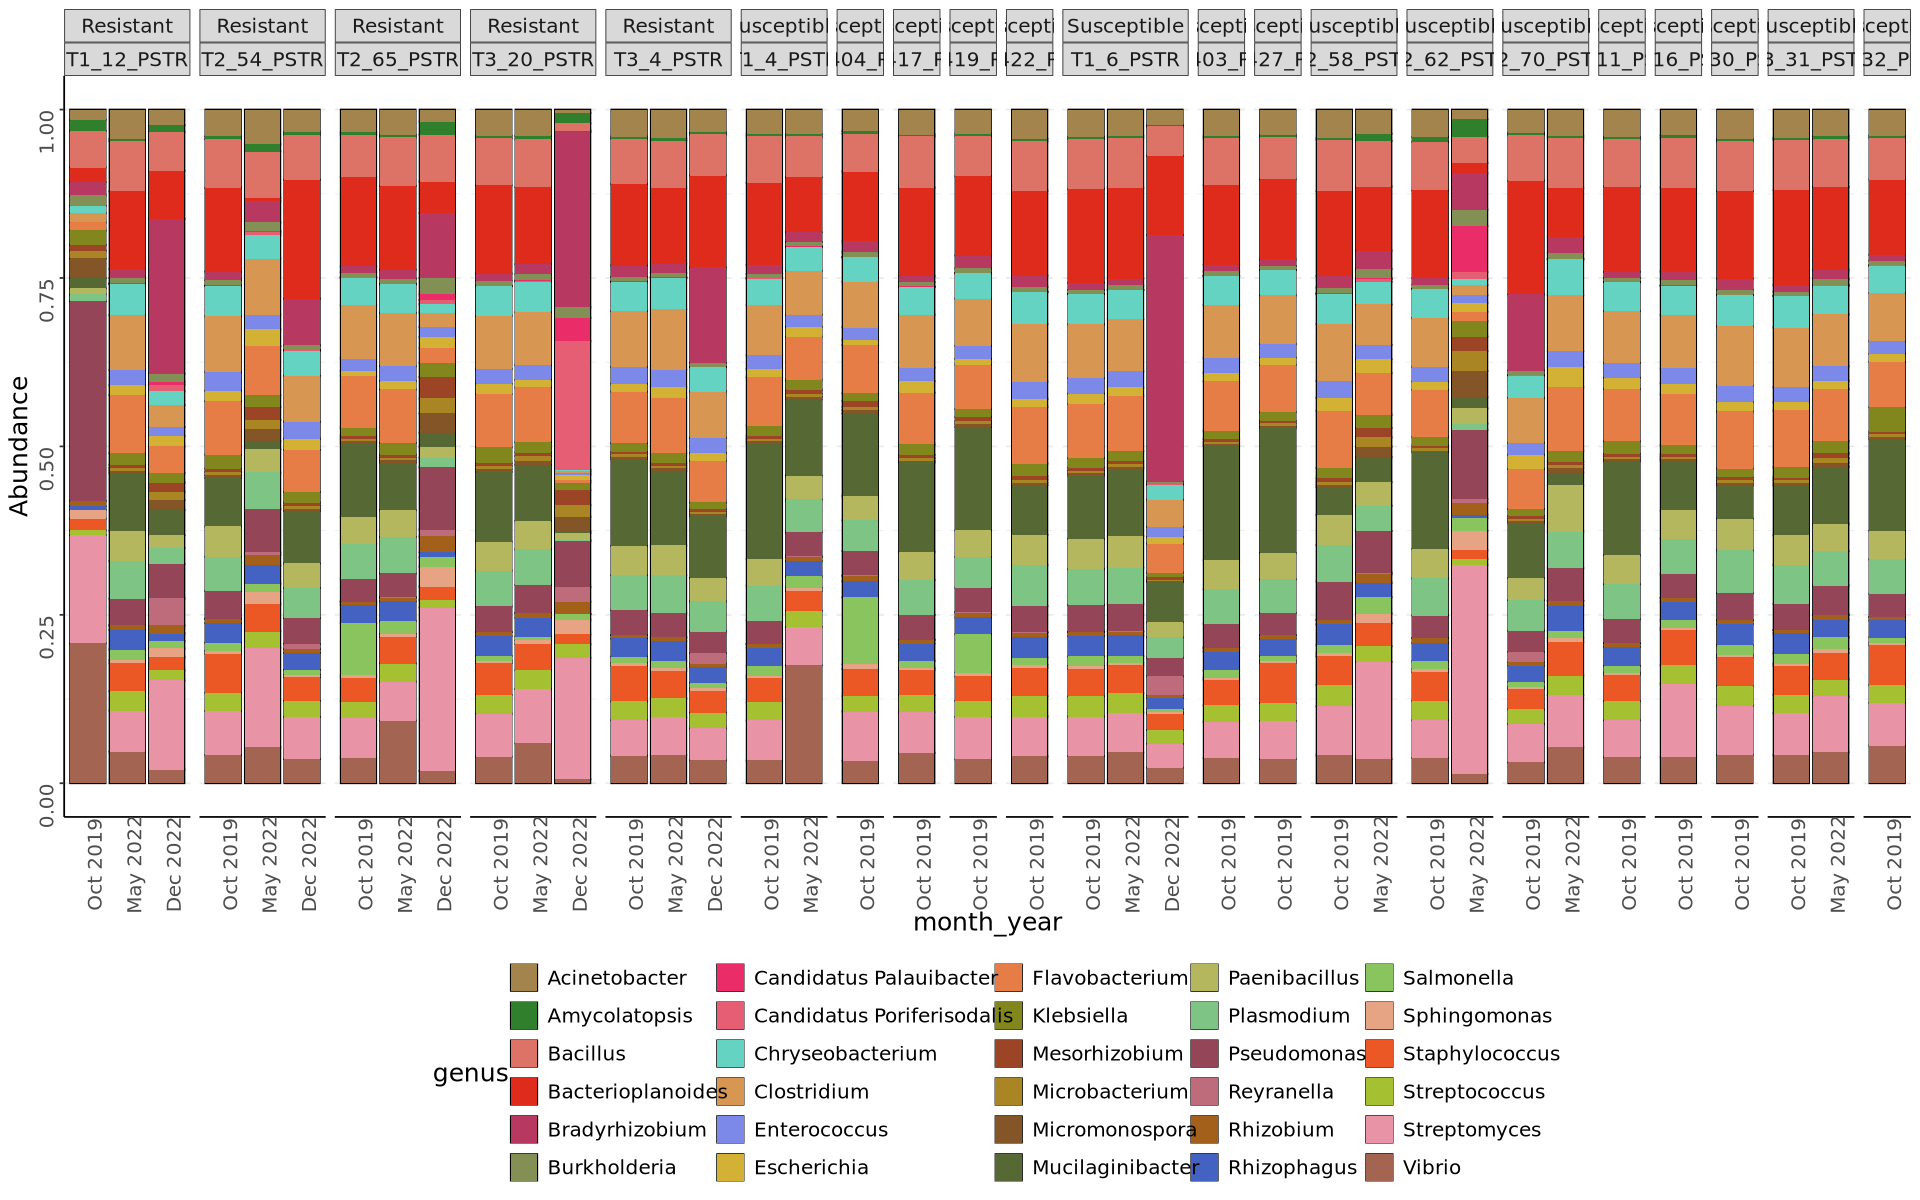

In [254]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_30_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

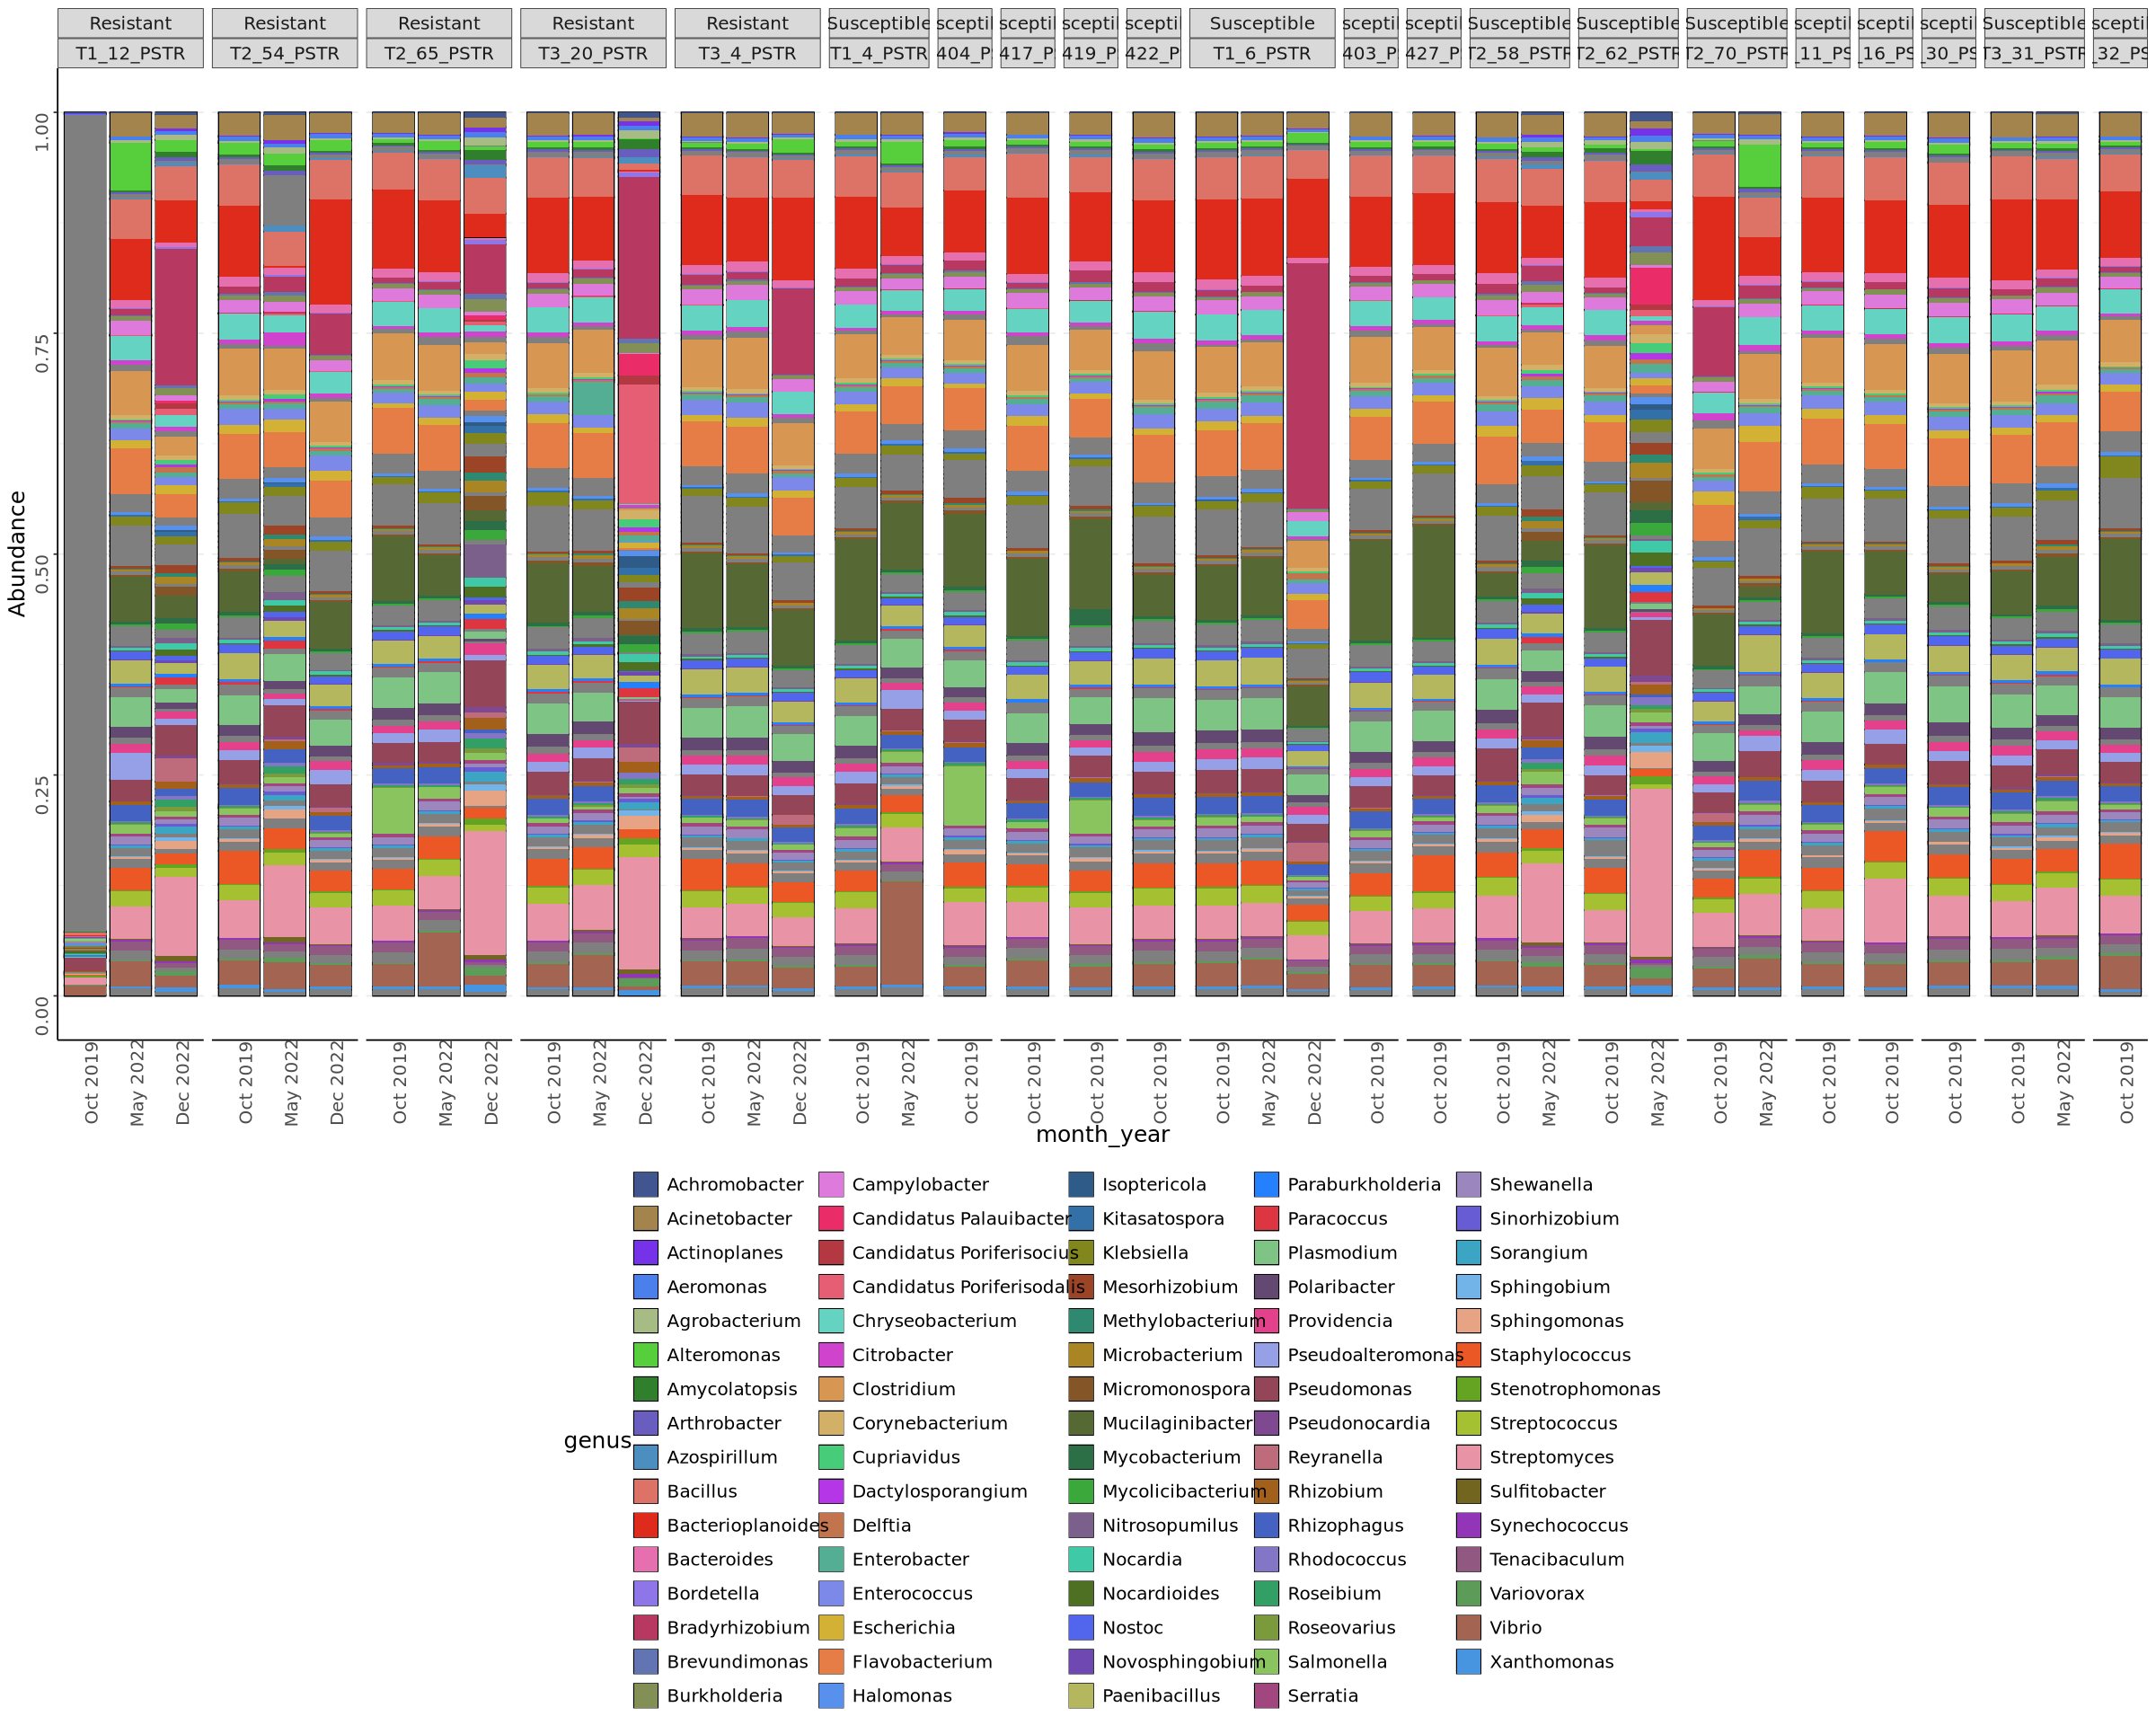

In [258]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (genus)

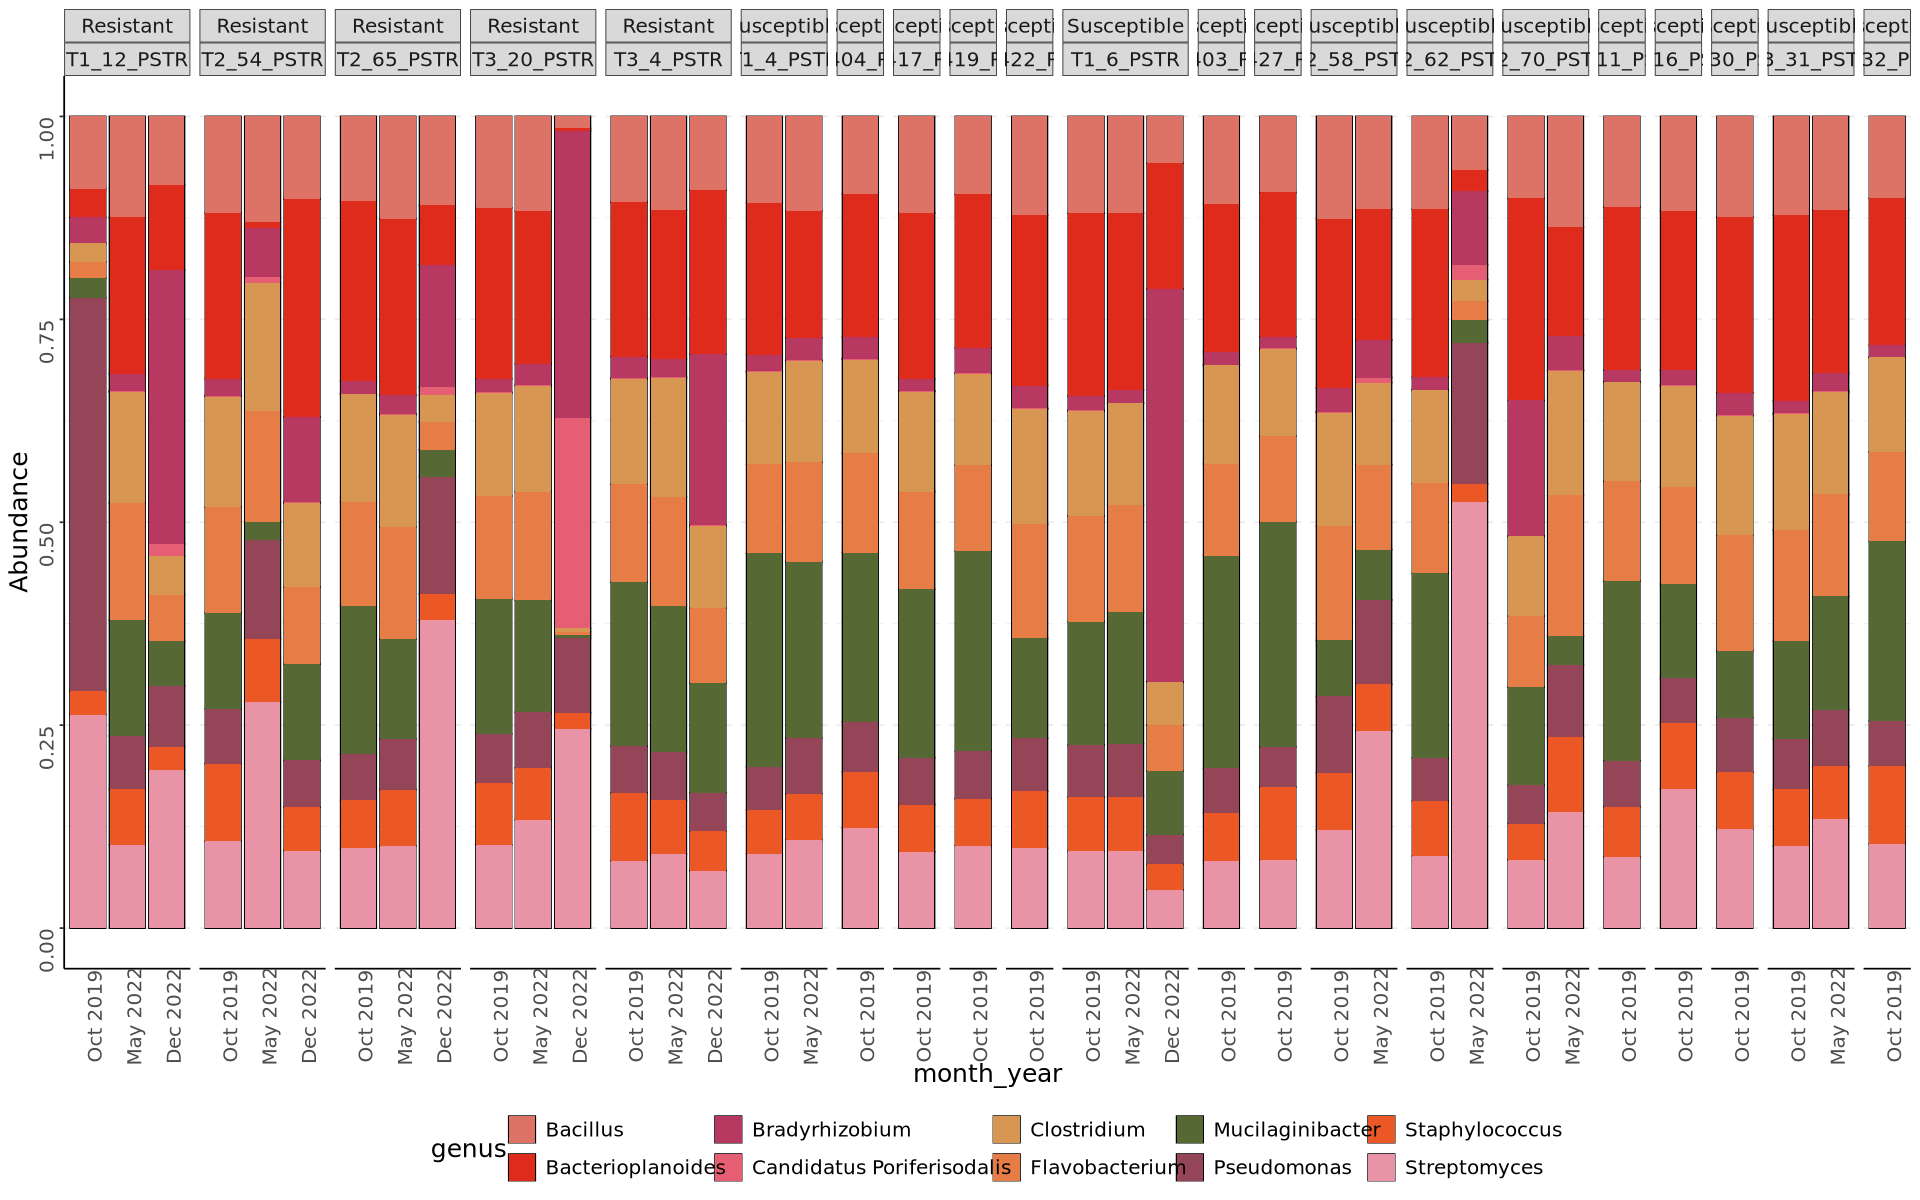

In [260]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_10_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (genus)

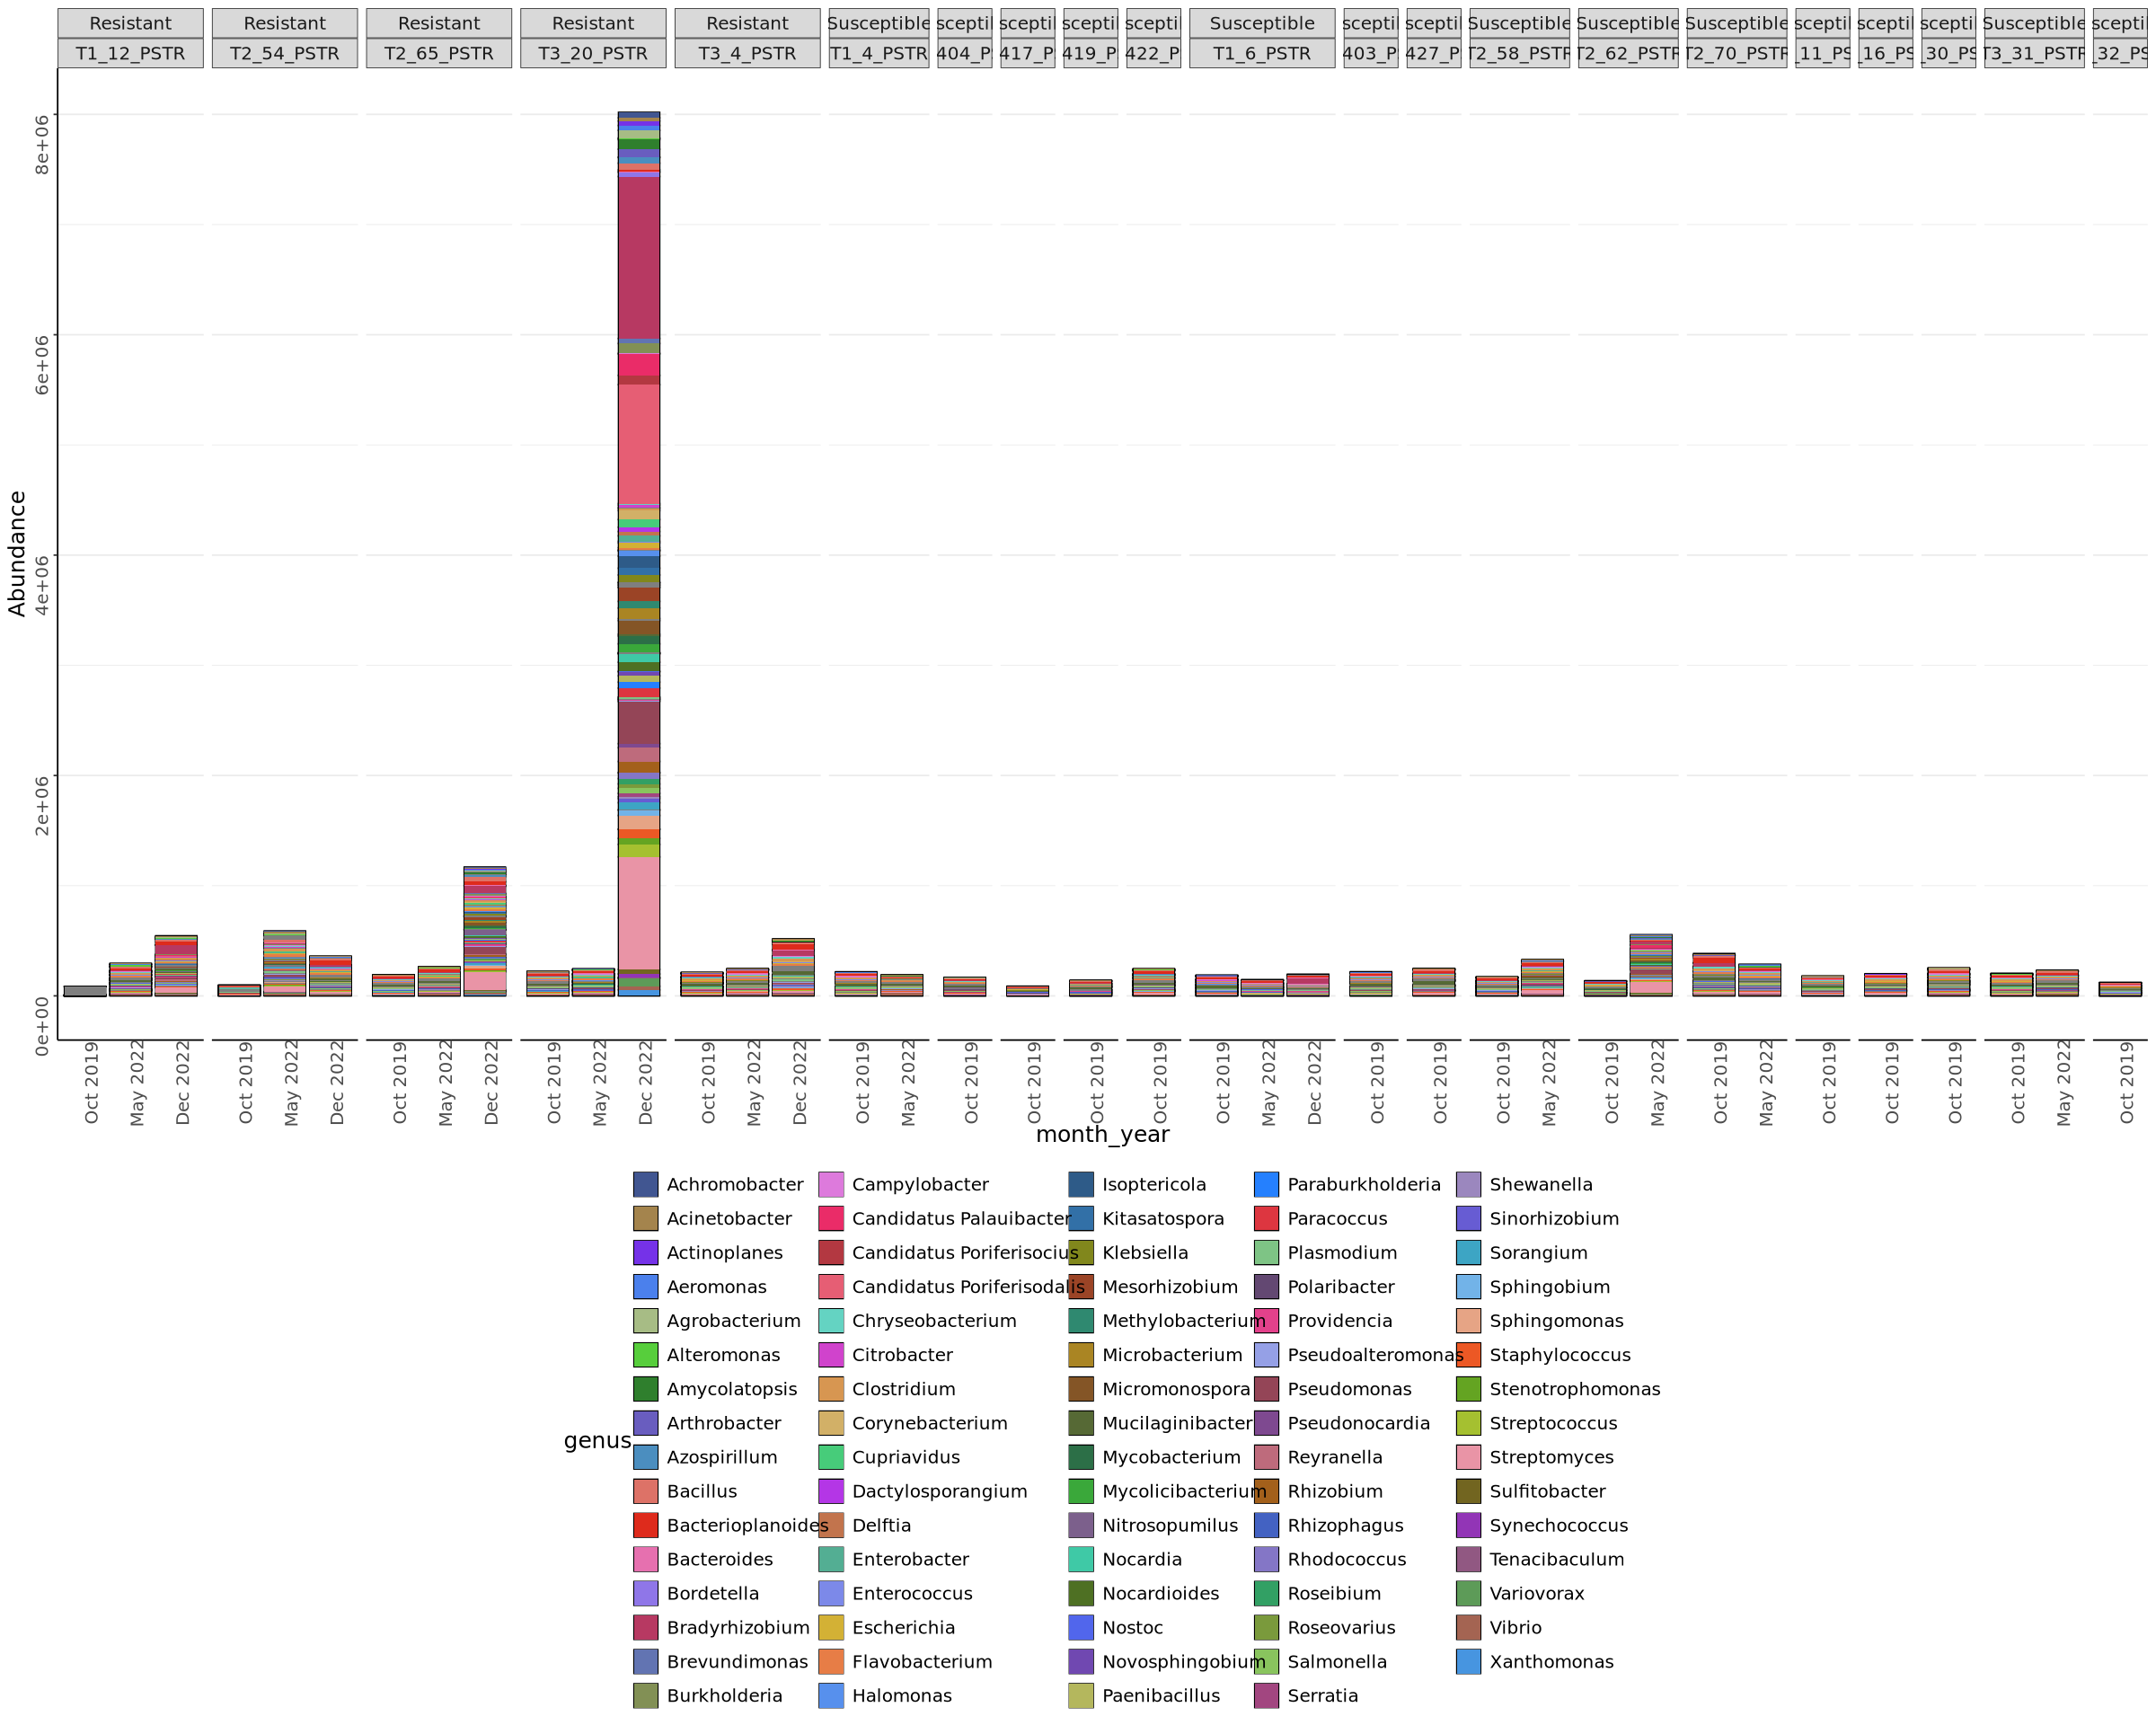

In [263]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (genus)

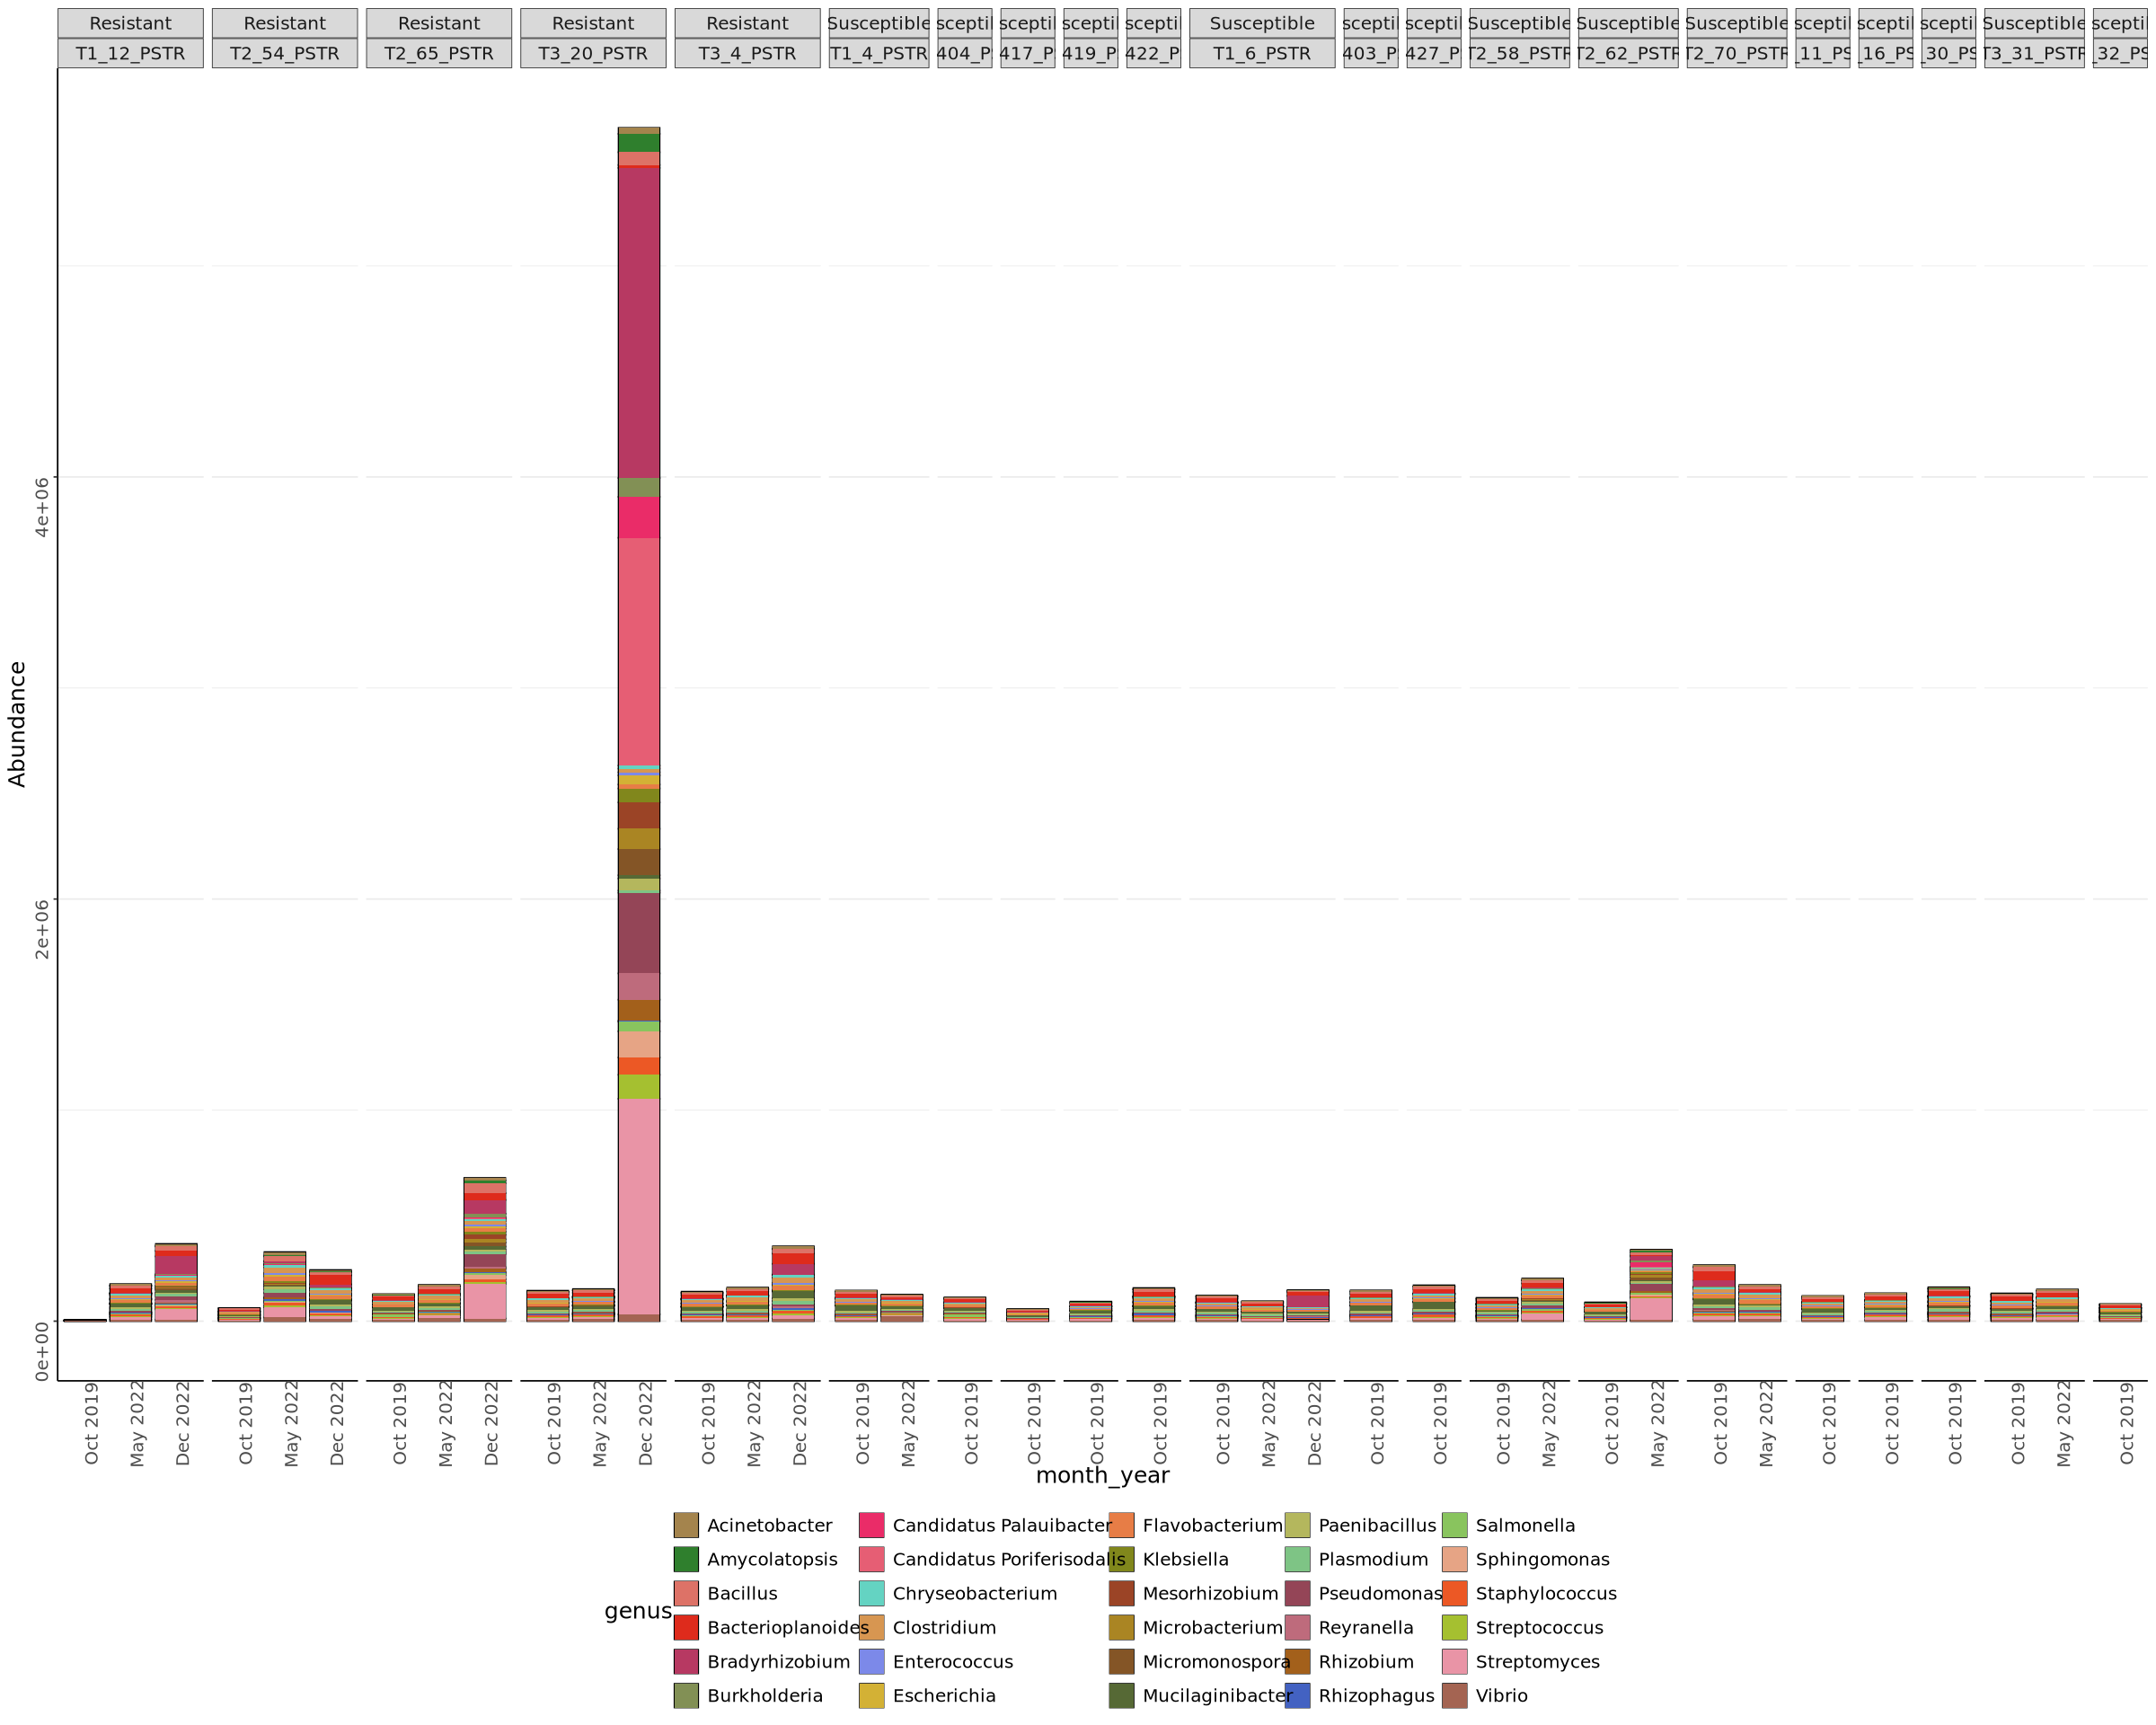

In [264]:

p<-plot_bar(PSTR_30,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (genus)

#### MMEA --------------------------------------------------------------------------------

In [179]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [289]:
# mmea

subset_MMEA<- subset_samples(sctld_raw, (Species == "MMEA"))

# top 100 species
MMEA_100 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:100]), subset_MMEA)
MMEA_100_norm <- transform_sample_counts(MMEA_100, function(x) x / sum(x))

MMEA_30 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:30]), subset_MMEA)
MMEA_30_norm <- transform_sample_counts(MMEA_30, function(x) x / sum(x))

# top 10 genus
MMEA_10 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:10]), subset_MMEA)
MMEA_10_norm <- transform_sample_counts(MMEA_10, function(x) x / sum(x))

In [267]:
df_meta <- data.frame(sample_data(subset_MMEA))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_MMEA) <- sample_data(df_meta)

In [271]:
# reorder colonies
MMEA_g_S<-subset_samples(subset_MMEA, RS == "Susceptible")
df_meta<-data.frame(sample_data(MMEA_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(subset_MMEA)$colony_id <-
  factor(sample_data(subset_MMEA)$colony_id, levels = col_order)

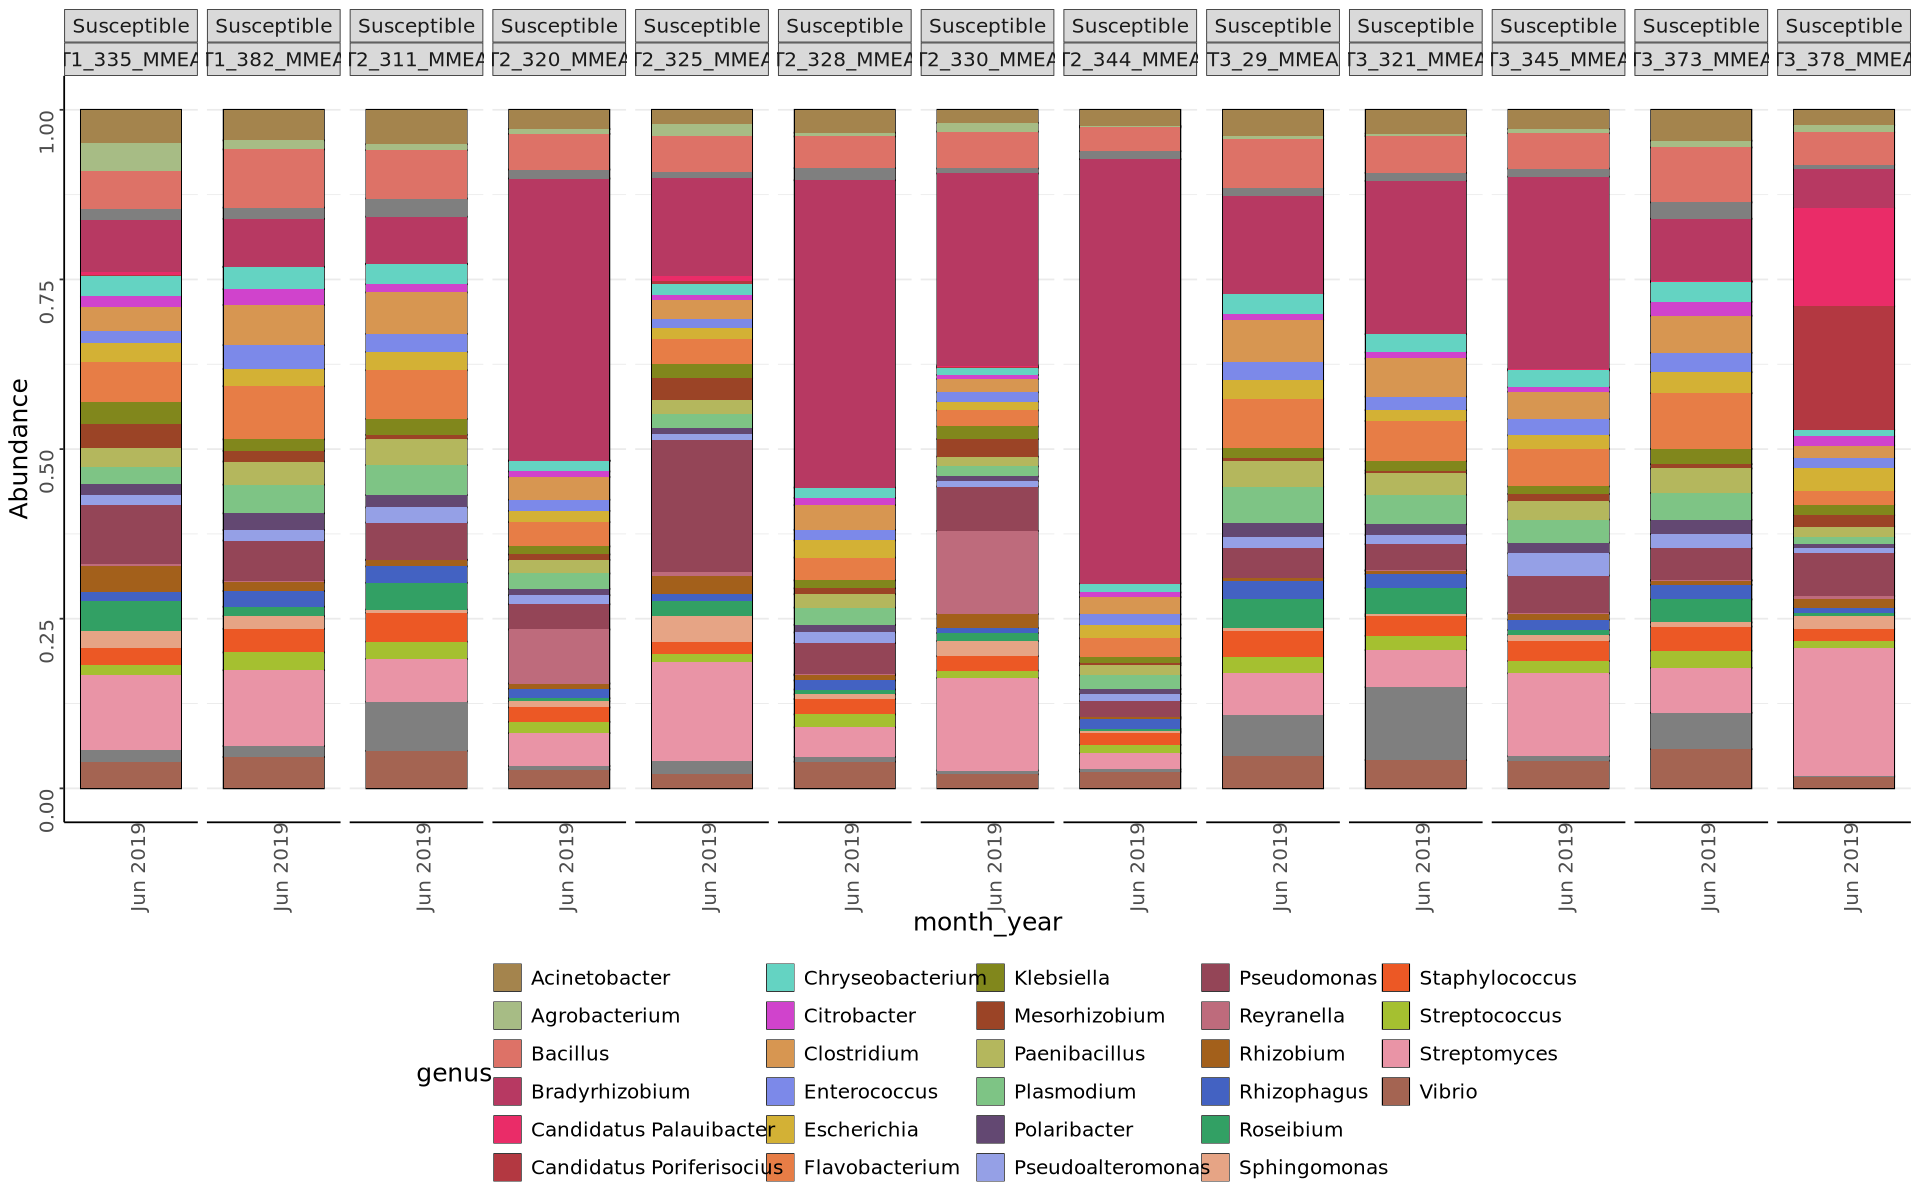

In [275]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_30_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

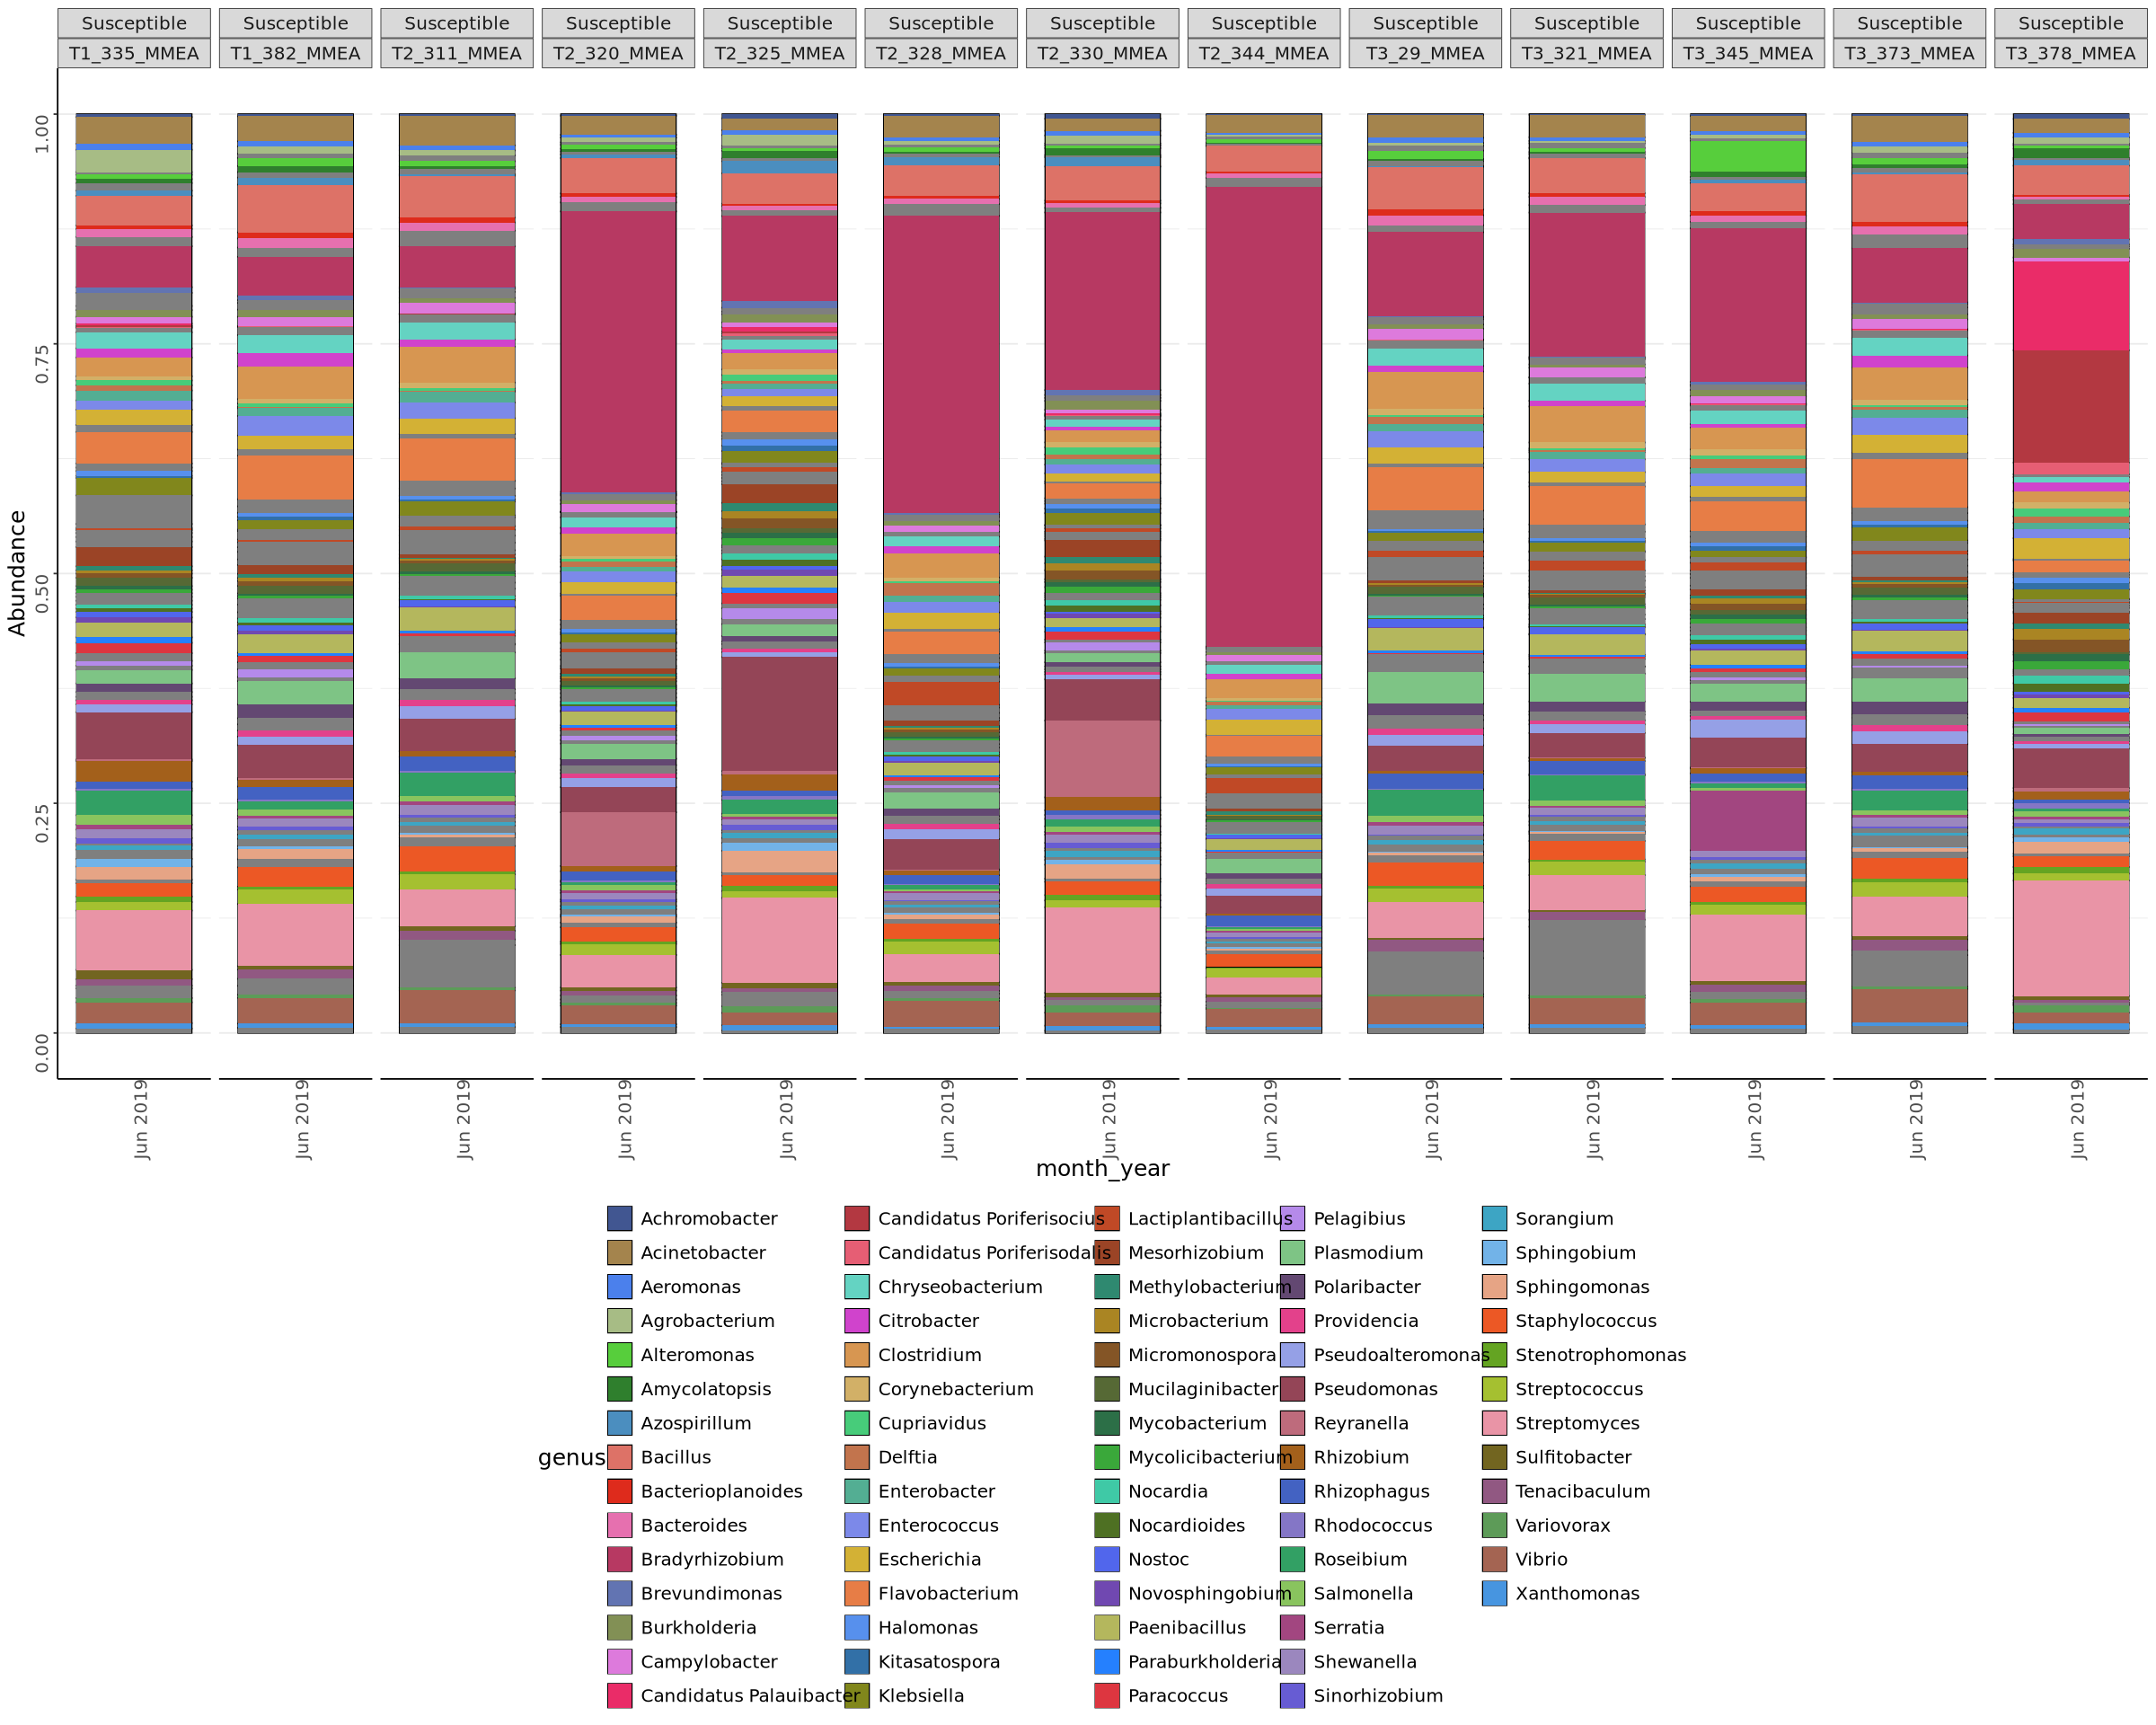

In [277]:
options(repr.plot.height = 16, repr.plot.width = 20)

p<-plot_bar(MMEA_100_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (genus)

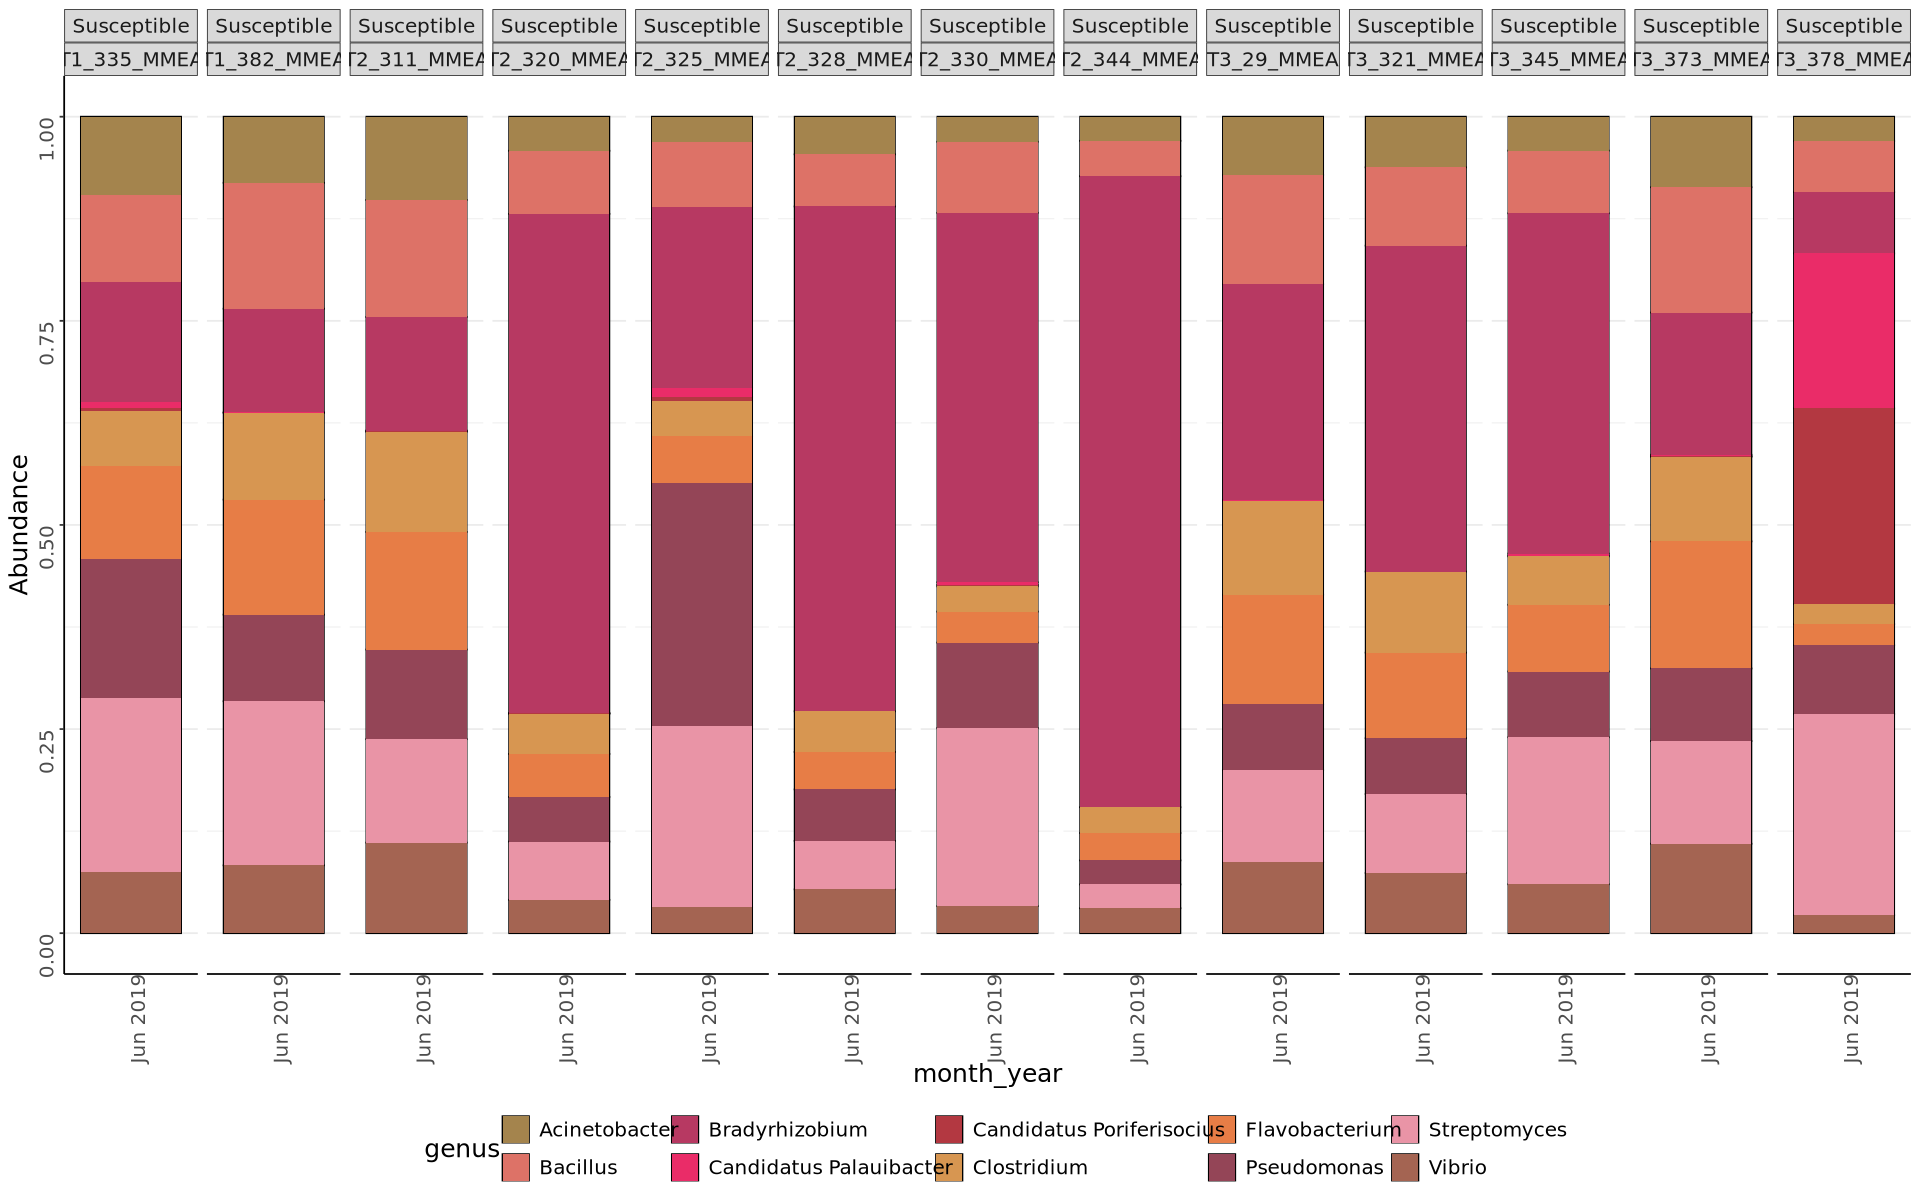

In [278]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_10_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (genus)

#### PAST --------------------------------------------------------------------------------

In [279]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [290]:
# looking just at PAST, remove disease margin

subset_PAST<- subset_samples(sctld_raw, (Species == "PAST" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PAST<- subset_samples(subset_PAST, (!(Date_InitialTag %in% dec_tags)))

# top 100 species
PAST_100 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:100]), subset_PAST)
PAST_100_norm <- transform_sample_counts(PAST_100, function(x) x / sum(x))

PAST_30 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:30]), subset_PAST)
PAST_30_norm <- transform_sample_counts(PAST_30, function(x) x / sum(x))

PAST_10 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:10]), subset_PAST)
PAST_10_norm <- transform_sample_counts(PAST_10, function(x) x / sum(x))

In [291]:
df_meta <- data.frame(sample_data(subset_PAST))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PAST) <- sample_data(df_meta)

In [292]:
# "resistant" colonies that don't have 2022 data 
colony %>%
    filter(colony_id == "T2_47_PAST" | colony_id == "T3_13_PAST") %>%
    select(colony_id, X122022_Condition, X092023_Condition, X012024_Condition, X042024_Condition)
# t3 13 was found again and sampled as healthy in 4/2024, looks like just missed the sample but we have healthy documented in 122022
# remove t2 47 - next sample in 6/2025 and I'm not convinced its the same colony 
# SUS T2 347 was Dead in 05/2022

colony_id,X122022_Condition,X092023_Condition,X012024_Condition,X042024_Condition
<chr>,<chr>,<chr>,<chr>,<chr>
T2_47_PAST,Not_Visited,Not_Visited,Not_Visited,Not_Visited
T3_13_PAST,Healthy,Not_Visited,CLB,Healthy


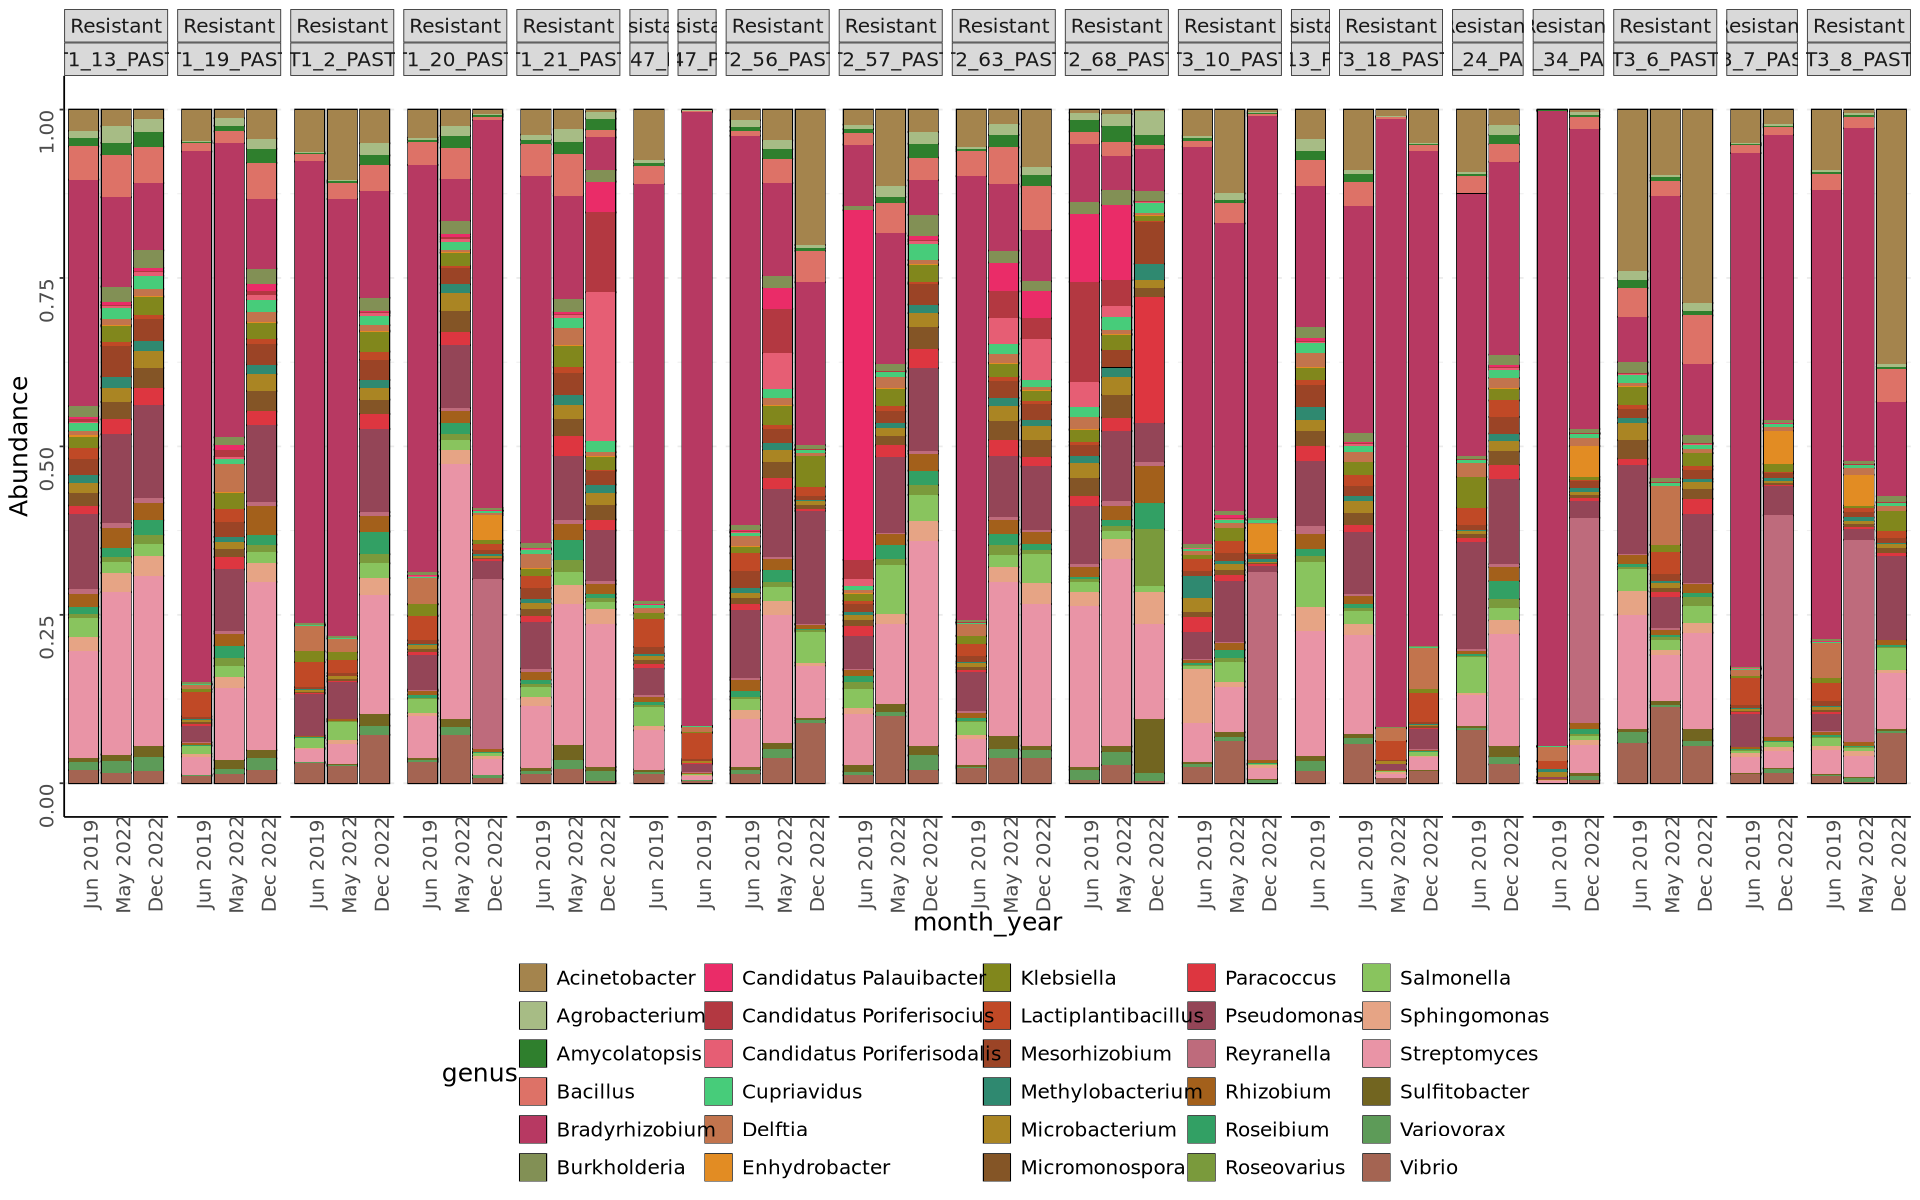

In [293]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_30_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

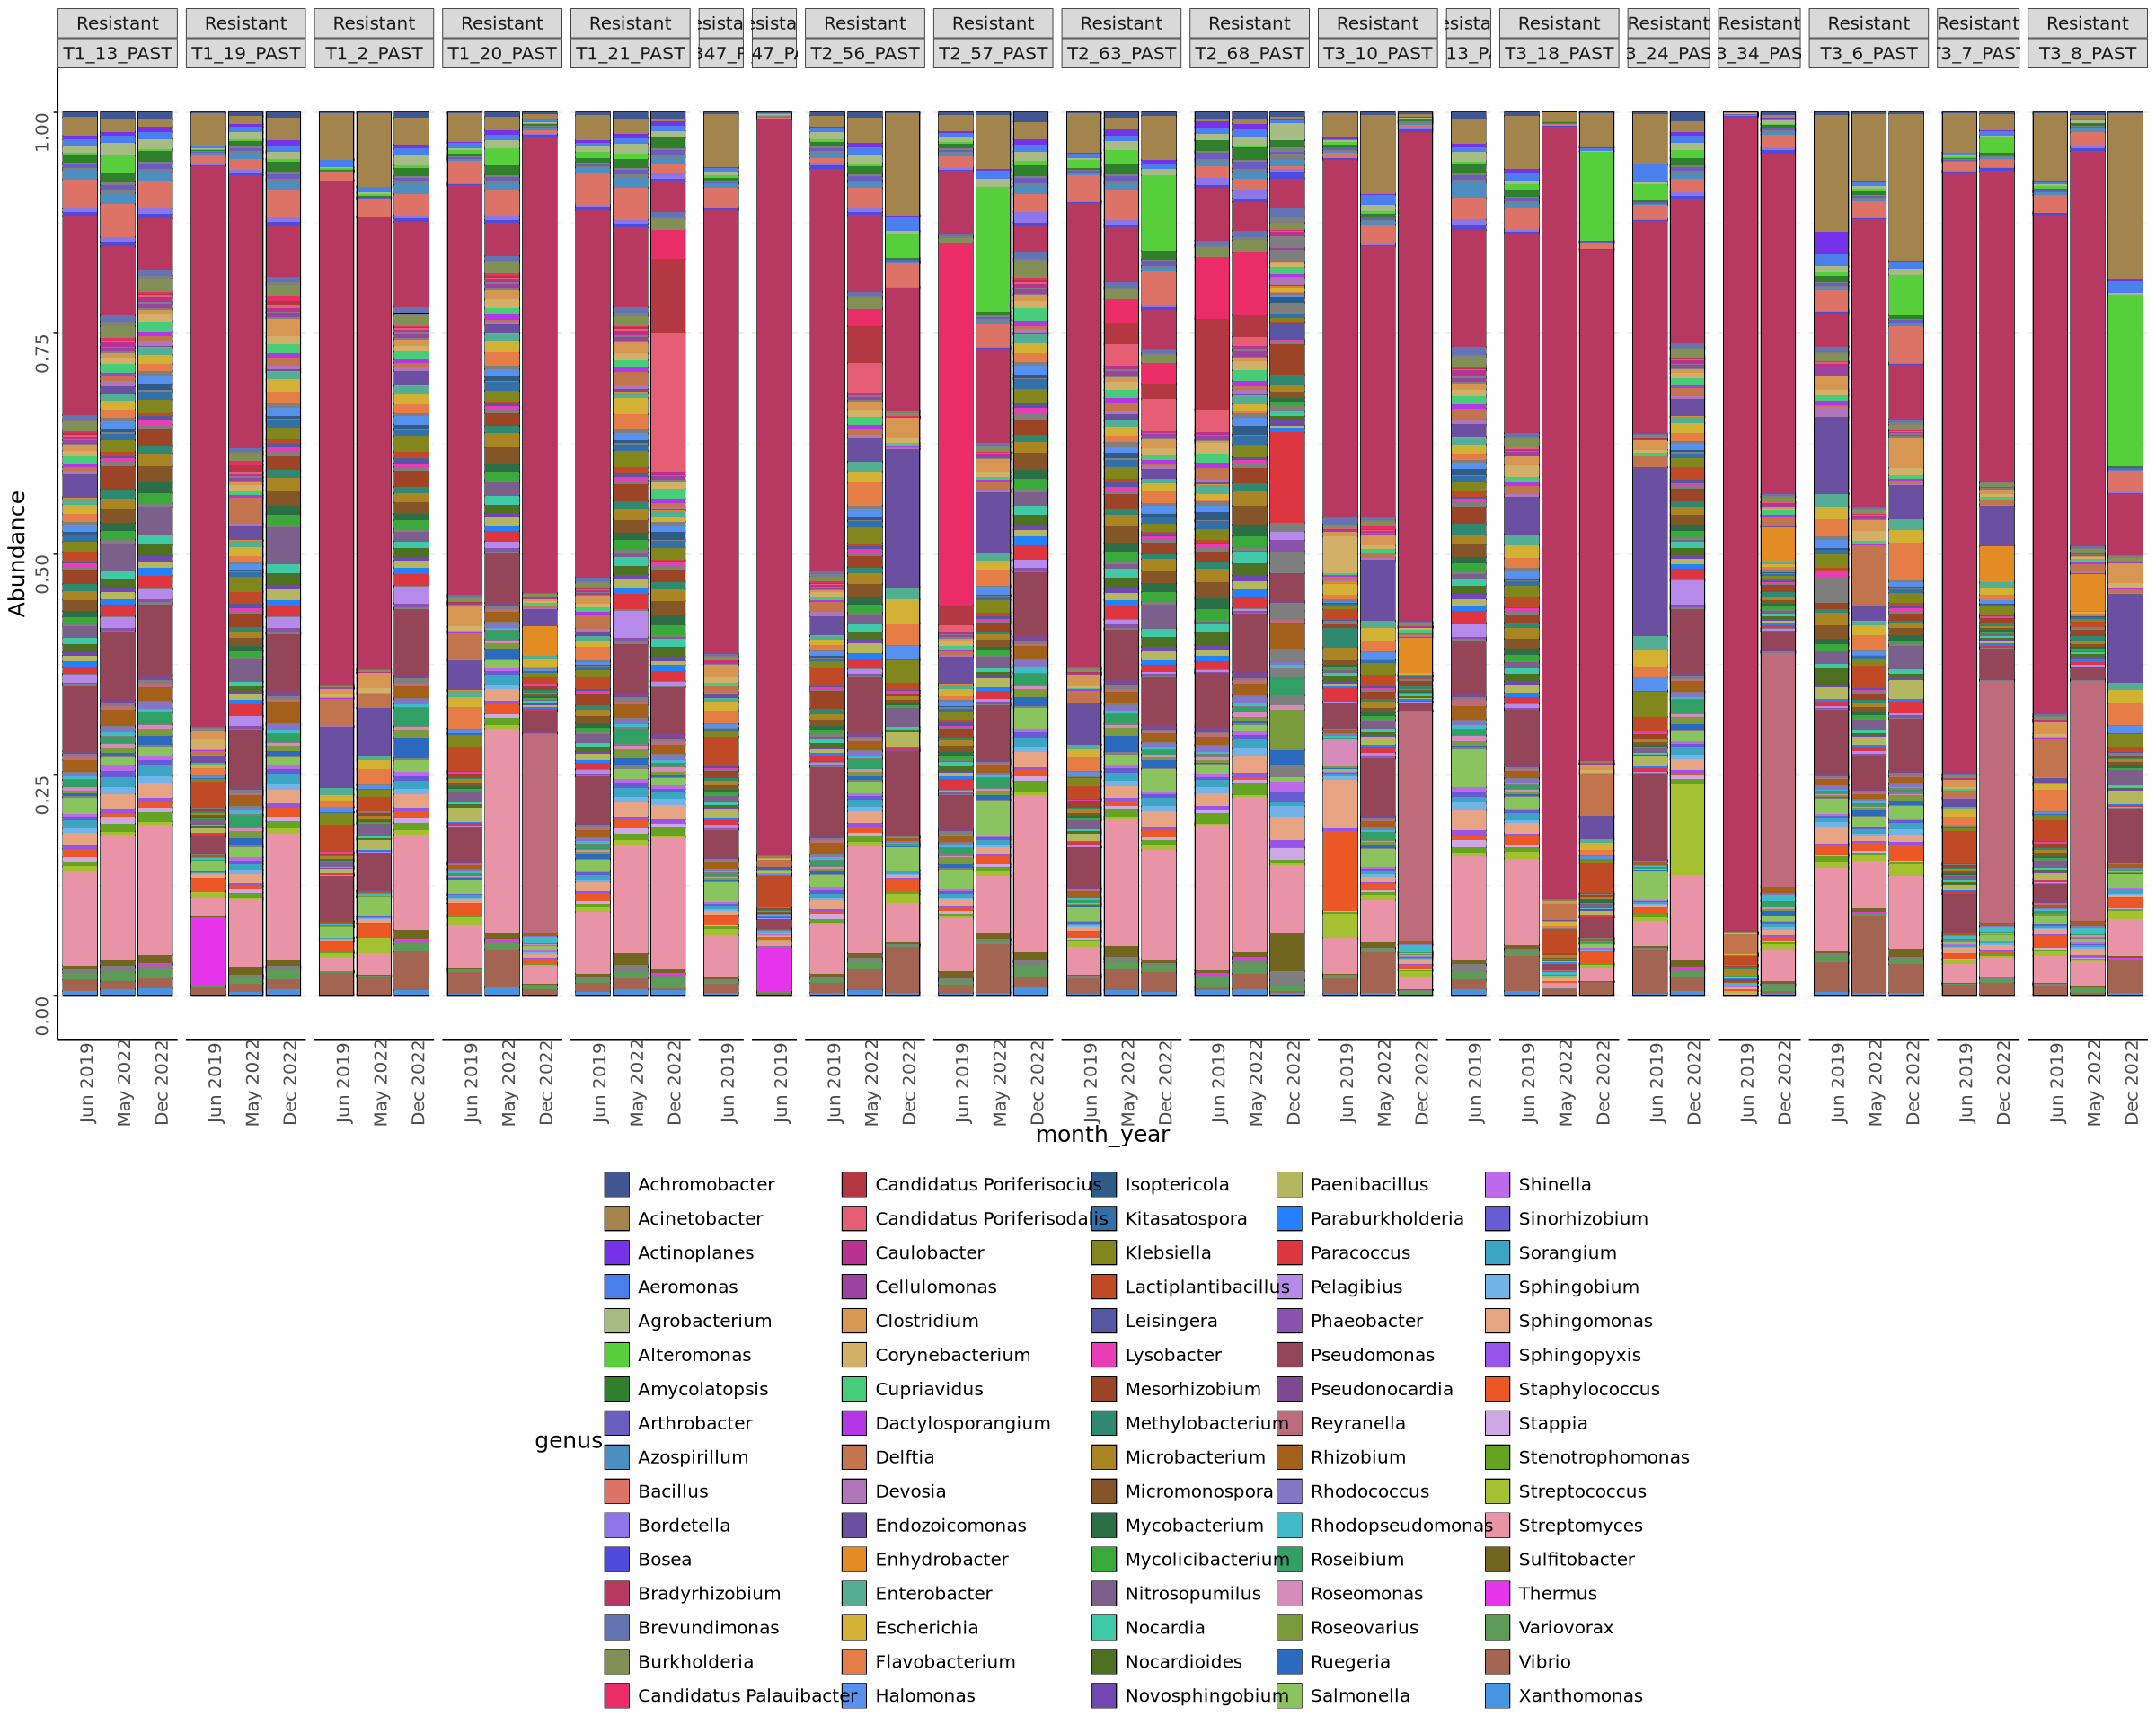

In [295]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (genus)

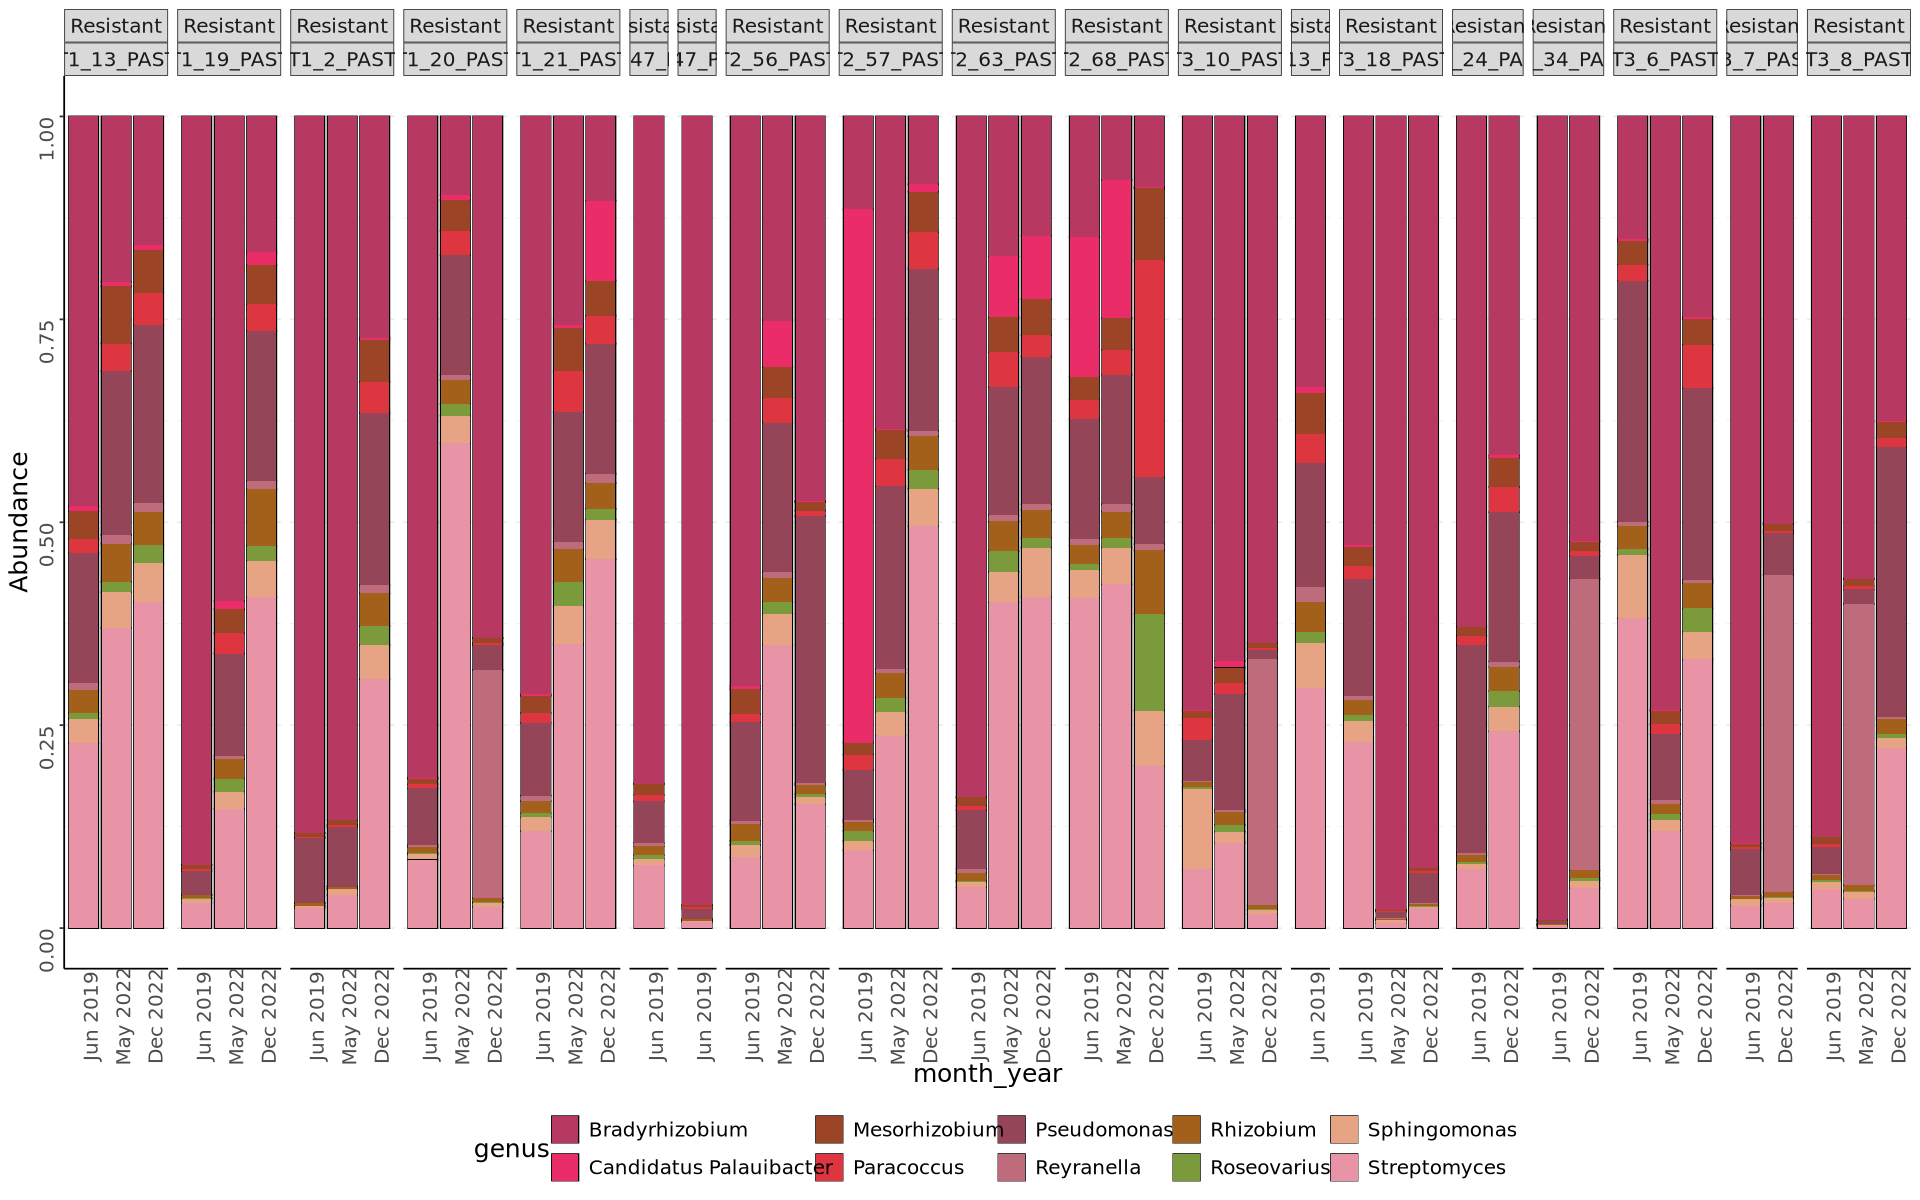

In [296]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_10_norm,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (species)

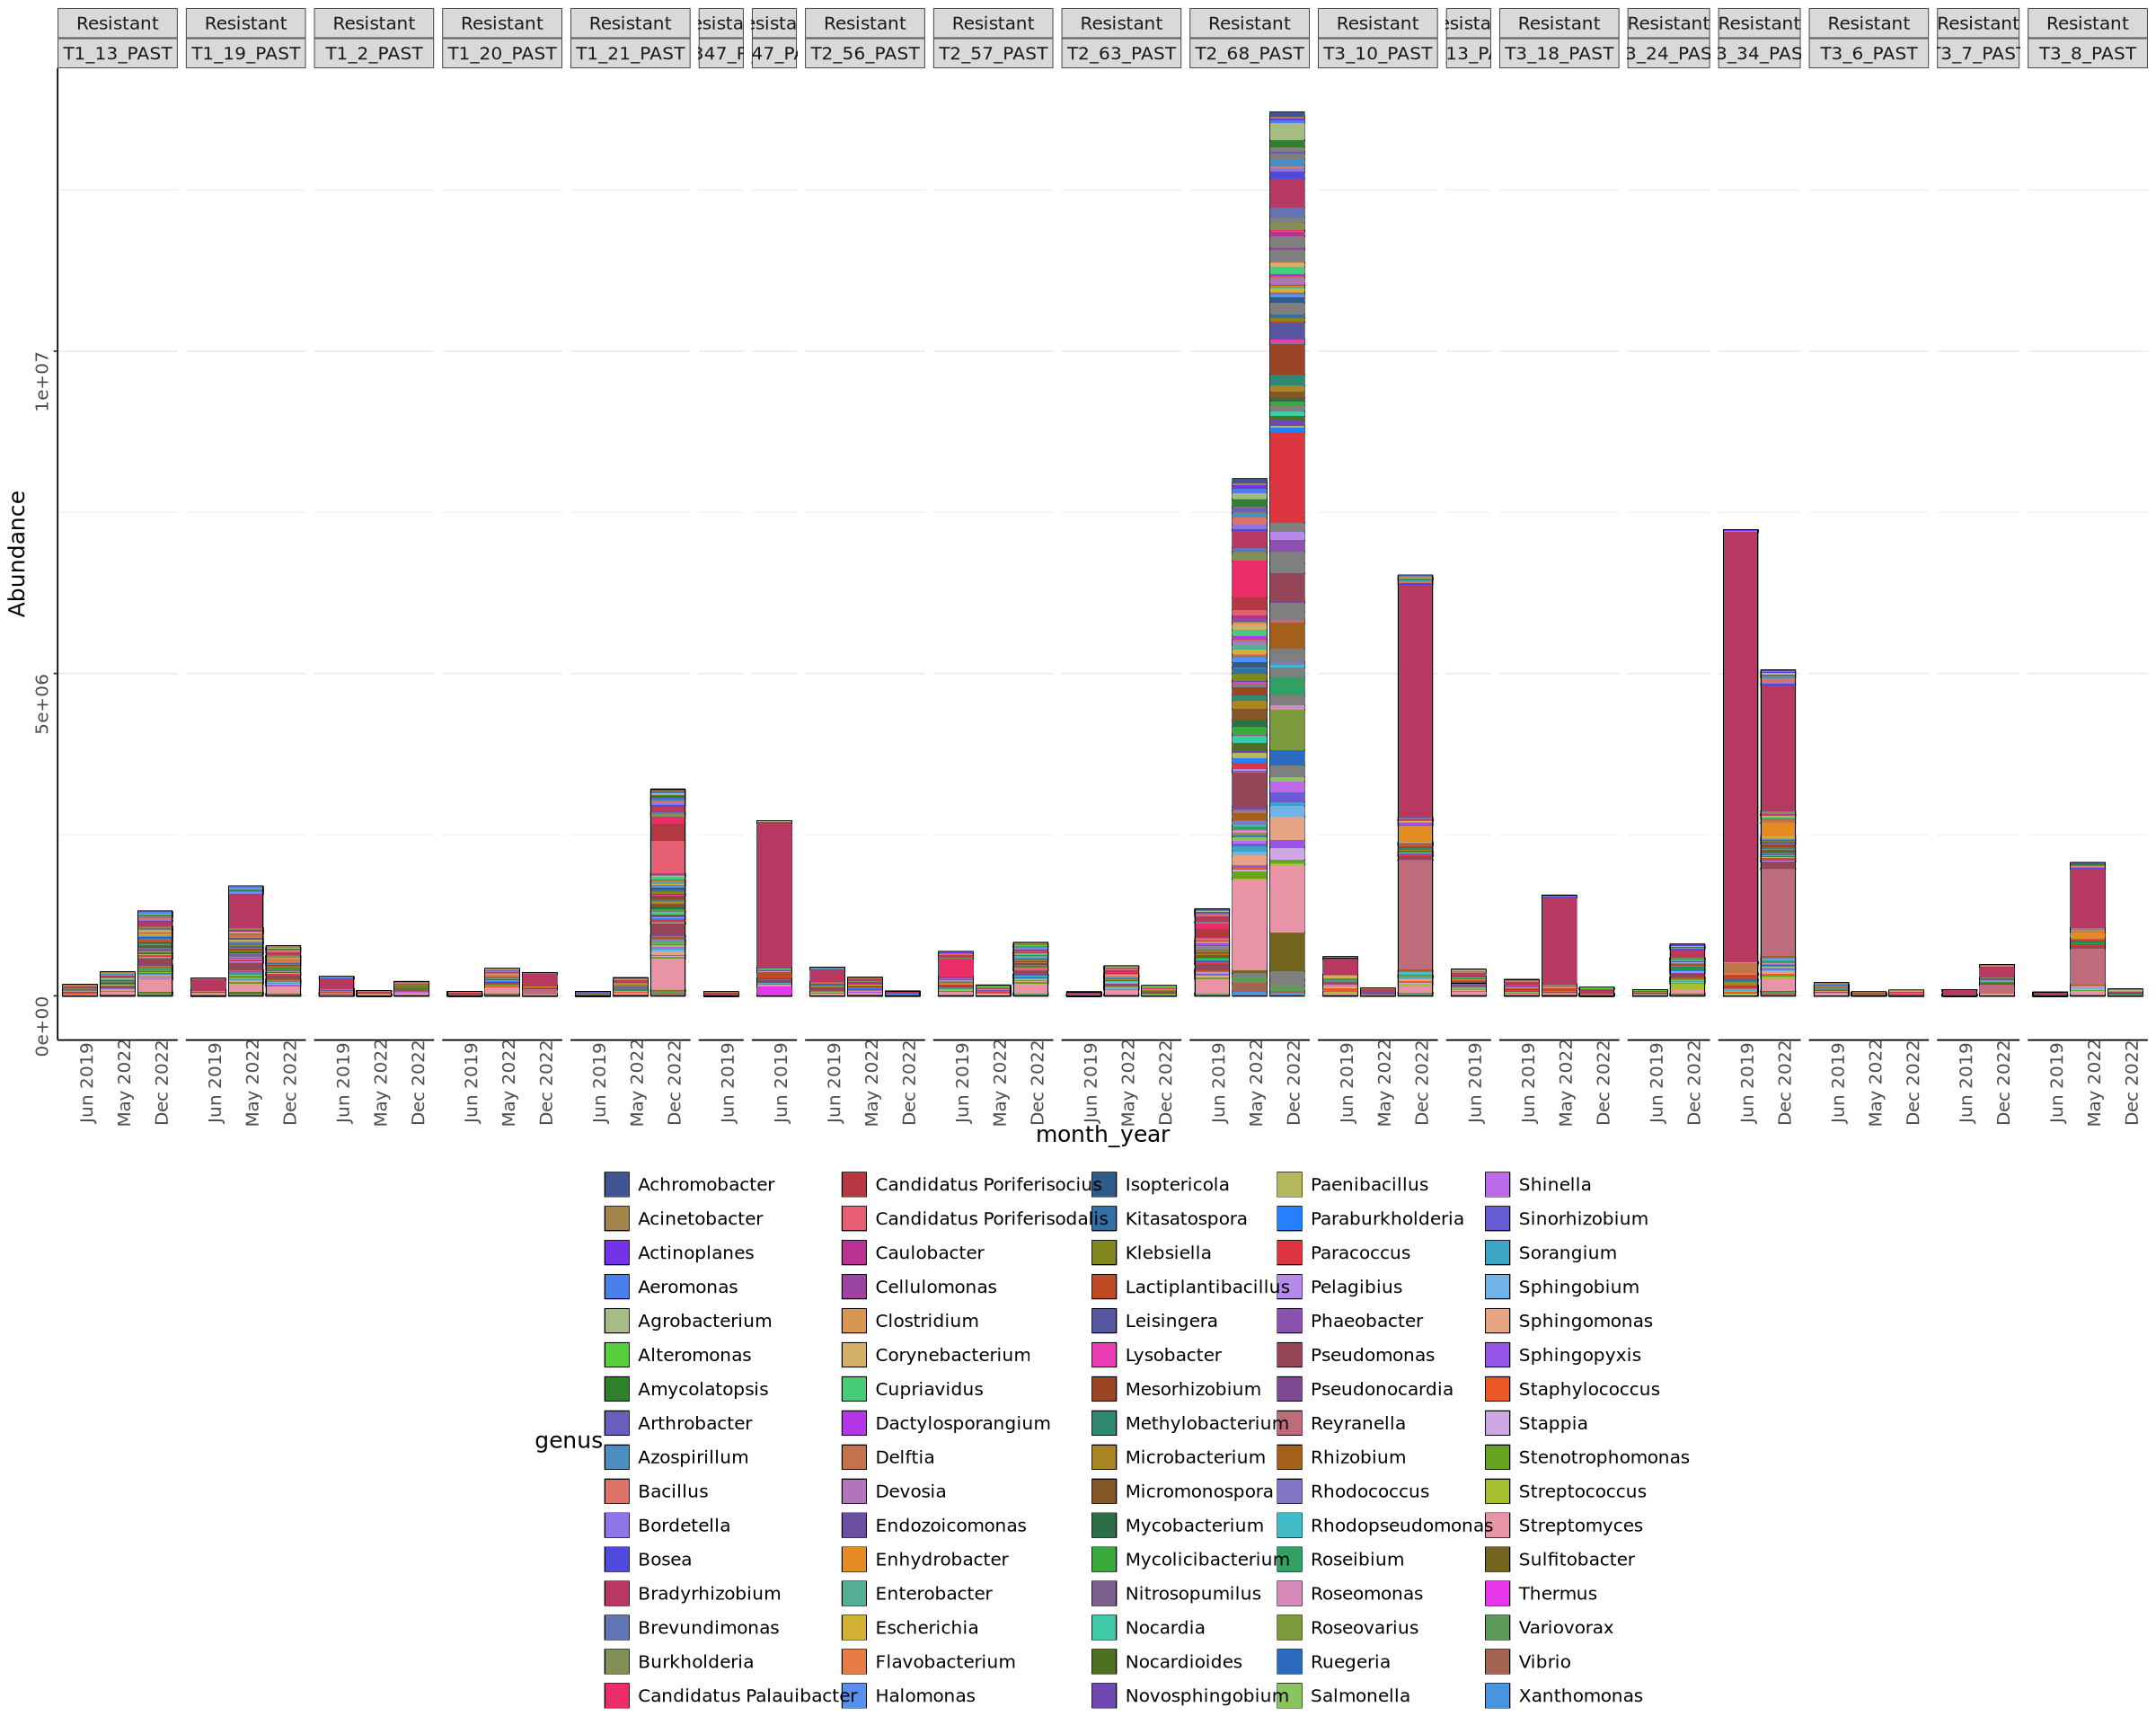

In [299]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (genus)

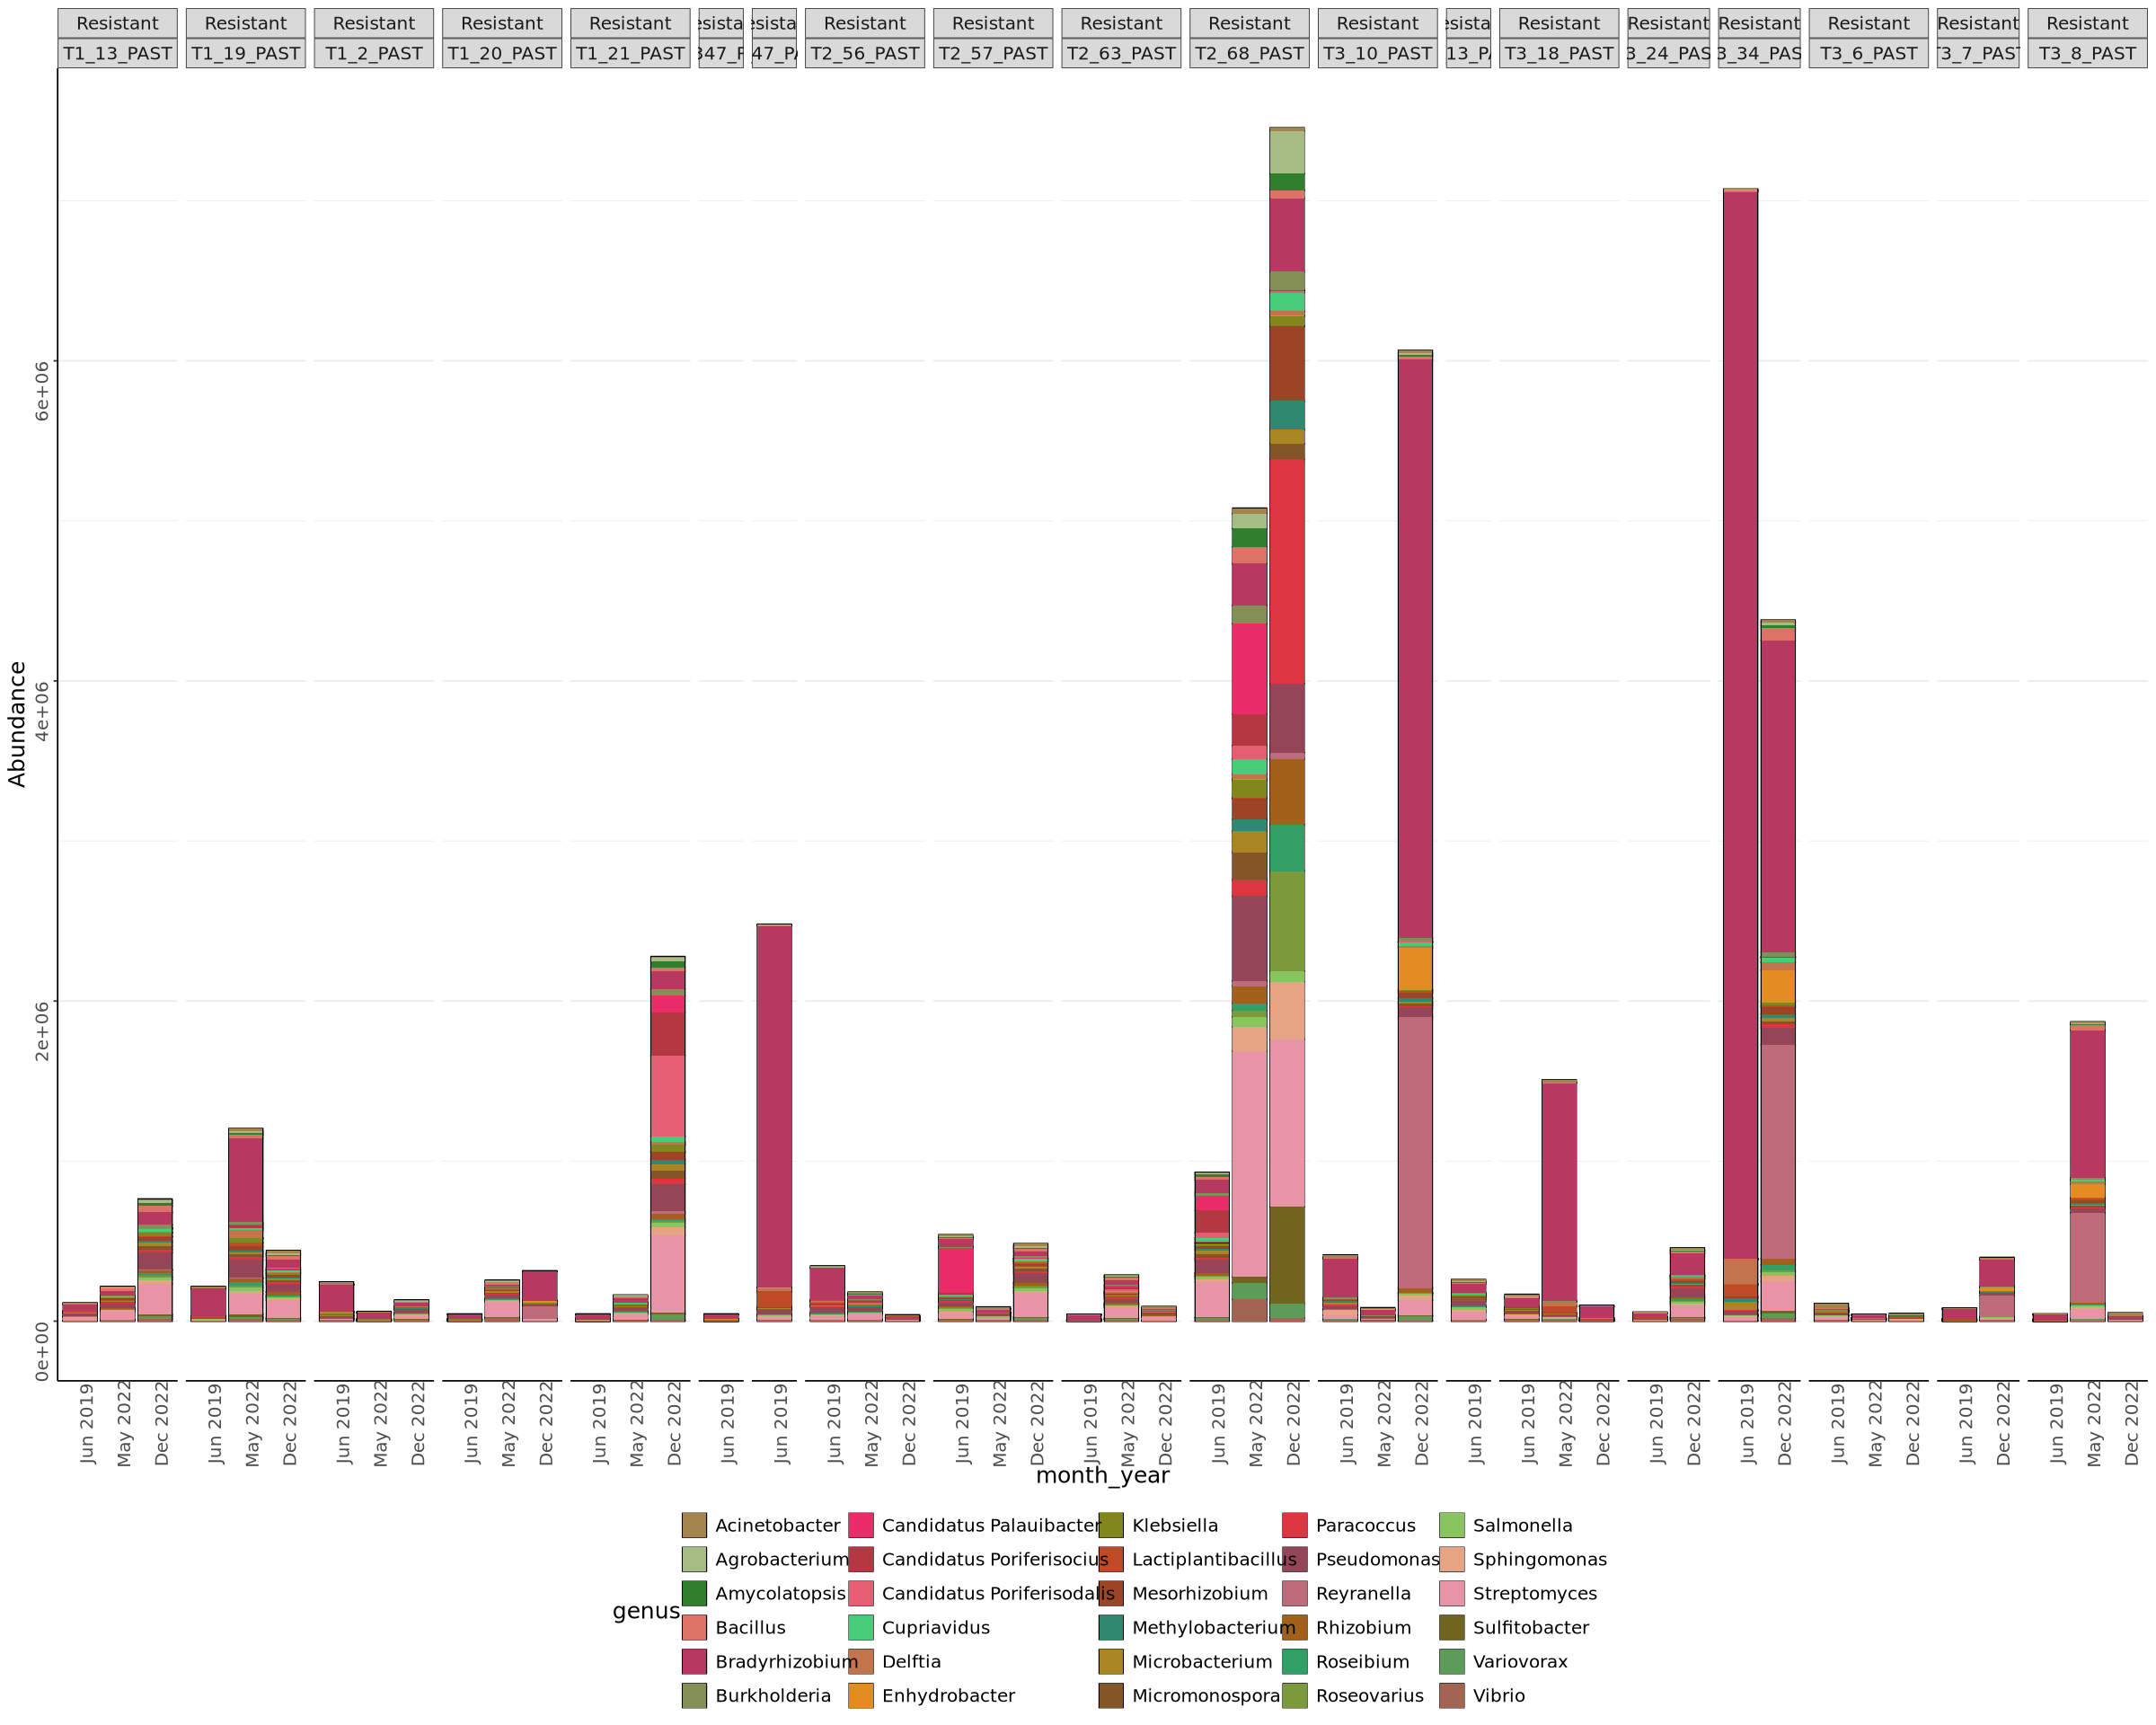

In [300]:
p<-plot_bar(PAST_30,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (genus)